# Math Genealogy: An EDA of 263,000 Mathematicians

The [Mathematics Genealogy Project](https://www.mathgenealogy.org/) records the advisor → student relationships of mathematicians worldwide — back to the 13th century. This notebook explores the resulting graph (from `graph.pkl`) as a blog-post-shaped tour, organised around questions rather than methods.

## Questions

1. **What's actually in this dataset?** — coverage caveats
2. **How big is the network?** — basic stats + components
3. **How fast has mathematics grown?** — per year, per capita, doubling time
4. **Who are the patriarchs?** — descendants, reversed PageRank, longest chain
5. **How long is a mathematical generation?** — advisor → student year gap
6. **How fertile is the average advisor?** — out-degree, conditional fertility
7. **Has co-advising become more common?** — in-degree over time
8. **Where does math happen?** — universities, countries, firsts, migration
9. **What gets studied — and inherited?** — subjects, trends, birth dates
10. **A network-science deep dive** — power-law, assortativity, clustering
11. **Gender** — name-inferred shares over time and across countries
12. **Thesis-title evolution** — TF-IDF over 235k titles
13. **Historical ruptures** — wars, the 1933 purge, the Soviet collapse
14. **Network deeper** — articulation points, preferential attachment, time slices, lineage survival
15. **Sociology** — school endogamy, dynasties, sibling subject correlation
16. **Speculative fun** — recent patriarchs, the Hilbert number
17. **Prize laureates** — Fields and Abel winners' positions in the genealogy
18. **Predictive models** — what predicts advisor fertility and lineage survival
19. **Mesoscale** — Louvain communities, k-core, biconnected blocks
20. **Career trajectories** — first/last student age, burstiness
21. **Subject meta-network** — subject-level graph, inheritance asymmetry, drift
22. **Geographic deeper** — city-level rankings, female firsts, continent flows
23. **Case studies** — Princeton vs Göttingen, Bourbaki, the Russian diaspora
24. **Data quality / outliers** — implausible records, hub sanity
25. **Mathematical Eve** — most-recent common ancestor of modern PhDs
26. **WWII as a natural experiment** — German mathematicians who stayed vs. emigrated
27. **Notable PhD-less mathematicians** — what does MGP miss?
28. **Co-advisor recurrence** — invisible "labs" behind the genealogy
29. **Branching process fit** — is the genealogy just a random Galton-Watson process?
30. **School meta-network** — schools as nodes, PageRank and communities
31. **What wasn't done in this pass**
32. **Caveats**

## 0. Setup

In [1]:
import logging
import pickle
import re
from collections import Counter
from pathlib import Path

import country_converter as coco
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import powerlaw
import seaborn as sns

logging.getLogger("country_converter").setLevel(logging.ERROR)
# notebook_connected loads Plotly.js from CDN; avoids inlining ~4 MB per session.
pio.renderers.default = "notebook_connected"

sns.set_theme(style="ticks", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.options.display.max_columns = None
pd.options.display.width = 140
RNG = np.random.default_rng(0)

# Resolve graph.pkl whether CWD is analysis/ or the project root.
for _candidate in ("graph.pkl", "analysis/graph.pkl", "../analysis/graph.pkl"):
    if Path(_candidate).exists():
        GRAPH_PATH = Path(_candidate)
        break
else:
    raise FileNotFoundError("graph.pkl not found; run `python analysis/build_graph.py` first")

with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

# Tabular view of node metadata for easier slicing.
df = pd.DataFrame(
    [{"id": n, **a} for n, a in G.nodes(data=True)]
).set_index("id")

# Convenience accessors used throughout the notebook.
def node_label(nid, with_year=True):
    a = G.nodes[nid]
    name = a.get("name") or f"#{nid}"
    year = a.get("year")
    return f"{name} ({int(year)})" if with_year and year else name

print(f"loaded {GRAPH_PATH}")
print(f"  {G.number_of_nodes():,} nodes  /  {G.number_of_edges():,} edges")
df.head(3)

loaded graph.pkl
  262,967 nodes  /  285,398 edges


,name,thesis,school,country,year,subject
id,,,,,,
11,Alfred E. Engelbrecht,Coupled Bending and Torsional Free Vibration o...,Iowa State University,UnitedStates,1949.0,NaN
4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,NaN
1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids


## 1. What's actually in this dataset?

Before any analysis, look at the dataset's *coverage* — which fields are populated, and how that changes over time. Every plot below this section is conditional on the relevant field being known.

### 1.1 Field-level coverage

In [2]:
n = G.number_of_nodes()
coverage = pd.DataFrame({
    "non-null": [df[c].notna().sum() for c in ["name", "year", "school", "country", "subject", "thesis"]],
}, index=["name", "year", "school", "country", "subject", "thesis"])
coverage["%"] = (coverage["non-null"] / n * 100).round(1)
coverage

,non-null,%
name,262120,99.7
year,214713,81.7
school,220346,83.8
country,247462,94.1
subject,153714,58.5
thesis,234799,89.3


### 1.2 Coverage decays near the present

MGP is volunteer-maintained, so recent PhDs are systematically under-represented (the project lags reality by 5–10 years). Any "math is dying" curve past ~2015 is an artifact, not a signal.

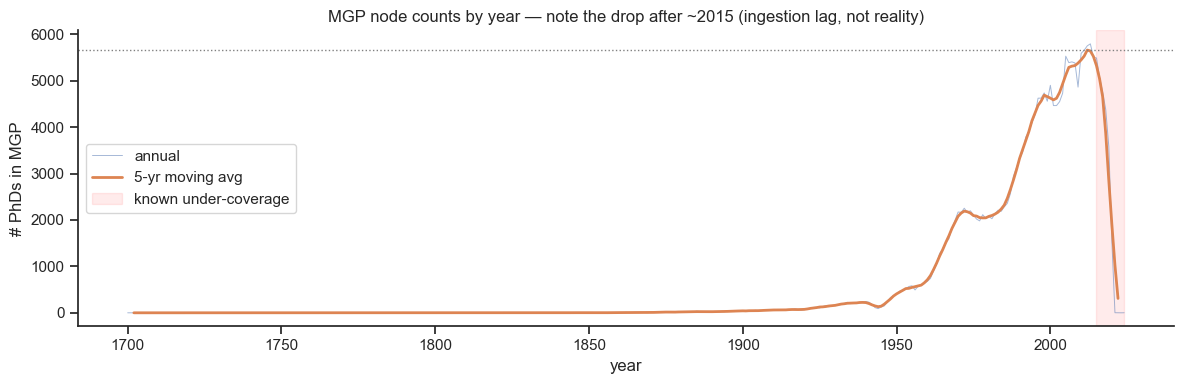

In [3]:
years = df["year"].dropna().astype(int)
years = years[(years >= 1700) & (years <= 2025)]

# Rolling 5-year share of nodes whose year is within the data range.
# Because we already filtered to known years, this can only show *density*,
# not coverage. Instead: count PhDs per year, then show as a fraction of the
# decade peak (a proxy for "has this year been fully ingested yet?").
per_year = years.value_counts().sort_index().reindex(range(1700, int(years.max()) + 1), fill_value=0)
rolling = per_year.rolling(5, center=True).mean()
peak_recent = rolling.loc[1990:2015].max()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(per_year.index, per_year.values, linewidth=0.7, alpha=0.5, label="annual")
ax.plot(rolling.index, rolling.values, linewidth=2, label="5-yr moving avg")
ax.axhline(peak_recent, color="grey", linestyle=":", linewidth=1)
ax.axvspan(2015, per_year.index.max(), color="red", alpha=0.08, label="known under-coverage")
ax.set_xlabel("year")
ax.set_ylabel("# PhDs in MGP")
ax.set_title("MGP node counts by year — note the drop after ~2015 (ingestion lag, not reality)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. How big is the network?

In [4]:
n, m = G.number_of_nodes(), G.number_of_edges()
print(f"# nodes:     {n:>12,}")
print(f"# edges:     {m:>12,}")
print(f"directed?    {G.is_directed()}")
print(f"DAG?         {nx.is_directed_acyclic_graph(G)}")
print(f"density:     {nx.density(G):.2e}")
print(f"avg degree:  {2 * m / n:.2f}  (avg in-degree = avg out-degree = m/n)")

wccs = list(nx.weakly_connected_components(G))
giant_wcc = max(wccs, key=len)
print()
print(f"# weakly-connected components:  {len(wccs):>10,}")
print(f"giant WCC:                      {len(giant_wcc):>10,} nodes  ({len(giant_wcc)/n:.1%} of all)")
print(f"2nd largest WCC:                {len(sorted(wccs, key=len, reverse=True)[1]):>10,} nodes")

# nodes:          262,967
# edges:          285,398
directed?    True
DAG?         True
density:     4.13e-06
avg degree:  2.17  (avg in-degree = avg out-degree = m/n)

# weakly-connected components:      13,355
giant WCC:                         239,464 nodes  (91.1% of all)
2nd largest WCC:                        83 nodes


**Takeaways.** The network is sparse (avg degree ~2.2), acyclic, and dominated by one giant connected component spanning ~85% of all mathematicians — they form a single intellectual family tree. The remaining ~40k mathematicians sit in small disconnected islands, mostly because their advisor records are missing.

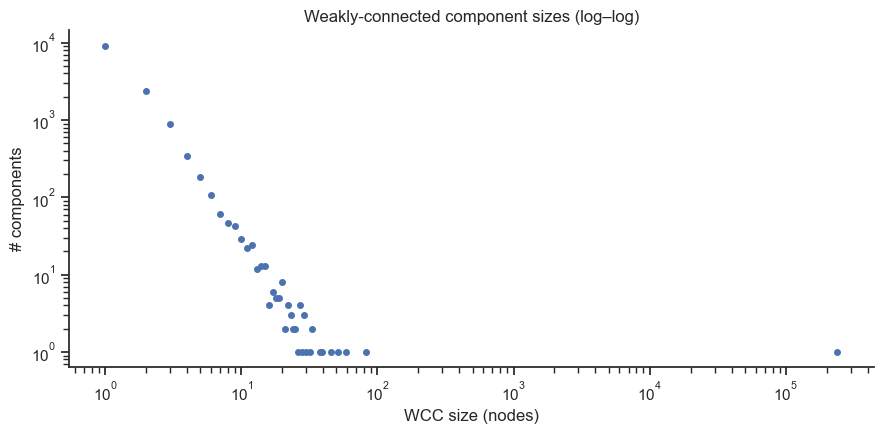

In [5]:
wcc_sizes = pd.Series([len(c) for c in wccs])
size_counts = wcc_sizes.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.loglog(size_counts.index, size_counts.values, "o", markersize=4)
ax.set_xlabel("WCC size (nodes)")
ax.set_ylabel("# components")
ax.set_title("Weakly-connected component sizes (log–log)")
plt.tight_layout()
plt.show()

## 3. How fast has mathematics grown?

### 3.1 Per year and cumulative

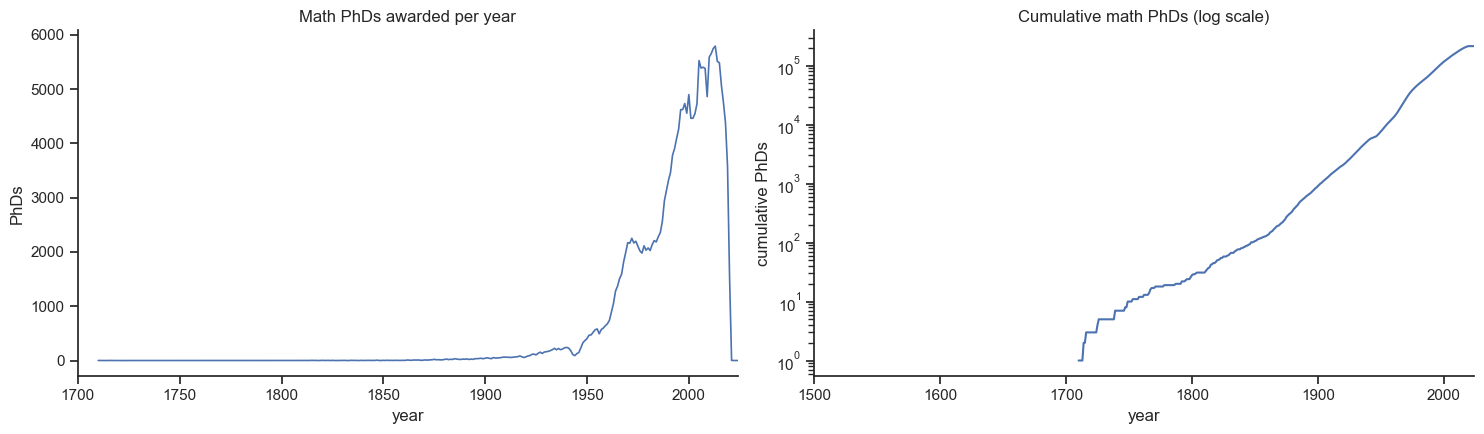

In [6]:
y_min, y_max = int(years.min()), int(years.max())
per_year = years.value_counts().sort_index().reindex(range(y_min, y_max + 1), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(per_year.index, per_year.values, linewidth=1.2)
axes[0].set_title("Math PhDs awarded per year")
axes[0].set_xlabel("year")
axes[0].set_ylabel("PhDs")
axes[0].set_xlim(1700, y_max)

axes[1].plot(per_year.index, per_year.cumsum().values, linewidth=1.5)
axes[1].set_title("Cumulative math PhDs (log scale)")
axes[1].set_xlabel("year")
axes[1].set_ylabel("cumulative PhDs")
axes[1].set_yscale("log")
axes[1].set_xlim(1500, y_max)
plt.tight_layout()
plt.show()

### 3.2 Doubling time

Cumulative PhDs look roughly exponential on a log scale — meaning the *rate* of math production has been compounding. We can quantify that by fitting $\log(\text{cumulative}) = a + b \cdot t$ on sliding windows. The doubling time is $\ln 2 / b$.

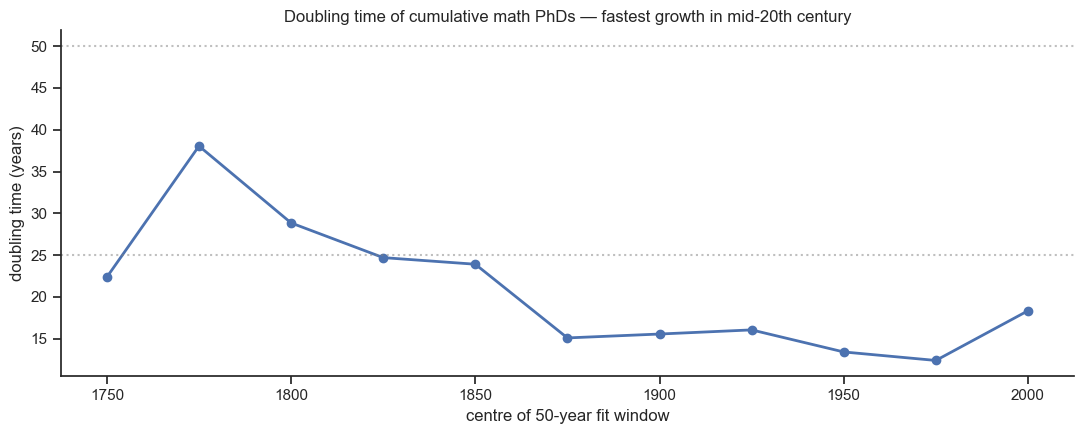

,centre,doubling_yrs
0,1750,22.375037
1,1775,38.051356
2,1800,28.852217
3,1825,24.704787
4,1850,23.912978
5,1875,15.099605
6,1900,15.564570
7,1925,16.059060
8,1950,13.420855
9,1975,12.403901


In [7]:
cumulative = per_year.cumsum()
# Fit log-linear over 50-year windows centred at each decade
window = 50
centres = list(range(1750, 2010, 25))
doublings = []
for c in centres:
    sl = cumulative.loc[c - window // 2: c + window // 2]
    sl = sl[sl > 0]
    if len(sl) < 10:
        continue
    b, a = np.polyfit(sl.index, np.log(sl.values), 1)
    doublings.append({"centre": c, "doubling_yrs": np.log(2) / b})
doublings = pd.DataFrame(doublings)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(doublings["centre"], doublings["doubling_yrs"], "o-", linewidth=2)
ax.axhline(50, color="grey", linestyle=":", alpha=0.5)
ax.axhline(25, color="grey", linestyle=":", alpha=0.5)
ax.set_xlabel("centre of 50-year fit window")
ax.set_ylabel("doubling time (years)")
ax.set_title("Doubling time of cumulative math PhDs — fastest growth in mid-20th century")
plt.tight_layout()
plt.show()
doublings

### 3.3 Per capita

Absolute growth conflates "more math" with "more humans alive". Normalising by world population (HYDE 3.3 for 1500–1950, UN WPP 2024 onward, linearly interpolated) tells a different story.

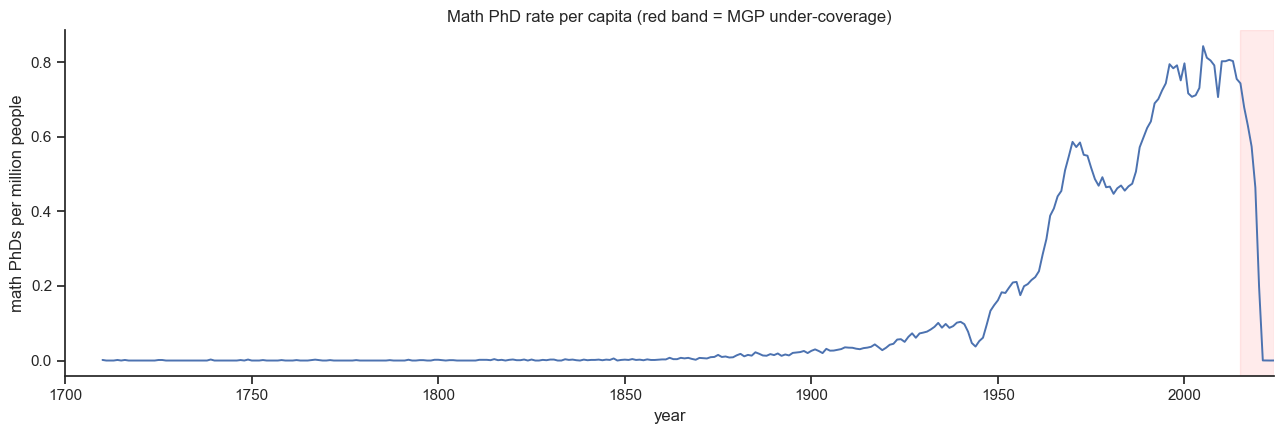

In [8]:
WORLD_POP_MILLIONS = pd.Series({
    1500:  461, 1600:  554, 1700:  603, 1750:  770,
    1800:  989, 1850: 1262, 1900: 1654,
    1950: 2499, 1960: 3019, 1970: 3700, 1980: 4444,
    1990: 5316, 2000: 6143, 2010: 6957, 2020: 7795, 2024: 8119,
})
pop_full = WORLD_POP_MILLIONS.reindex(range(1500, 2025)).interpolate()
rate = (per_year / pop_full).dropna()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(rate.index, rate.values, linewidth=1.4)
ax.axvspan(2015, rate.index.max(), color="red", alpha=0.08)
ax.set_xlim(1700, int(rate.index.max()))
ax.set_xlabel("year")
ax.set_ylabel("math PhDs per million people")
ax.set_title("Math PhD rate per capita (red band = MGP under-coverage)")
plt.tight_layout()
plt.show()

## 4. Who are the patriarchs?

The naive answer — PageRank — fails on this graph for a subtle reason: edges go *advisor → student*, so PageRank flows *downward*, concentrating rank on recent leaves who inherit "rank mass" from prestigious ancestors. To find influential **advisors**, you have to **reverse the graph** first.

But the more interpretable measure is just **descendant count**: how many mathematicians sit in your transitive student tree?

### 4.1 Top by descendants (transitive closure)

Computed in one reverse-topological pass.

In [9]:
topo = list(nx.topological_sort(G))
desc_sets = {}
for v in reversed(topo):
    s = set()
    for child in G.successors(v):
        s.add(child)
        s |= desc_sets[child]
    desc_sets[v] = s
desc_count = pd.Series({v: len(s) for v, s in desc_sets.items()}, name="descendants")

top = desc_count.sort_values(ascending=False).head(25)
top_df = df.loc[top.index, ["name", "year", "country", "school"]].copy()
top_df["descendants"] = top.values
top_df.reset_index(drop=True)

,name,year,country,school,descendants
0,Sharaf al-Dīn al-Ṭūsī,NaN,NaN,NaN,171043
1,Kamāl al-Dīn Ibn Yūnus,NaN,NaN,NaN,171042
2,Nasir al-Dīn al-Ṭūsī,NaN,NaN,NaN,171041
3,Shams al‐Dīn al‐Bukhārī,NaN,Iran,NaN,171040
4,Gregory Chioniadis,NaN,Iran,NaN,171039
5,Manuel Bryennios,NaN,NaN,NaN,171038
6,Theodore Metochites,NaN,NaN,NaN,171037
7,Gregory Palamas,NaN,NaN,NaN,171035
8,Nilos Kabasilas,NaN,NaN,NaN,171034
9,Demetrios Kydones,NaN,NaN,NaN,171033


The top-25 is dominated by **13th–15th century scholars** from the medieval Persian / Byzantine / Italian Renaissance tradition. This isn't an artifact — it's the actual structure of the giant component: nearly every modern mathematician descends from this lineage. Sharaf al-Dīn al-Ṭūsī sits above ~170,000 mathematical descendants (65% of the entire dataset).

To see what's happening in the *modern* part of the graph, restrict to people born / active after 1800:

In [10]:
modern_mask = df["year"].between(1800, 1980)
desc_modern = desc_count[desc_count.index.isin(df[modern_mask].index)]
top_modern = desc_modern.sort_values(ascending=False).head(20)
top_df = df.loc[top_modern.index, ["name", "year", "country", "school"]].copy()
top_df["descendants"] = top_modern.values
top_df.reset_index(drop=True)

,name,year,country,school,descendants
0,Siméon Denis Poisson,1800.0,France,École Polytechnique,115600
1,Julius Plücker,1823.0,Germany,Philipps-Universität Marburg,71307
2,Michel Chasles,1814.0,France,École Polytechnique,48966
3,Heinrich Ferdinand Scherk,1823.0,Germany,Universität Berlin,41939
4,Ernst Eduard Kummer,1831.0,Germany,Martin-Luther-Universität Halle-Wittenberg,41937
5,David Hilbert,1885.0,Germany,Universität Königsberg,34589
6,E. H. (Eliakim Hastings) Moore,1885.0,UnitedStates,Yale University,26036
7,Gaston Darboux,1866.0,France,École Normale Supérieure Paris,23615
8,Enno Heeren Dirksen,1820.0,Germany,Georg-August-Universität Göttingen,23566
9,Carl Gustav Jacob Jacobi,1825.0,Germany,Humboldt-Universität zu Berlin,23551


### 4.2 PageRank — fixed, on the reversed graph

In [11]:
# Reverse so PageRank flows student -> advisor, giving high rank to influential ADVISORS.
G_rev = G.reverse(copy=False)
pr = pd.Series(nx.pagerank(G_rev, alpha=0.85)).sort_values(ascending=False)
top = df.loc[pr.head(20).index, ["name", "year", "country", "school"]].copy()
top["pagerank"] = pr.head(20).values
top.reset_index(drop=True)

,name,year,country,school,pagerank
0,David Hilbert,1885.0,Germany,Universität Königsberg,0.012257
1,C. L. Ferdinand (Carl Louis) Lindemann,NaN,Germany,NaN,0.009541
2,E. H. (Eliakim Hastings) Moore,1885.0,UnitedStates,Yale University,0.008023
3,C. Felix (Christian) Klein,NaN,Germany,NaN,0.007697
4,Oswald Veblen,1903.0,UnitedStates,The University of Chicago,0.005156
5,Solomon Lefschetz,1911.0,UnitedStates,Clark University,0.004755
6,George David Birkhoff,1907.0,UnitedStates,The University of Chicago,0.004077
7,H. A. (Hubert Anson) Newton,NaN,UnitedStates,NaN,0.003918
8,Dimitri Fedorowitsch Egorov,1901.0,Russia,Lomonosov Moscow State University,0.003784
9,Erhard Schmidt,1905.0,Germany,Georg-August-Universität Göttingen,0.003716


### 4.3 The longest chain of mathematical descent

The longest path in a DAG — a single linear advisor → student chain — runs ~54 generations from medieval Persia through Renaissance Italy, Reformation Germany, Gauss, and out to a 21st-century US PhD.

In [12]:
longest = nx.dag_longest_path(G)
chain = pd.DataFrame(
    [{"step": i, **G.nodes[nid]} for i, nid in enumerate(longest)]
)[["step", "name", "year", "school", "country"]]
print(f"longest path: {len(chain)} generations\n")
chain

longest path: 54 generations



,step,name,year,school,country
0,0,Sharaf al-Dīn al-Ṭūsī,NaN,NaN,NaN
1,1,Kamāl al-Dīn Ibn Yūnus,NaN,NaN,NaN
2,2,Nasir al-Dīn al-Ṭūsī,NaN,NaN,NaN
3,3,Shams al‐Dīn al‐Bukhārī,NaN,NaN,Iran
4,4,Gregory Chioniadis,NaN,NaN,Iran
5,5,Manuel Bryennios,NaN,NaN,NaN
6,6,Theodore Metochites,NaN,NaN,NaN
7,7,Gregory Palamas,NaN,NaN,NaN
8,8,Nilos Kabasilas,NaN,NaN,NaN
9,9,Demetrios Kydones,NaN,NaN,NaN


/var/folders/cw/73nz0s3x6zx6nhpkxm7scs080000gn/T/ipykernel_39438/2873351161.py:17: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/fabianrigterink/Desktop/Code/math-genealogy-scraper/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


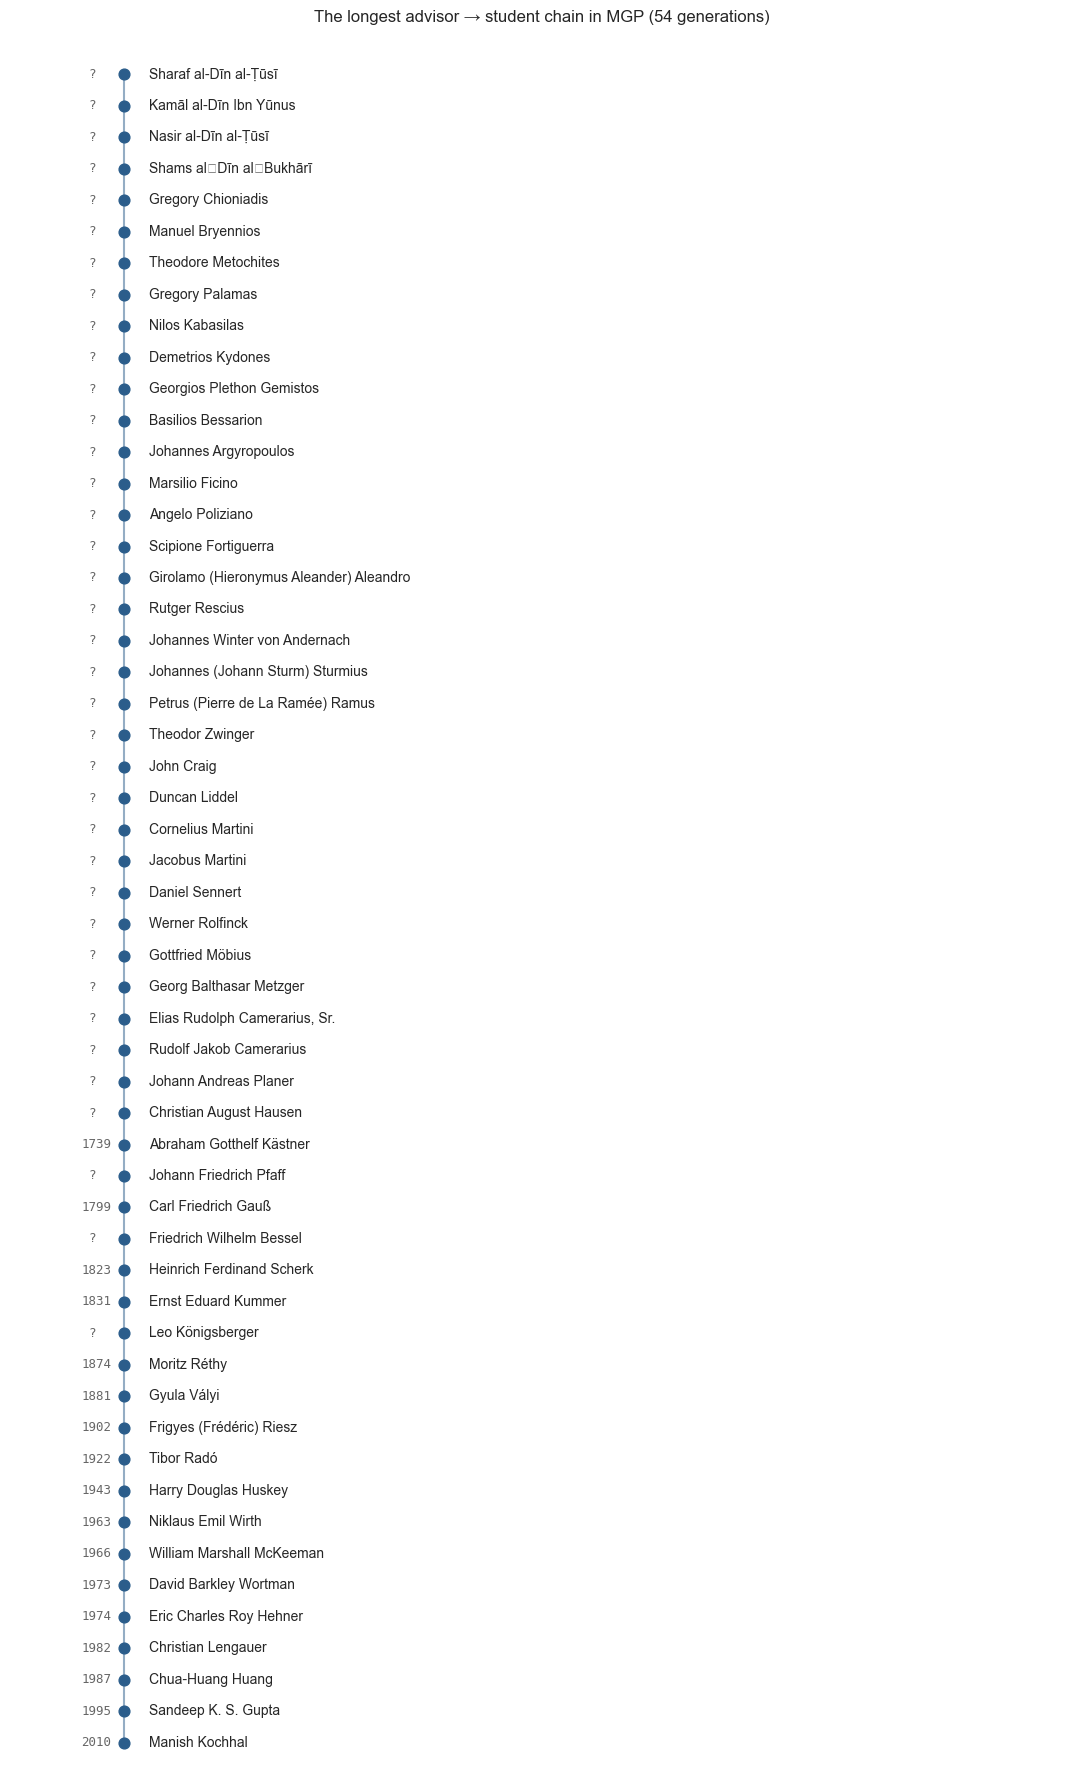

In [13]:
# Visualise the longest chain vertically — name + year on one line.
fig, ax = plt.subplots(figsize=(11, 18))
ys = np.arange(len(chain))[::-1]
ax.scatter([0] * len(chain), ys, s=60, color="#2b5d8b", zorder=3)
ax.plot([0] * len(chain), ys, color="#2b5d8b", linewidth=1.5, alpha=0.5, zorder=2)
for i, (_, row) in enumerate(chain.iterrows()):
    y_pos = ys[i]
    year_str = f"{int(row['year'])}" if pd.notna(row['year']) else "  ?  "
    ax.text(-0.02, y_pos, year_str, va="center", ha="right", fontsize=9,
            color="#666", family="monospace")
    ax.text(0.04, y_pos, row["name"], va="center", fontsize=10)
ax.set_ylim(-1, len(chain))
ax.set_xlim(-0.18, 1.5)
ax.set_title(f"The longest advisor → student chain in MGP ({len(chain)} generations)",
             fontsize=12, pad=15)
ax.axis("off")
plt.tight_layout()
plt.show()

### 4.4 Hilbert's direct lineage

Hilbert had 76 direct students. Many became influential advisors in their own right. The plot below shows Hilbert's direct students ranked by *their own* descendant count — a measure of how much of modern mathematics flows through each branch.

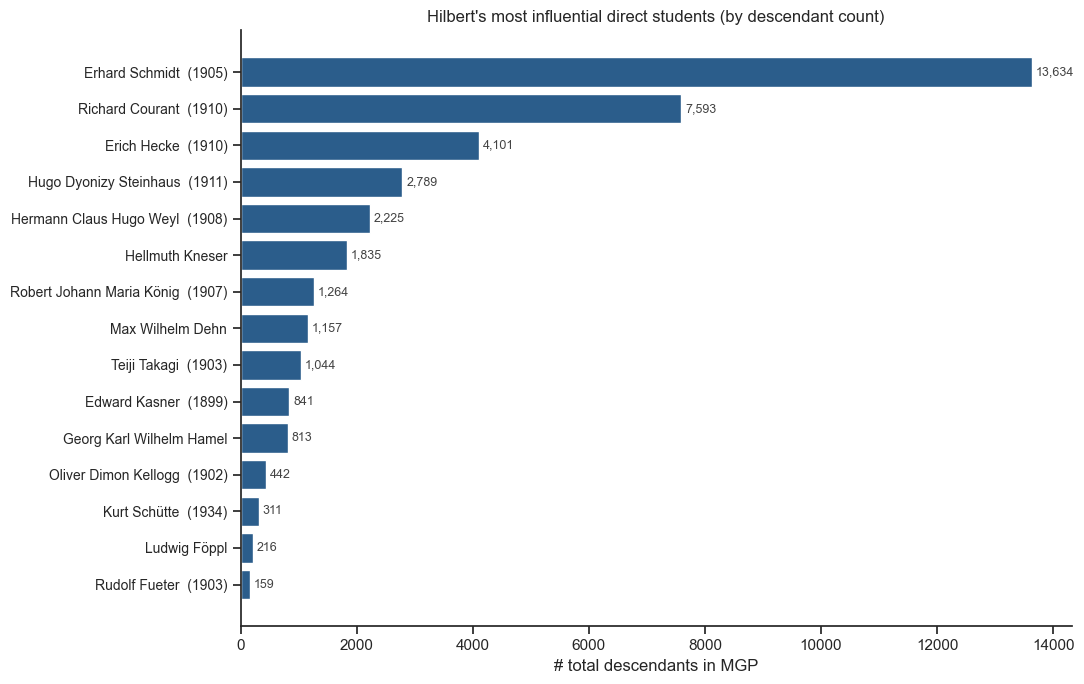

Hilbert advised 76 direct students.
Their combined descendant pool: 34,514.


,name,year,own_students,descendants
0,Erhard Schmidt,1905.0,43,13634
1,Richard Courant,1910.0,42,7593
2,Erich Hecke,1910.0,16,4101
3,Hugo Dyonizy Steinhaus,1911.0,16,2789
4,Hermann Claus Hugo Weyl,1908.0,21,2225
5,Hellmuth Kneser,NaN,18,1835
6,Robert Johann Maria König,1907.0,11,1264
7,Max Wilhelm Dehn,NaN,9,1157
8,Teiji Takagi,1903.0,5,1044
9,Edward Kasner,1899.0,12,841


In [14]:
hilbert = df[df["name"].fillna("").str.contains("David Hilbert")].index[0]
direct = list(G.successors(hilbert))
direct_stats = pd.DataFrame({
    "name": [G.nodes[v].get("name") for v in direct],
    "year": [G.nodes[v].get("year") for v in direct],
    "own_students": [G.out_degree(v) for v in direct],
    "descendants": [len(desc_sets[v]) for v in direct],
}, index=direct)
direct_stats = direct_stats.sort_values("descendants", ascending=False)

# Top-15 chart
top_d = direct_stats.head(15).iloc[::-1]  # reverse so largest is at top of barh
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(top_d)), top_d["descendants"], color="#2b5d8b")
labels = [f"{r['name']}  ({int(r['year'])})" if pd.notna(r['year']) else r['name']
          for _, r in top_d.iterrows()]
ax.set_yticks(range(len(top_d)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("# total descendants in MGP")
ax.set_title("Hilbert's most influential direct students (by descendant count)")
for i, v in enumerate(top_d["descendants"]):
    ax.text(v + max(top_d["descendants"]) * 0.005, i, f"{v:,}",
            va="center", fontsize=9, color="#444")
plt.tight_layout()
plt.show()

print(f"Hilbert advised {len(direct)} direct students.")
print(f"Their combined descendant pool: {len(set.union(*[desc_sets[v] for v in direct])):,}.")
direct_stats.head(15).reset_index(drop=True)

## 5. How long is a mathematical generation?

For every edge where both endpoints have a known year, compute `student.year - advisor.year`. That distribution tells us how many years separate one mathematical generation from the next.

edges with both years: 207,780 / 285,398
  mean:    19.9 years
  median:  19
  p10/p90: 8 / 34


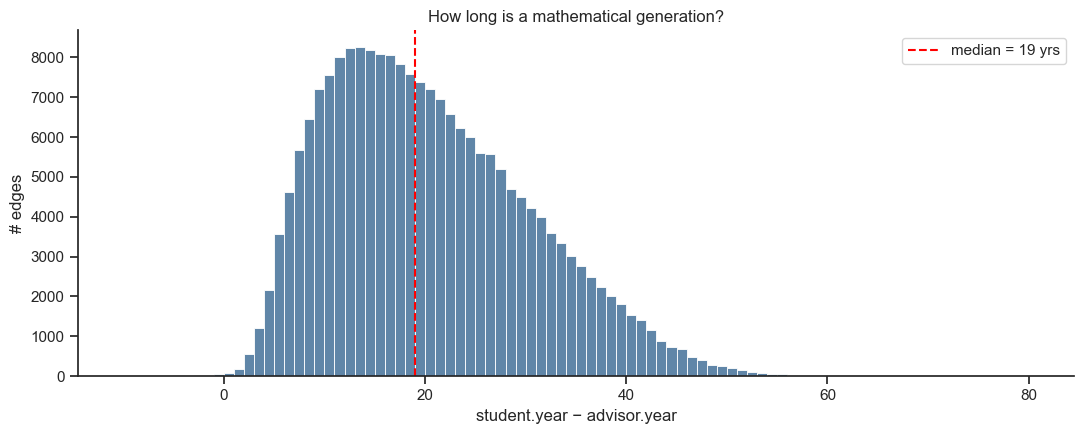

In [15]:
edges = pd.DataFrame(list(G.edges()), columns=["adv", "stu"])
edges["adv_year"] = edges["adv"].map(df["year"])
edges["stu_year"] = edges["stu"].map(df["year"])
edges["gap"] = edges["stu_year"] - edges["adv_year"]
gaps = edges["gap"].dropna()

print(f"edges with both years: {len(gaps):,} / {G.number_of_edges():,}")
print(f"  mean:    {gaps.mean():.1f} years")
print(f"  median:  {gaps.median():.0f}")
print(f"  p10/p90: {gaps.quantile(0.1):.0f} / {gaps.quantile(0.9):.0f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
clipped = gaps[(gaps >= -10) & (gaps <= 80)]
sns.histplot(clipped, bins=range(-10, 81), ax=ax, color="#2b5d8b")
ax.axvline(gaps.median(), color="red", linestyle="--", label=f"median = {gaps.median():.0f} yrs")
ax.set_xlabel("student.year − advisor.year")
ax.set_ylabel("# edges")
ax.set_title("How long is a mathematical generation?")
ax.legend()
plt.tight_layout()
plt.show()

### 5.1 Generation length over time

Has the gap between teacher and student widened or narrowed? Bucket by advisor's decade.

> ⚠️ **Selection bias at the recent end.** For advisors active in the 2000s+, the only students captured in the data are those who *already* finished — so we systematically miss long gaps. Treat the right end of this curve as a lower bound, not a trend.

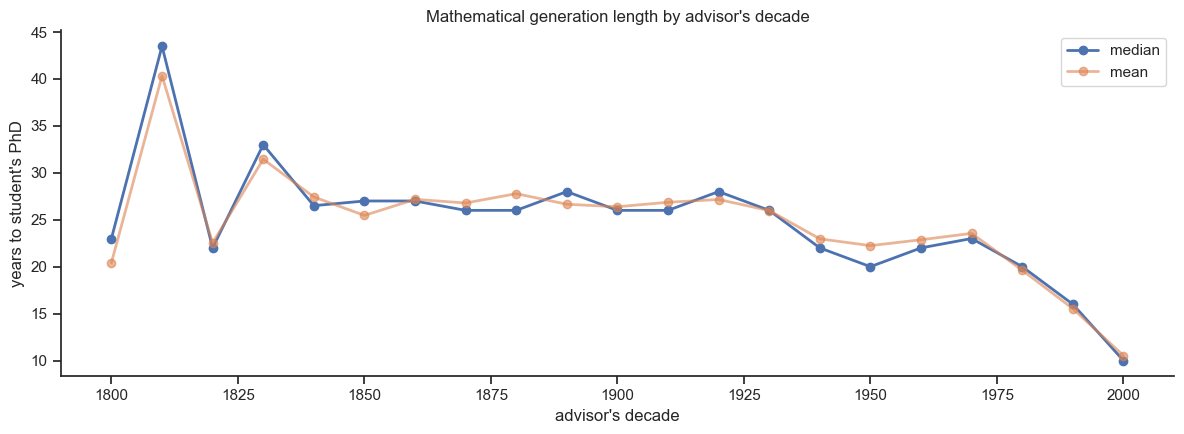

,median,mean,count
adv_decade,,,
1930.0,26.0,25.980025,4005
1940.0,22.0,22.967636,6365
1950.0,20.0,22.241752,16761
1960.0,22.0,22.869619,34775
1970.0,23.0,23.549032,40861
1980.0,20.0,19.629874,42907
1990.0,16.0,15.529585,35373
2000.0,10.0,10.532309,19004


In [16]:
edges["adv_decade"] = (edges["adv_year"] // 10) * 10
trend = edges.dropna(subset=["gap", "adv_decade"])
trend = trend[(trend["adv_decade"] >= 1800) & (trend["adv_decade"] < 2010)]
agg = trend.groupby("adv_decade")["gap"].agg(["median", "mean", "count"])

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(agg.index, agg["median"], "o-", linewidth=2, label="median")
ax.plot(agg.index, agg["mean"], "o-", linewidth=2, label="mean", alpha=0.6)
ax.set_xlabel("advisor's decade")
ax.set_ylabel("years to student's PhD")
ax.set_title("Mathematical generation length by advisor's decade")
ax.legend()
plt.tight_layout()
plt.show()
agg.tail(8)

## 6. How fertile is the average advisor?

### 6.1 Out-degree distribution

Most mathematicians never advise anyone (they're leaves of the tree). Among those who do, the fertility distribution is heavy-tailed.

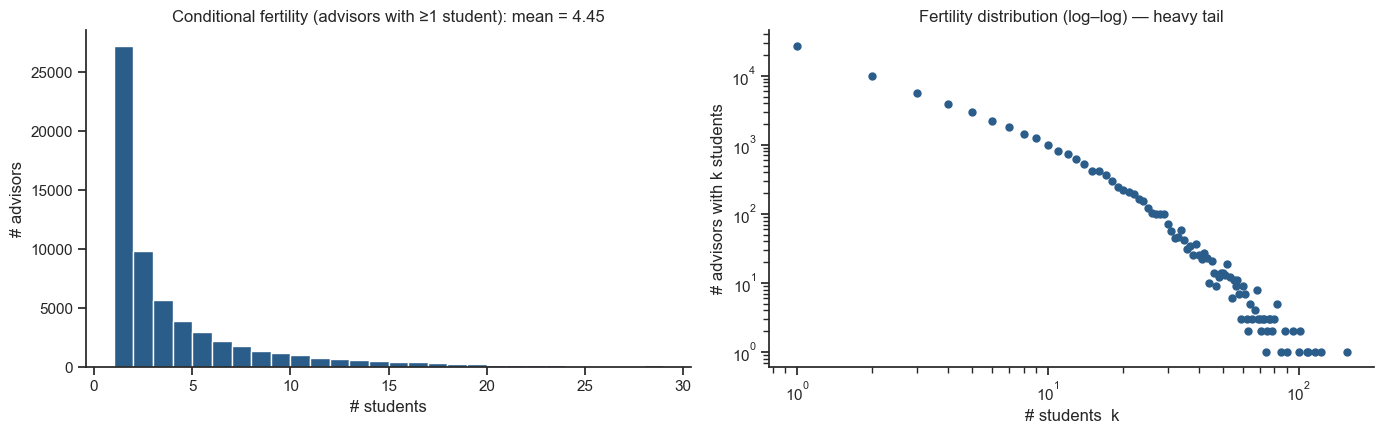

Total mathematicians:                    262,967
  with at least one student:             64,123  (24.4%)
  among those, median # students:        2
  among those, mean # students:          4.45
  with ≥10 students:                     7,725
  with ≥20 students:                     2,274


In [17]:
out_deg = pd.Series(dict(G.out_degree()), name="students")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Histogram of #students for those with >=1
fertile = out_deg[out_deg > 0]
axes[0].hist(fertile, bins=range(1, 30), color="#2b5d8b", edgecolor="white")
axes[0].set_xlabel("# students")
axes[0].set_ylabel("# advisors")
axes[0].set_title(f"Conditional fertility (advisors with ≥1 student): mean = {fertile.mean():.2f}")

# Log-log of the tail
counts = fertile.value_counts().sort_index()
axes[1].loglog(counts.index, counts.values, "o", markersize=5, color="#2b5d8b")
axes[1].set_xlabel("# students  k")
axes[1].set_ylabel("# advisors with k students")
axes[1].set_title("Fertility distribution (log–log) — heavy tail")
plt.tight_layout()
plt.show()

print(f"Total mathematicians:                    {len(out_deg):,}")
print(f"  with at least one student:             {(out_deg > 0).sum():,}  ({(out_deg > 0).mean():.1%})")
print(f"  among those, median # students:        {fertile.median():.0f}")
print(f"  among those, mean # students:          {fertile.mean():.2f}")
print(f"  with ≥10 students:                     {(out_deg >= 10).sum():,}")
print(f"  with ≥20 students:                     {(out_deg >= 20).sum():,}")

### 6.2 Fertility over time

For each decade, what fraction of mathematicians ever advised at least one student? And conditional on advising, how many on average? Restrict to people who finished by 1980 so most of their career is captured by the dataset.

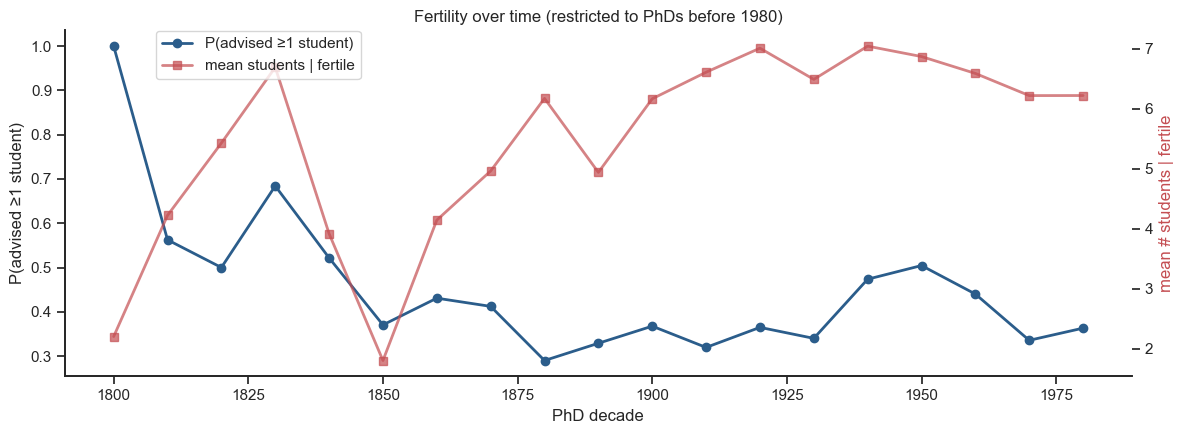

In [18]:
adv_year = df["year"]
fert = pd.DataFrame({"year": adv_year, "students": out_deg})
fert = fert.dropna(subset=["year"])
fert = fert[fert["year"].between(1800, 1980)]
fert["decade"] = (fert["year"] // 10).astype(int) * 10

agg = fert.groupby("decade").agg(
    n=("students", "size"),
    any_student=("students", lambda s: (s > 0).mean()),
    mean_if_fertile=("students", lambda s: s[s > 0].mean()),
)

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(agg.index, agg["any_student"], "o-", color="#2b5d8b", linewidth=2, label="P(advised ≥1 student)")
ax1.set_ylabel("P(advised ≥1 student)")
ax1.set_xlabel("PhD decade")
ax2 = ax1.twinx()
ax2.plot(agg.index, agg["mean_if_fertile"], "s-", color="#c44e52", linewidth=2, alpha=0.7,
         label="mean students | fertile")
ax2.set_ylabel("mean # students | fertile", color="#c44e52")
ax1.set_title("Fertility over time (restricted to PhDs before 1980)")
fig.legend(loc="upper left", bbox_to_anchor=(0.13, 0.93))
plt.tight_layout()
plt.show()

## 7. Has co-advising become more common?

Until ~1950 almost every PhD had a single advisor. The shift toward co-advising (and the rise of formal co-advisor structures, joint programs, and committee-style supervision) shows up clearly in the in-degree distribution over time.

In-degree distribution (whole graph):
  = 0 (no advisor recorded): 24,191  (9.2%)
  = 1:                       195,439
  ≥ 2:                       43,337  (16.5%)
  max:                       7


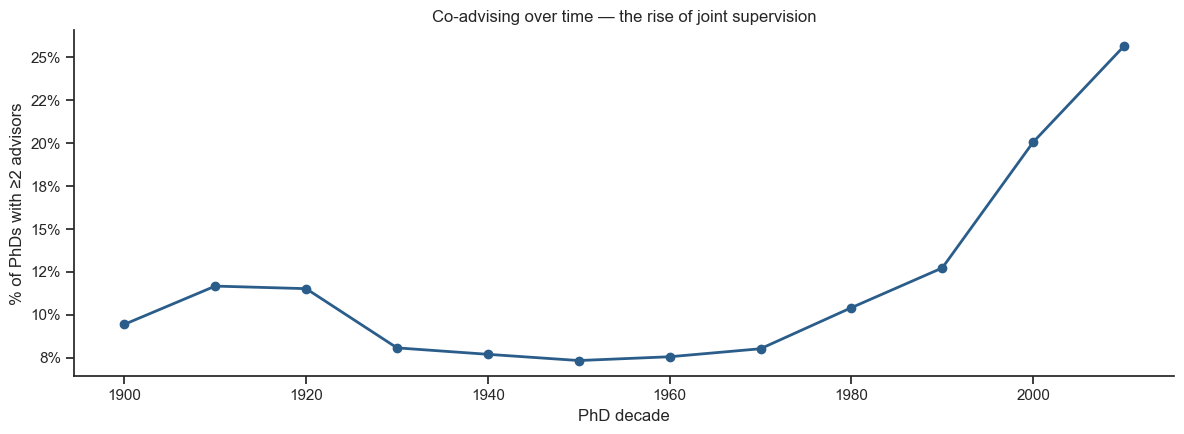

,n,pct_multi,mean_advisors
decade,,,
1940,2065,0.076998,1.094549
1950,5315,0.073377,1.086166
1960,12927,0.075578,1.084760
1970,21197,0.080247,1.089843
1980,23903,0.104171,1.113835
1990,41360,0.127321,1.135303
2000,49663,0.200592,1.215052
2010,47981,0.256539,1.287727


In [19]:
in_deg = pd.Series(dict(G.in_degree()), name="n_advisors")
print(f"In-degree distribution (whole graph):")
print(f"  = 0 (no advisor recorded): {(in_deg == 0).sum():,}  ({(in_deg == 0).mean():.1%})")
print(f"  = 1:                       {(in_deg == 1).sum():,}")
print(f"  ≥ 2:                       {(in_deg >= 2).sum():,}  ({(in_deg >= 2).mean():.1%})")
print(f"  max:                       {in_deg.max()}")

co_adv = pd.DataFrame({"year": df["year"], "n_advisors": in_deg})
co_adv = co_adv.dropna(subset=["year"])
co_adv = co_adv[(co_adv["year"] >= 1900) & (co_adv["year"] <= 2018)]
co_adv["decade"] = (co_adv["year"] // 10).astype(int) * 10
trend = co_adv.groupby("decade").agg(
    n=("n_advisors", "size"),
    pct_multi=("n_advisors", lambda s: (s >= 2).mean()),
    mean_advisors=("n_advisors", lambda s: s[s >= 1].mean()),
)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(trend.index, trend["pct_multi"] * 100, "o-", linewidth=2, color="#2b5d8b")
ax.set_xlabel("PhD decade")
ax.set_ylabel("% of PhDs with ≥2 advisors")
ax.set_title("Co-advising over time — the rise of joint supervision")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()
trend.tail(8)

## 8. Where does math happen?

### 8.1 Top universities all-time

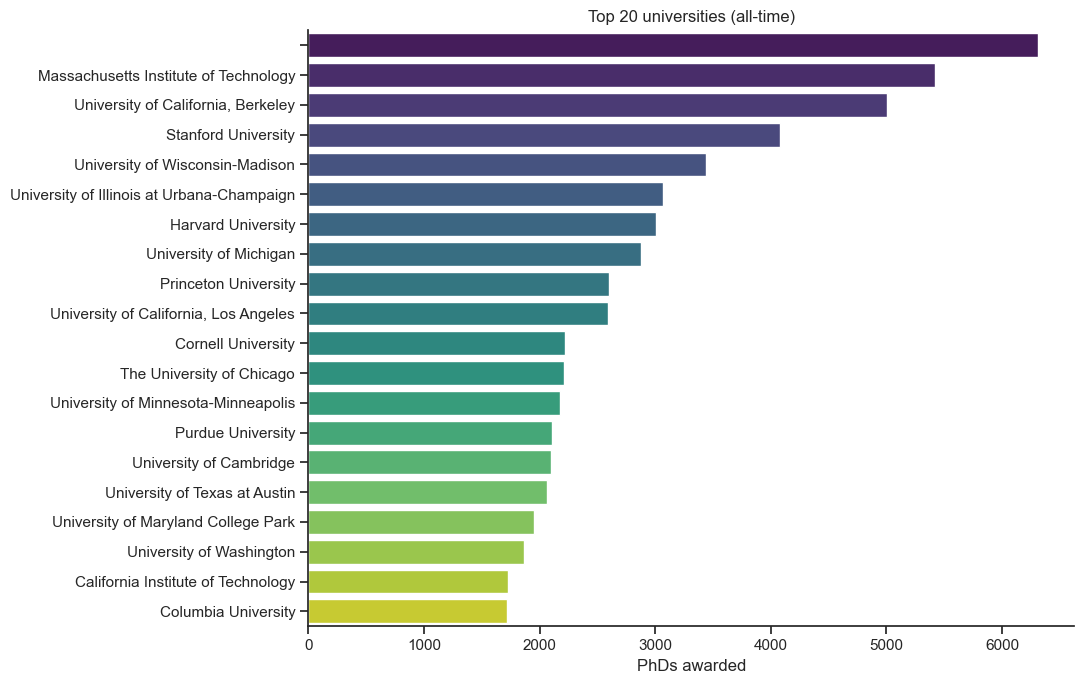

In [20]:
top_schools = df["school"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(x=top_schools.values, y=top_schools.index,
            hue=top_schools.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("PhDs awarded")
ax.set_ylabel("")
ax.set_title("Top 20 universities (all-time)")
plt.tight_layout()
plt.show()

### 8.2 Leading universities by era

In [21]:
df_era = df.dropna(subset=["year", "school"]).copy()
df_era["year"] = df_era["year"].astype(int)
df_era = df_era[(df_era["year"] >= 1700) & (df_era["year"] <= 2014)]
df_era["era"] = (df_era["year"] // 50) * 50

top_per_era = (df_era.groupby(["era", "school"]).size()
               .groupby(level=0).nlargest(5)
               .reset_index(level=0, drop=True)
               .rename("count").reset_index())
top_per_era

,era,school,count
0,1700,,1
1,1700,Académie royale des sciences de Paris,1
2,1700,Friedrich-Schiller-Universität Jena,1
3,1700,Les Hôpitals de la Charité et Salpêtrière de P...,1
4,1700,Philipps-Universität Marburg,1
5,1750,Uppsala Universitet,4
6,1750,Friedrich-Schiller-Universität Jena,2
7,1750,Georg-August-Universität Göttingen,2
8,1750,Eberhard-Karls-Universität Tübingen,1
9,1750,Friedrich-Alexander-Universität Erlangen-Nürnberg,1


### 8.3 A world map of mathematical output

Total PhDs by country, mapped — `country` here is the country in which the PhD was awarded, not nationality.

In [22]:
c_count = df["country"].value_counts().reset_index()
c_count.columns = ["country", "PhDs"]
c_count["iso3"] = coco.convert(c_count["country"].tolist(), to="ISO3", not_found=None)
c_count = c_count[c_count["iso3"].notna()].copy()
c_count["log10_PhDs"] = np.log10(c_count["PhDs"])

# Pre-formatted tick labels for the colorbar (log scale, but show raw counts).
ticks = [1, 10, 100, 1000, 10000, 100000]
fig = px.choropleth(
    c_count, locations="iso3", color="log10_PhDs",
    hover_name="country", hover_data={"iso3": False, "log10_PhDs": False, "PhDs": ":,"},
    color_continuous_scale="Viridis",
    projection="natural earth",
)
fig.update_coloraxes(
    colorbar=dict(
        title="PhDs",
        tickvals=[np.log10(t) for t in ticks],
        ticktext=[f"{t:,}" for t in ticks],
    )
)
fig.update_layout(
    title="Total math PhDs by country (log-scaled color)",
    height=520, margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

### 8.4 Top countries — all time and per decade

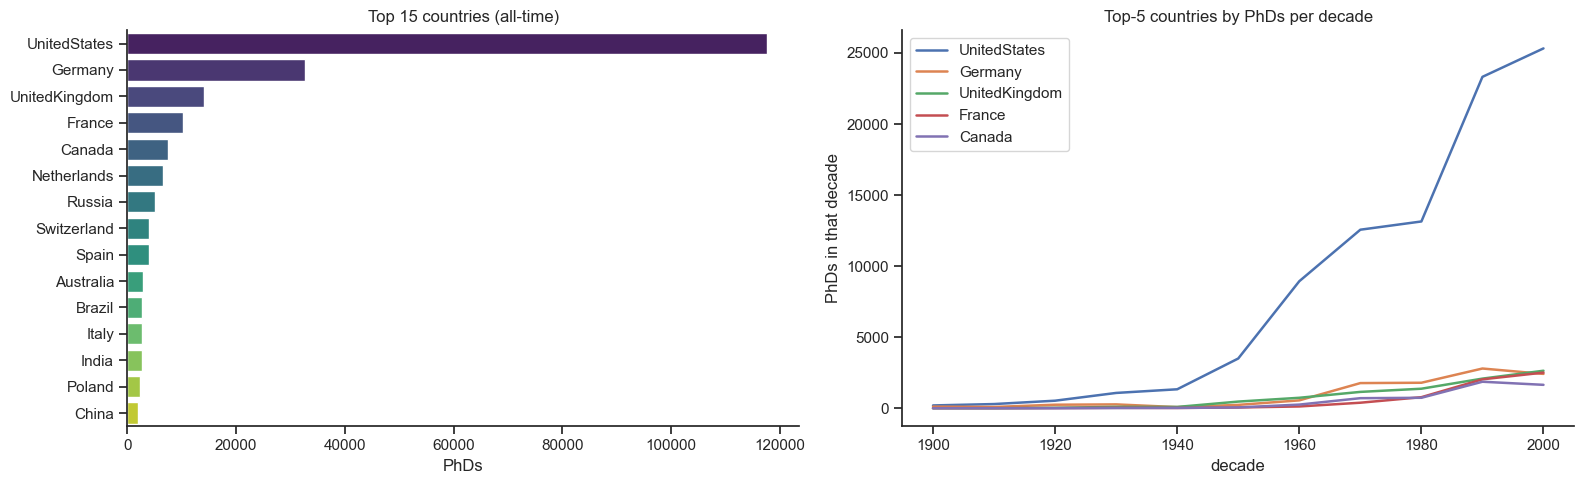

In [23]:
top_countries = df["country"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=top_countries.values, y=top_countries.index,
            hue=top_countries.index, palette="viridis", legend=False, ax=axes[0])
axes[0].set_xlabel("PhDs")
axes[0].set_ylabel("")
axes[0].set_title("Top 15 countries (all-time)")

df_c = df.dropna(subset=["year", "country"]).copy()
df_c["year"] = df_c["year"].astype(int)
df_c = df_c[(df_c["year"] >= 1900) & (df_c["year"] < 2010)]
df_c["decade"] = (df_c["year"] // 10) * 10
top_5 = df_c["country"].value_counts().head(5).index.tolist()
pivot = (df_c[df_c["country"].isin(top_5)]
         .groupby(["decade", "country"]).size().unstack(fill_value=0))[top_5]
for c in top_5:
    axes[1].plot(pivot.index, pivot[c].values, label=c, linewidth=1.8)
axes[1].set_xlabel("decade")
axes[1].set_ylabel("PhDs in that decade")
axes[1].set_title("Top-5 countries by PhDs per decade")
axes[1].legend()
plt.tight_layout()
plt.show()

### 8.5 Per capita

The US dominates absolute counts because it's huge. Per-capita normalisation flips the leaderboard.

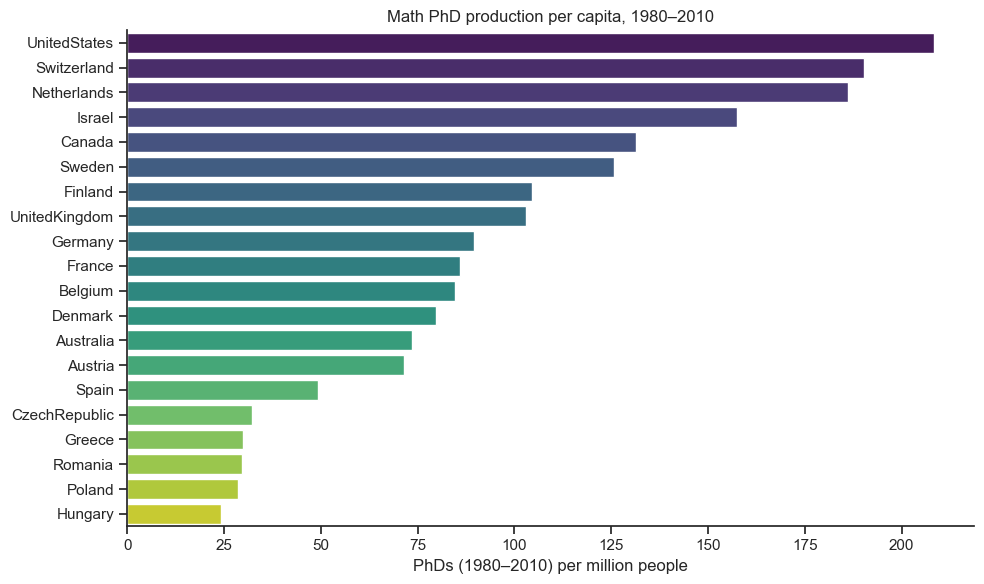

,PhDs_1980_2010,pop_millions,per_million
country,,,
UnitedStates,64354,309.0,208.265372
Switzerland,1523,8.0,190.375000
Netherlands,3163,17.0,186.058824
Israel,1260,8.0,157.500000
Canada,4465,34.0,131.323529
Sweden,1132,9.0,125.777778
Finland,522,5.0,104.400000
UnitedKingdom,6482,63.0,102.888889
Germany,7245,81.0,89.444444


In [24]:
# Rough 2010 population (millions). Just for the per-capita ranking.
POP_2010 = {
    "UnitedStates": 309, "Germany": 81, "UnitedKingdom": 63, "France": 65,
    "Canada": 34, "Netherlands": 17, "Russia": 143, "Switzerland": 8,
    "Spain": 47, "Australia": 22, "Brazil": 196, "Italy": 60,
    "India": 1234, "Poland": 38, "China": 1340, "Belgium": 11,
    "Austria": 8, "Sweden": 9, "Ukraine": 46, "Israel": 8,
    "Japan": 128, "Czechoslovakia": 16, "CzechRepublic": 11,
    "Norway": 5, "Denmark": 6, "Finland": 5, "Hungary": 10,
    "SouthKorea": 50, "Greece": 11, "Romania": 20,
}

c_recent = df.dropna(subset=["year", "country"]).copy()
c_recent = c_recent[c_recent["year"].between(1980, 2010)]
counts = c_recent["country"].value_counts()
counts = counts[counts >= 200]
per_cap = pd.DataFrame({"PhDs_1980_2010": counts})
per_cap["pop_millions"] = per_cap.index.map(POP_2010)
per_cap = per_cap.dropna()
per_cap["per_million"] = per_cap["PhDs_1980_2010"] / per_cap["pop_millions"]
per_cap = per_cap.sort_values("per_million", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=per_cap["per_million"], y=per_cap.index,
            hue=per_cap.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("PhDs (1980–2010) per million people")
ax.set_ylabel("")
ax.set_title("Math PhD production per capita, 1980–2010")
plt.tight_layout()
plt.show()
per_cap

### 8.6 Country firsts — when did each country get on the map?

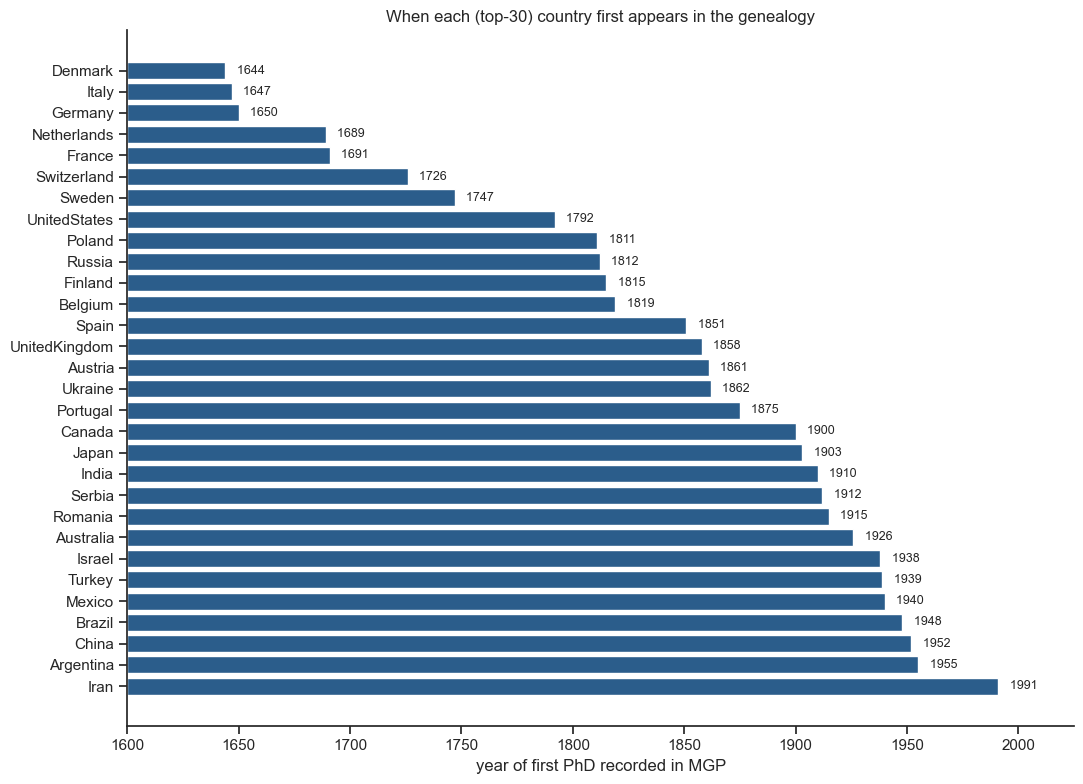

In [25]:
firsts = (df.dropna(subset=["country", "year"])
            .groupby("country")["year"].min()
            .sort_values())
top_countries_set = df["country"].value_counts().head(30).index
firsts_top = firsts.loc[firsts.index.intersection(top_countries_set)].sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(firsts_top.index[::-1], firsts_top.values[::-1] - 1600, left=1600, color="#2b5d8b")
for c, y in zip(firsts_top.index[::-1], firsts_top.values[::-1]):
    ax.text(int(y) + 2, c, f"  {int(y)}", va="center", fontsize=9)
ax.set_xlim(1600, 2025)
ax.set_xlabel("year of first PhD recorded in MGP")
ax.set_title("When each (top-30) country first appears in the genealogy")
plt.tight_layout()
plt.show()

### 8.7 Academic migration — where do PhDs go after training?

For each edge `(advisor, student)` where both have a known country, count the (advisor_country, student_country) pair. Diagonal (same-country) edges are dropped — only cross-border flows are visualised.

In [26]:
edges = pd.DataFrame(list(G.edges()), columns=["adv", "stu"])
edges["adv_c"] = edges["adv"].map(df["country"])
edges["stu_c"] = edges["stu"].map(df["country"])
mig = edges.dropna(subset=["adv_c", "stu_c"])
mig = mig[mig["adv_c"] != mig["stu_c"]]

top10 = df["country"].value_counts().head(10).index.tolist()
mig10 = mig[mig["adv_c"].isin(top10) & mig["stu_c"].isin(top10)]
flows = mig10.groupby(["adv_c", "stu_c"]).size().reset_index(name="n")
# Suppress the long tail of tiny flows
flows = flows[flows["n"] >= 50]

# Two-sided node lists: left = advisor country, right = student country
left = top10
right = [c + " " for c in top10]  # trailing space disambiguates label
all_labels = left + right
src_idx = {c: i for i, c in enumerate(left)}
tgt_idx = {c: i + len(left) for i, c in enumerate(left)}

palette = px.colors.qualitative.Bold + px.colors.qualitative.Pastel
node_colors = (palette[:len(left)] + palette[:len(left)])

sankey = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        label=all_labels,
        pad=20, thickness=22, line=dict(color="white", width=0.5),
        color=node_colors,
    ),
    link=dict(
        source=[src_idx[r["adv_c"]] for _, r in flows.iterrows()],
        target=[tgt_idx[r["stu_c"]] for _, r in flows.iterrows()],
        value=flows["n"].tolist(),
        color=["rgba(43,93,139,0.35)"] * len(flows),
        hovertemplate="%{source.label} → %{target.label}<br>%{value} PhDs<extra></extra>",
    ),
))
sankey.update_layout(
    title="Cross-border academic flows: advisor country (left) → student country (right) — top 10, edges ≥50",
    height=700, margin=dict(l=20, r=20, t=60, b=20),
    font=dict(size=13),
)
sankey.show()

The single biggest stream is **UK → US** (3,817 edges) — students trained by UK-based mathematicians going on to advise PhDs in the US. **Germany → US** (2,514) reflects the well-known mid-20th-century academic diaspora. The reciprocal **US → Canada** flow (3,093) shows how strongly the Canadian system is downstream of US training.

## 9. What gets studied — and inherited?

MGP subjects are 2-digit MSC (Mathematics Subject Classification) prefixes — e.g. `"90—Operations research"`. Subject coverage is only ~58%, so every subject-based result here is conditional on knowing both endpoints' MSCs.

### 9.1 Top subjects all-time

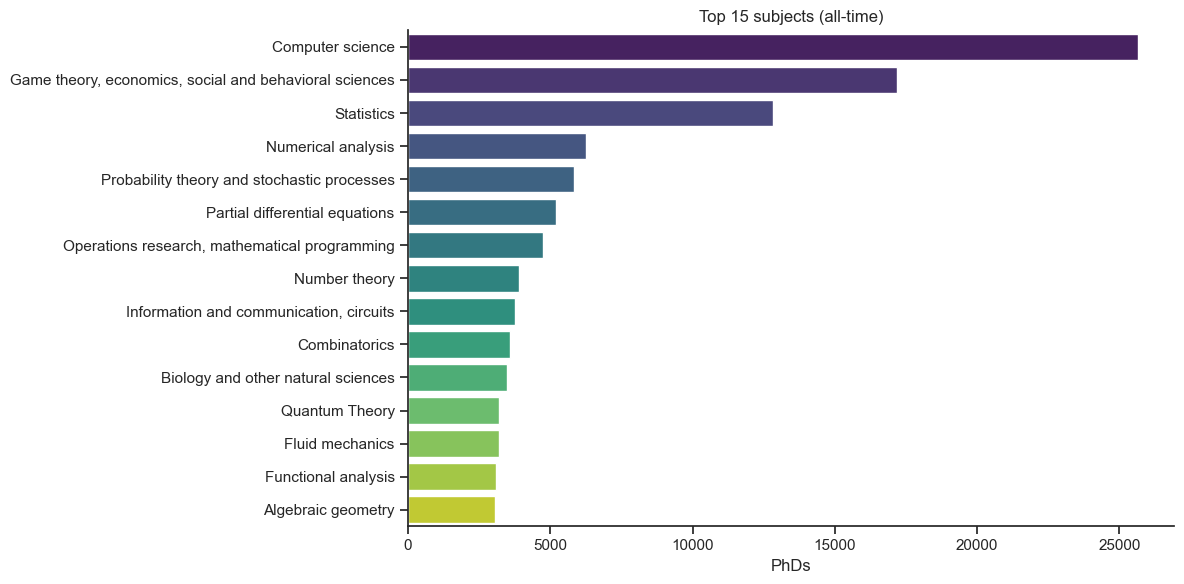

In [27]:
def clean_subject(s):
    if not isinstance(s, str): return None
    return re.sub(r"^\d{2}\s*[—\-]?\s*", "", s)

def msc_code(s):
    if not isinstance(s, str): return None
    m = re.match(r"(\d{2})", s)
    return m.group(1) if m else None

df["subject_clean"] = df["subject"].map(clean_subject)
df["msc"] = df["subject"].map(msc_code)

top_subjects = df["subject_clean"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_subjects.values, y=top_subjects.index,
            hue=top_subjects.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("PhDs")
ax.set_ylabel("")
ax.set_title("Top 15 subjects (all-time)")
plt.tight_layout()
plt.show()

### 9.2 Subject trends over time

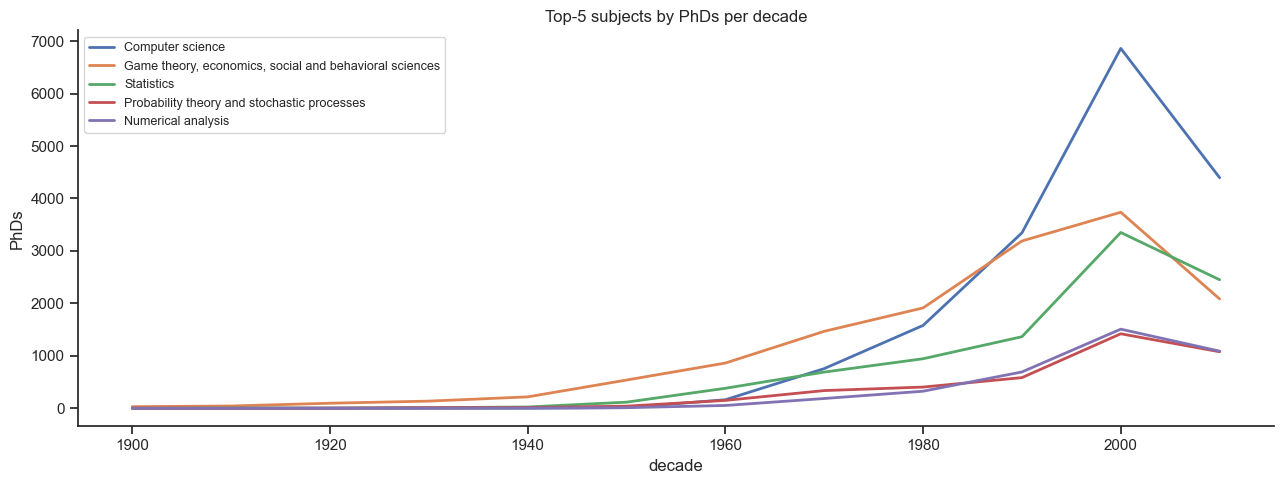

In [28]:
df_s = df.dropna(subset=["year", "subject_clean"]).copy()
df_s["year"] = df_s["year"].astype(int)
df_s = df_s[(df_s["year"] >= 1900) & (df_s["year"] < 2015)]
df_s["decade"] = (df_s["year"] // 10) * 10

top_5_subj = df_s["subject_clean"].value_counts().head(5).index.tolist()
pivot_s = (df_s[df_s["subject_clean"].isin(top_5_subj)]
           .groupby(["decade", "subject_clean"]).size()
           .unstack(fill_value=0))[top_5_subj]

fig, ax = plt.subplots(figsize=(13, 5))
for s in top_5_subj:
    ax.plot(pivot_s.index, pivot_s[s].values, label=s, linewidth=2)
ax.set_xlabel("decade")
ax.set_ylabel("PhDs")
ax.set_title("Top-5 subjects by PhDs per decade")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### 9.3 Subject birth dates

For each MSC code, the earliest PhD year in MGP. "Computer science" (MSC 68) shows up surprisingly early; "biology and other natural sciences" (MSC 92) is one of the youngest fields.

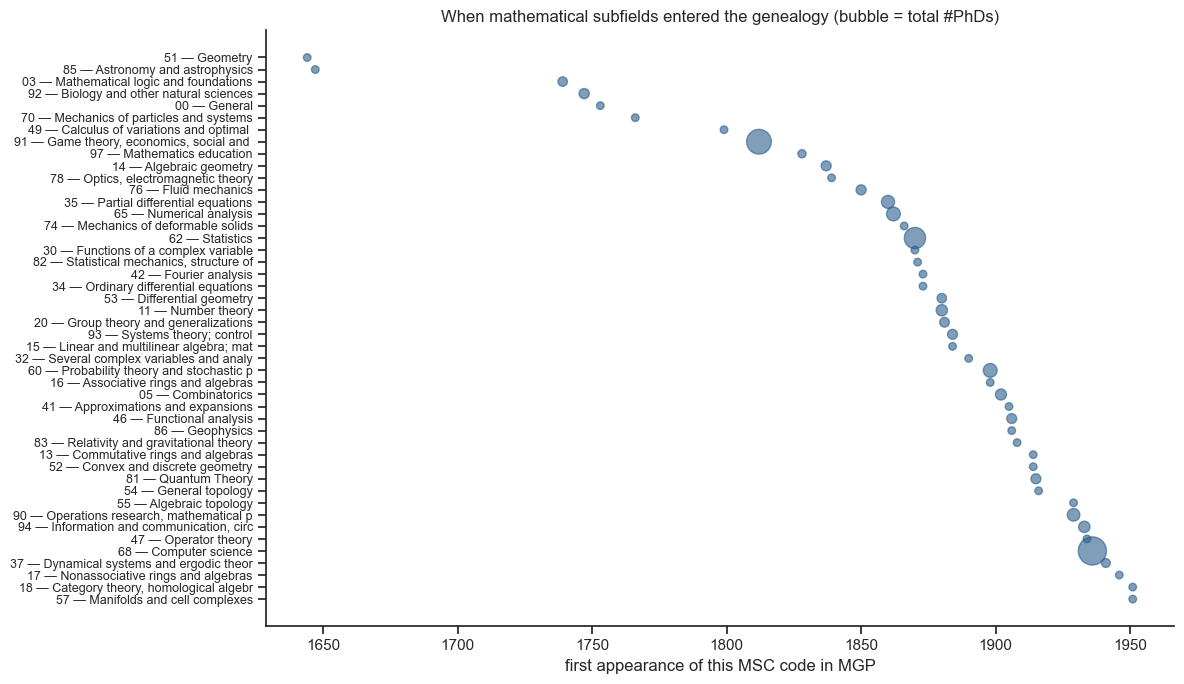

,first_year,count,sample_subject
msc,,,
51,1644.0,705,Geometry
85,1647.0,1421,Astronomy and astrophysics
03,1739.0,2327,Mathematical logic and foundations
92,1747.0,2706,Biology and other natural sciences
00,1753.0,760,General
70,1766.0,522,Mechanics of particles and systems
49,1799.0,826,Calculus of variations and optimal control
91,1812.0,15868,"Game theory, economics, social and behavioral ..."
97,1828.0,1744,Mathematics education


In [29]:
births = (df.dropna(subset=["msc", "year"])
            .groupby("msc")
            .agg(first_year=("year", "min"),
                 count=("year", "size"),
                 sample_subject=("subject_clean", "first"))
            .sort_values("first_year"))
births_top = births[births["count"] >= 500].sort_values("first_year")

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(births_top["first_year"], range(len(births_top)),
           s=np.clip(births_top["count"] / 50, 30, 600),
           alpha=0.6, color="#2b5d8b")
labels = [f"{m} — {(s or '')[:35]}" for m, s in zip(births_top.index, births_top["sample_subject"])]
ax.set_yticks(range(len(births_top)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("first appearance of this MSC code in MGP")
ax.set_title("When mathematical subfields entered the genealogy (bubble = total #PhDs)")
plt.tight_layout()
plt.show()
births_top.head(20)

### 9.4 Subject inheritance

For every edge with known subject codes on both endpoints, how often does the student inherit the advisor's MSC code?

In [30]:
edges = pd.DataFrame(list(G.edges()), columns=["adv", "stu"])
edges["adv_msc"] = edges["adv"].map(df["msc"])
edges["stu_msc"] = edges["stu"].map(df["msc"])
both = edges.dropna(subset=["adv_msc", "stu_msc"])
inherit_p = (both["adv_msc"] == both["stu_msc"]).mean()

# Random-pair baseline: if you picked two MSCs independently from the marginal,
# how often would they match?
msc_marginal = df["msc"].value_counts(normalize=True)
random_p = float((msc_marginal ** 2).sum())

print(f"edges with both MSCs known:                          {len(both):,}")
print(f"P(student MSC = advisor MSC):                        {inherit_p:.1%}")
print(f"random baseline (marginal-squared sum):              {random_p:.1%}")
print(f"inheritance vs random:                               {inherit_p / random_p:.1f}x")

edges with both MSCs known:                          108,752
P(student MSC = advisor MSC):                        69.8%
random baseline (marginal-squared sum):              6.0%
inheritance vs random:                               11.7x


Subject codes are strongly heritable — students stay in their advisor's MSC code about 70% of the time, **~12× more often than random pairing would predict**. Subfields are sticky.

A confusion-matrix-style view of the top-12 most-used MSC codes shows where the "off-diagonal" transitions go:

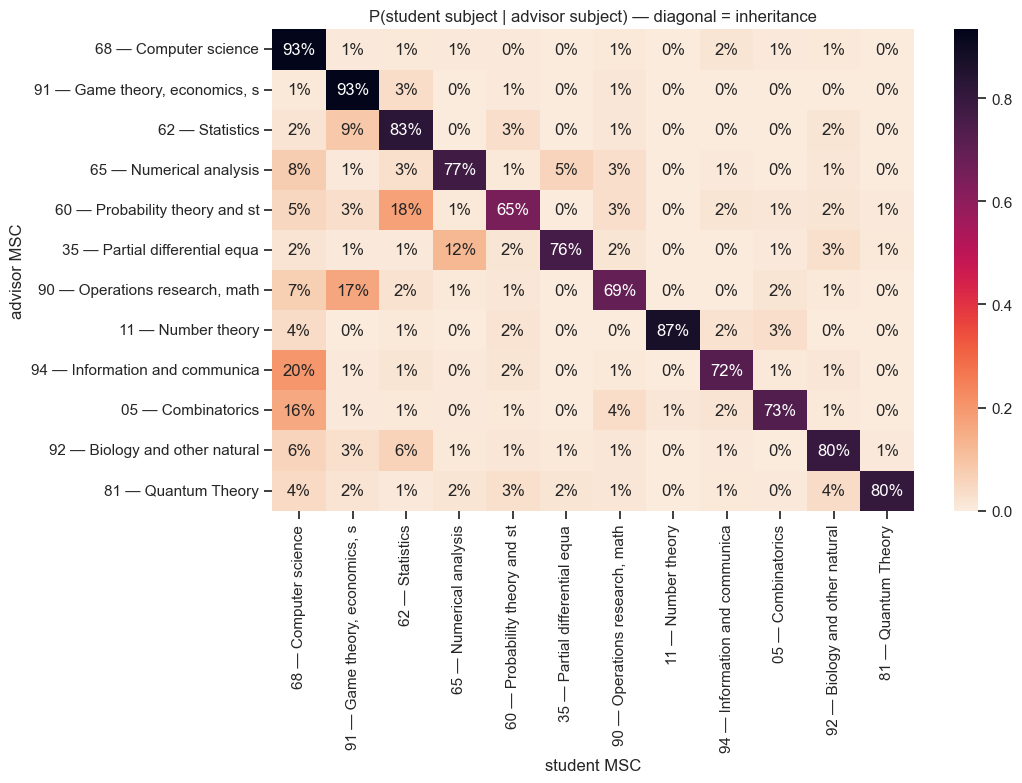

In [31]:
top12_msc = df["msc"].value_counts().head(12).index.tolist()
both12 = both[both["adv_msc"].isin(top12_msc) & both["stu_msc"].isin(top12_msc)]

# Row-normalised: P(student MSC | advisor MSC)
trans = (both12.groupby(["adv_msc", "stu_msc"]).size()
         .unstack(fill_value=0)
         .reindex(index=top12_msc, columns=top12_msc, fill_value=0))
trans_norm = trans.div(trans.sum(axis=1), axis=0)

# Resolve readable labels for each MSC code
msc_label = (df.dropna(subset=["msc"])
               .groupby("msc")["subject_clean"]
               .first()
               .reindex(top12_msc))
nice = [f"{m} — {(s or '')[:25]}" for m, s in zip(top12_msc, msc_label)]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(trans_norm, annot=True, fmt=".0%", cmap="rocket_r", ax=ax,
            xticklabels=nice, yticklabels=nice)
ax.set_xlabel("student MSC")
ax.set_ylabel("advisor MSC")
ax.set_title("P(student subject | advisor subject) — diagonal = inheritance")
plt.tight_layout()
plt.show()

## 10. A network-science deep dive

Following conventions from [Barabási — Network Science](https://networksciencebook.com/).

### 10.1 Degree distribution

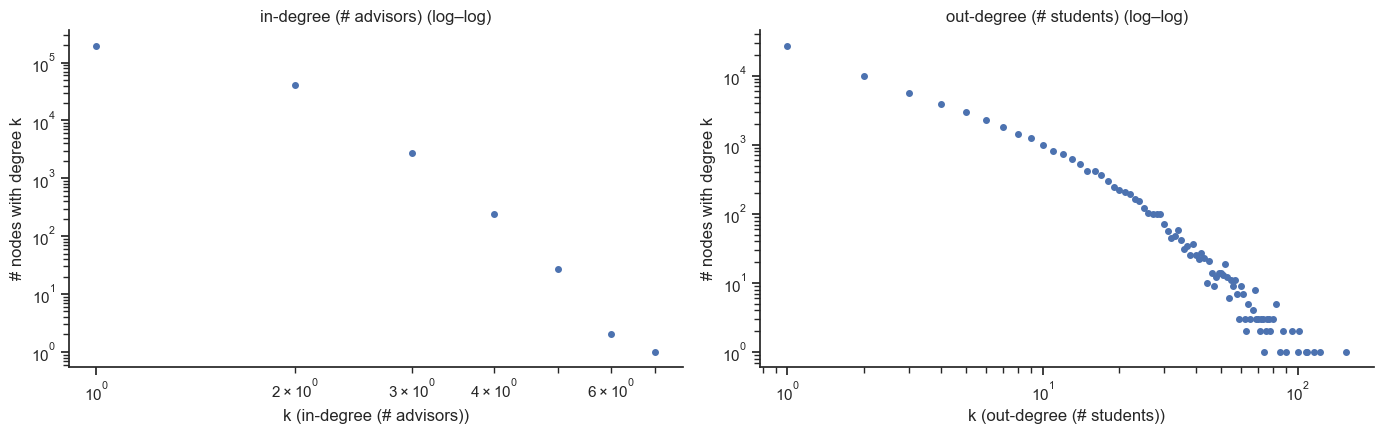

,in_degree,out_degree
count,262967.00000,262967.000000
mean,1.08530,1.085300
std,0.53814,3.803791
min,0.00000,0.000000
25%,1.00000,0.000000
50%,1.00000,0.000000
75%,1.00000,0.000000
max,7.00000,155.000000


In [32]:
in_deg = pd.Series(dict(G.in_degree()))
out_deg = pd.Series(dict(G.out_degree()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, deg, label in zip(axes, [in_deg, out_deg], ["in-degree (# advisors)", "out-degree (# students)"]):
    counts = deg[deg > 0].value_counts().sort_index()
    ax.loglog(counts.index, counts.values, "o", markersize=4)
    ax.set_xlabel(f"k ({label})")
    ax.set_ylabel("# nodes with degree k")
    ax.set_title(f"{label} (log–log)")
plt.tight_layout()
plt.show()

pd.DataFrame({"in_degree": in_deg.describe(), "out_degree": out_deg.describe()})

### 10.2 Is the fertility distribution really scale-free?

A heavy tail isn't enough — it might fit lognormal or exponential just as well. The [Clauset–Shalizi–Newman](https://arxiv.org/abs/0706.1062) method (implemented in the `powerlaw` library) (a) picks the optimal `x_min` by minimizing the KS distance, (b) fits a discrete power-law MLE, and (c) compares it against alternative distributions via a likelihood-ratio test.

In [33]:
fertile = out_deg[out_deg >= 1].values  # restrict to advisors with ≥1 student
fit = powerlaw.Fit(fertile, discrete=True, verbose=False)

print(f"optimal x_min:          {fit.xmin:.0f}")
print(f"power-law exponent α:   {fit.alpha:.3f}")
print(f"KS distance:            {fit.D:.4f}")
print(f"# samples in fit tail:  {(fertile >= fit.xmin).sum():,}")

# Likelihood-ratio test vs. alternative distributions.
# R > 0 favours power-law; p < 0.05 is significant.
print("\nLikelihood-ratio tests (R > 0 → power-law preferred over alternative):")
for alt in ("lognormal", "exponential", "stretched_exponential", "truncated_power_law"):
    R, p = fit.distribution_compare("power_law", alt, normalized_ratio=True)
    print(f"  vs {alt:<22}  R = {R:+.2f}   p = {p:.3g}")

optimal x_min:          11
power-law exponent α:   2.911
KS distance:            0.0609
# samples in fit tail:  6,724

Likelihood-ratio tests (R > 0 → power-law preferred over alternative):
  vs lognormal               R = -11.83   p = 2.9e-32
  vs exponential             R = -2.84   p = 0.00458
  vs stretched_exponential   R = -12.09   p = 1.16e-33


/Users/fabianrigterink/Desktop/Code/math-genealogy-scraper/venv/lib/python3.13/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


  vs truncated_power_law     R = -11.99   p = 0


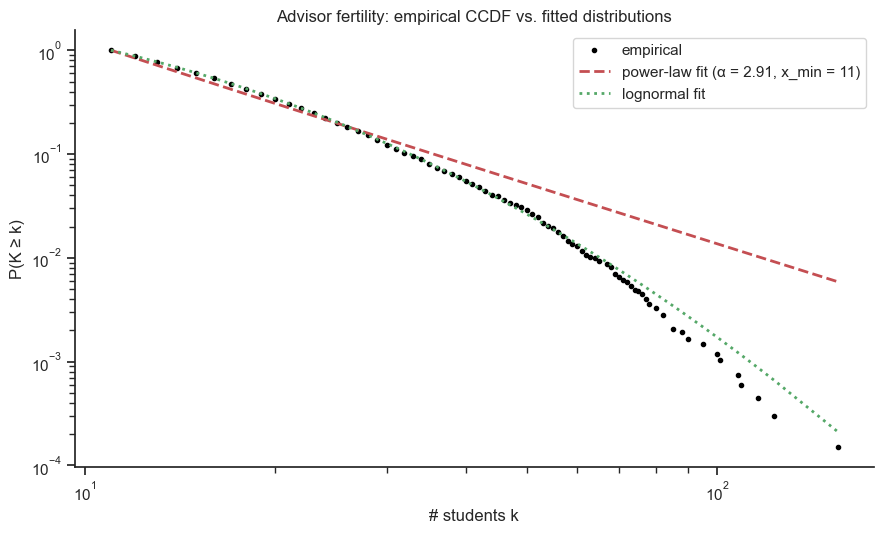

In [34]:
# CCDF: empirical vs fitted power-law and lognormal
fig, ax = plt.subplots(figsize=(9, 5.5))
fit.plot_ccdf(ax=ax, color="black", marker=".", linewidth=0, label="empirical")
fit.power_law.plot_ccdf(ax=ax, color="#c44e52", linestyle="--", linewidth=2,
                        label=f"power-law fit (α = {fit.alpha:.2f}, x_min = {fit.xmin:.0f})")
fit.lognormal.plot_ccdf(ax=ax, color="#55a868", linestyle=":", linewidth=2,
                        label="lognormal fit")
ax.set_xlabel("# students k")
ax.set_ylabel("P(K ≥ k)")
ax.set_title("Advisor fertility: empirical CCDF vs. fitted distributions")
ax.legend()
plt.tight_layout()
plt.show()

The α ≈ 2.9 falls in the canonical "scale-free" range — but **every alternative distribution beats pure power-law in the likelihood-ratio test**, lognormal most strongly (R ≈ −12, p ≈ 10⁻³²). This is the classic Broido–Clauset story: data with heavy tails often looks scale-free *visually* but turns out to fit a lognormal substantially better. So the safer claim here is that advisor fertility is **heavy-tailed**, not that it is strictly scale-free.

### 10.3 Degree assortativity

Do prolific advisors train future prolific advisors? Compare an actual to a randomised baseline.

In [35]:
r_out_in = nx.degree_assortativity_coefficient(G, x="out", y="in")
r_in_out = nx.degree_assortativity_coefficient(G, x="in", y="out")
print(f"out-degree (advisor) × in-degree (student):  r = {r_out_in:+.4f}")
print(f"in-degree (advisor) × out-degree (student):  r = {r_in_out:+.4f}")

out-degree (advisor) × in-degree (student):  r = -0.0964
in-degree (advisor) × out-degree (student):  r = +0.0128


### 10.4 Path lengths in the giant component

Sample 200 BFS sources from the giant WCC (undirected) — that's enough to give a high-fidelity distribution of inter-mathematician distances.

sample: 200 sources → 47,892,800 reachable pairs
  mean shortest path:     12.44
  median:                 12
  max (≤ true diameter):  41


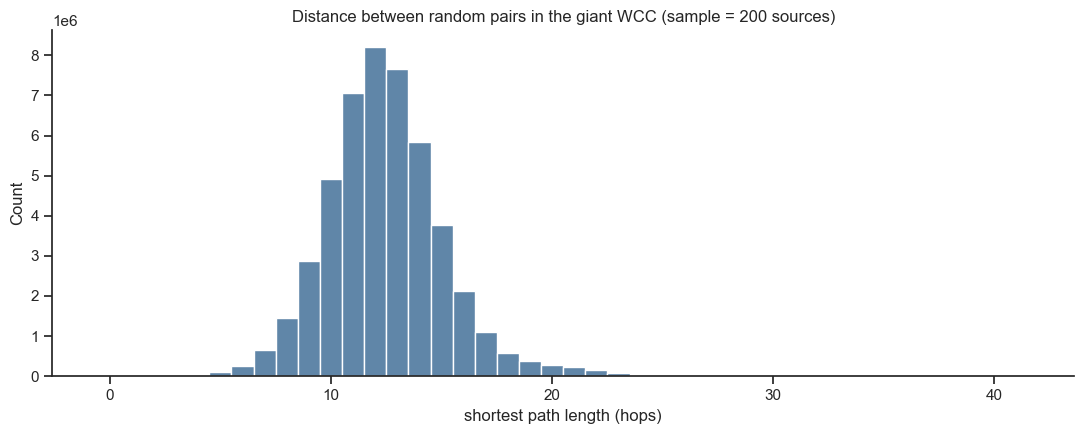

In [36]:
SAMPLE = 200
sources = RNG.choice(list(giant_wcc), size=SAMPLE, replace=False)
H = G.to_undirected().subgraph(giant_wcc)
lengths = []
for src in sources:
    sp = nx.single_source_shortest_path_length(H, src)
    lengths.extend(sp.values())
lengths = pd.Series(lengths)
print(f"sample: {SAMPLE} sources → {len(lengths):,} reachable pairs")
print(f"  mean shortest path:     {lengths.mean():.2f}")
print(f"  median:                 {lengths.median():.0f}")
print(f"  max (≤ true diameter):  {lengths.max()}")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(lengths, bins=range(0, int(lengths.max()) + 2), discrete=True, ax=ax, color="#2b5d8b")
ax.set_xlabel("shortest path length (hops)")
ax.set_title(f"Distance between random pairs in the giant WCC (sample = {SAMPLE} sources)")
plt.tight_layout()
plt.show()

### 10.5 Clustering coefficient

Compare local clustering to the Erdős–Rényi random baseline of `p = density`.

In [37]:
SAMPLE = 5000
H_full = G.to_undirected()
sample_nodes = RNG.choice(list(G.nodes), size=SAMPLE, replace=False)
local_cc = nx.clustering(H_full, sample_nodes)
avg_cc = float(np.mean(list(local_cc.values())))
p = nx.density(G)
print(f"avg local clustering (n={SAMPLE}):  {avg_cc:.4f}")
print(f"Erdős–Rényi baseline (p=density):   {p:.2e}")
print(f"observed / expected:                {avg_cc / p:,.0f}×")

avg local clustering (n=5000):  0.0208
Erdős–Rényi baseline (p=density):   4.13e-06
observed / expected:                5,043×


## 11. Gender

Names are inferred via the [`gender-guesser`](https://pypi.org/project/gender-guesser/) library, which classifies a given name as `male` / `mostly_male` / `andy` (androgynous) / `mostly_female` / `female` / `unknown`. This is a noisy approach — it works well on Western names and badly on East Asian and many African names. Treat the result as a lower bound on diversity, not a precise measurement.

In [38]:
import gender_guesser.detector as gender_guesser_detector
detector = gender_guesser_detector.Detector(case_sensitive=False)

def first_name(s):
    if not isinstance(s, str): return None
    parts = re.split(r"\s+", s.strip())
    return parts[0] if parts else None

df["first_name"] = df["name"].map(first_name)
df["gender"] = df["first_name"].map(
    lambda f: detector.get_gender(f) if isinstance(f, str) else None
)

# Collapse to coarse buckets
def coarse(g):
    if g in ("male", "mostly_male"):
        return "male"
    if g in ("female", "mostly_female"):
        return "female"
    if g in ("andy", "unknown", None):
        return "unknown"
    return "unknown"

df["gender_coarse"] = df["gender"].map(coarse)
counts = df["gender_coarse"].value_counts()
print("Classification (whole dataset):")
for k, v in counts.items():
    print(f"  {k:<10} {v:>8,}  ({v / len(df):.1%})")

Classification (whole dataset):
  male        168,885  (64.2%)
  unknown      57,374  (21.8%)
  female       36,708  (14.0%)


### 11.1 Share of female mathematicians over time

Restrict to people for whom the gender library returned a confident answer (male or female).

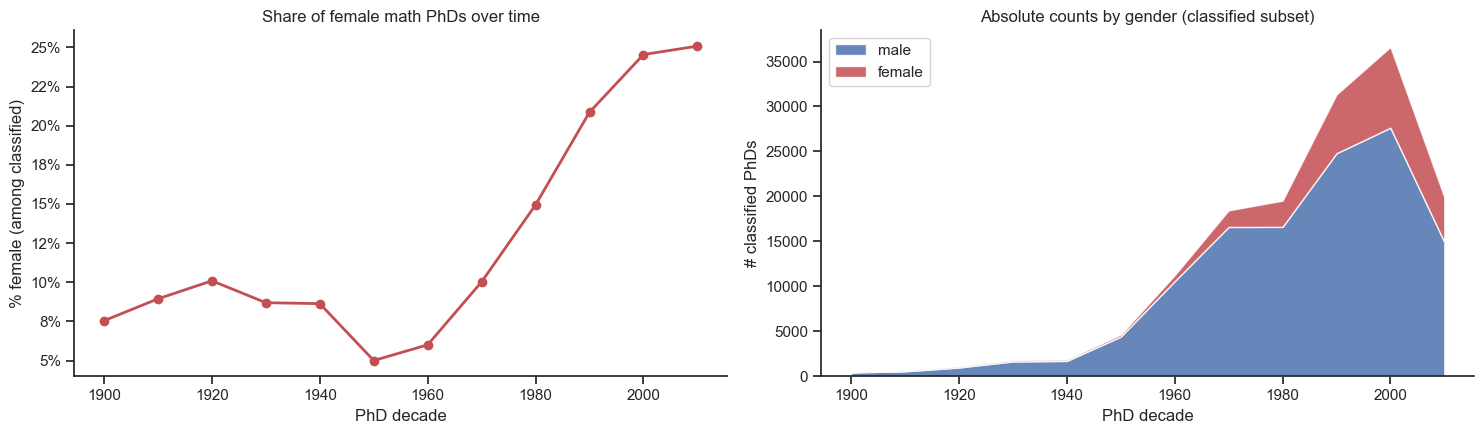

gender_coarse,female,male,pct_female
decade,,,
1940,161,1704,0.086327
1950,232,4409,0.049989
1960,675,10568,0.060037
1970,1850,16602,0.100260
1980,2919,16612,0.149455
1990,6538,24800,0.208629
2000,8991,27639,0.245455
2010,5002,14940,0.250827


In [39]:
mf = df[df["gender_coarse"].isin(["male", "female"])].dropna(subset=["year"]).copy()
mf["year"] = mf["year"].astype(int)
mf = mf[(mf["year"] >= 1900) & (mf["year"] < 2015)]
mf["decade"] = (mf["year"] // 10) * 10
by_dec = mf.groupby(["decade", "gender_coarse"]).size().unstack(fill_value=0)
by_dec["pct_female"] = by_dec["female"] / (by_dec["male"] + by_dec["female"])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(by_dec.index, by_dec["pct_female"] * 100, "o-", linewidth=2, color="#c44e52")
axes[0].set_xlabel("PhD decade")
axes[0].set_ylabel("% female (among classified)")
axes[0].set_title("Share of female math PhDs over time")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

axes[1].stackplot(by_dec.index,
                  by_dec["male"], by_dec["female"],
                  labels=["male", "female"],
                  colors=["#4c72b0", "#c44e52"], alpha=0.85)
axes[1].set_xlabel("PhD decade")
axes[1].set_ylabel("# classified PhDs")
axes[1].set_title("Absolute counts by gender (classified subset)")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()
by_dec.tail(8)

### 11.2 Share female by country (recent)

Restrict to 1990–2014, countries with ≥1,000 classified records.

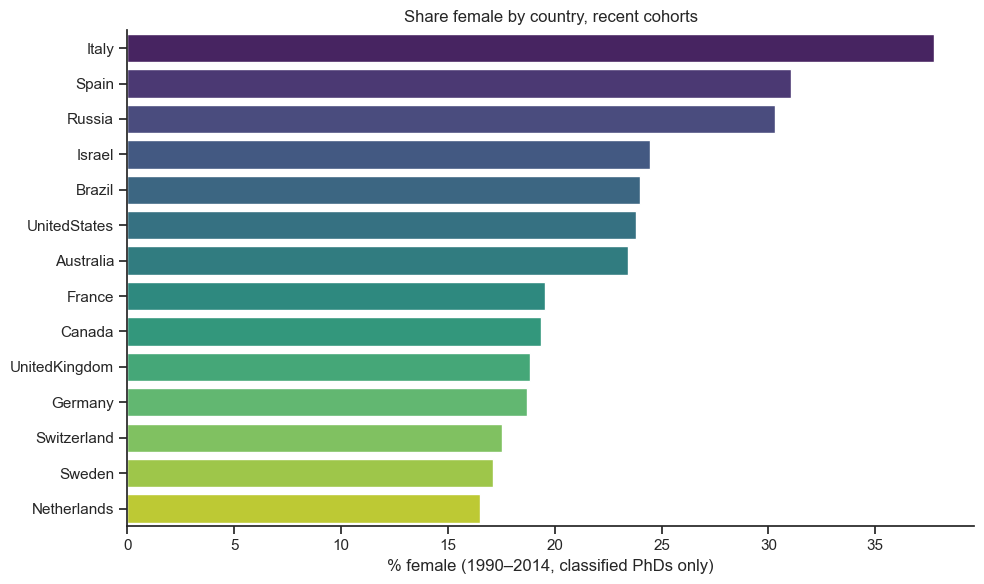

gender_coarse,female,male,total,pct_female
country,,,,
Italy,606,1000,1606,0.377335
Spain,656,1456,2112,0.310606
Russia,414,953,1367,0.302853
Israel,279,861,1140,0.244737
Brazil,279,883,1162,0.240103
UnitedStates,10013,32078,42091,0.237889
Australia,285,931,1216,0.234375
France,973,4003,4976,0.195539
Canada,605,2522,3127,0.193476


In [40]:
mf_recent = mf[mf["year"].between(1990, 2014)]
country_gender = mf_recent.groupby(["country", "gender_coarse"]).size().unstack(fill_value=0)
country_gender["total"] = country_gender["male"] + country_gender["female"]
country_gender = country_gender[country_gender["total"] >= 1000]
country_gender["pct_female"] = country_gender["female"] / country_gender["total"]
country_gender = country_gender.sort_values("pct_female", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=country_gender["pct_female"] * 100, y=country_gender.index,
            hue=country_gender.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("% female (1990–2014, classified PhDs only)")
ax.set_ylabel("")
ax.set_title("Share female by country, recent cohorts")
plt.tight_layout()
plt.show()
country_gender

### 11.3 Do female advisors disproportionately train female students?

In [41]:
edges = pd.DataFrame(list(G.edges()), columns=["adv", "stu"])
edges["adv_g"] = edges["adv"].map(df["gender_coarse"])
edges["stu_g"] = edges["stu"].map(df["gender_coarse"])
both = edges[edges["adv_g"].isin(["male", "female"]) & edges["stu_g"].isin(["male", "female"])]

cross = pd.crosstab(both["adv_g"], both["stu_g"], normalize="index")
print("P(student gender | advisor gender) — classified edges only:")
print(cross.round(3))

base_pct_female = (both["stu_g"] == "female").mean()
print(f"\nbaseline P(student female): {base_pct_female:.1%}")
print(f"P(female student | male advisor):    {((both['adv_g'] == 'male') & (both['stu_g'] == 'female')).sum() / (both['adv_g'] == 'male').sum():.1%}")
print(f"P(female student | female advisor):  {((both['adv_g'] == 'female') & (both['stu_g'] == 'female')).sum() / (both['adv_g'] == 'female').sum():.1%}")

P(student gender | advisor gender) — classified edges only:
stu_g   female   male
adv_g                
female   0.324  0.676
male     0.176  0.824

baseline P(student female): 18.7%
P(female student | male advisor):    17.6%
P(female student | female advisor):  32.4%


## 12. Thesis-title evolution

What did mathematicians actually write about? Out of 234,799 records with thesis titles, what words rose and fell?

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

th = df.dropna(subset=["thesis", "year"]).copy()
th["year"] = th["year"].astype(int)
th = th[(th["year"] >= 1900) & (th["year"] < 2015)]
th["decade"] = (th["year"] // 10) * 10
print(f"thesis titles in scope (1900-2014): {len(th):,}")

vec = CountVectorizer(min_df=50, max_df=0.4, ngram_range=(1, 1),
                       stop_words="english", token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{3,}\b",
                       max_features=8000)
X = vec.fit_transform(th["thesis"].str.lower())
vocab = vec.get_feature_names_out()
print(f"vocabulary: {len(vocab):,} terms")

# Per-decade word frequency (normalized by decade total)
decades = sorted(th["decade"].unique())
freq_by_decade = pd.DataFrame(index=vocab, columns=decades, dtype=float)
for d in decades:
    mask = (th["decade"] == d).values
    counts_d = np.asarray(X[mask].sum(axis=0)).ravel()
    freq_by_decade[d] = counts_d / counts_d.sum()
freq_by_decade.head(3)

thesis titles in scope (1900-2014): 178,142
vocabulary: 2,800 terms


,1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
abbildungen,0.0,0.00000,0.000315,0.000949,0.00014,0.000243,0.000274,0.000224,0.000252,0.000087,0.000022,0.000007
abelian,0.0,0.00111,0.001574,0.001107,0.00112,0.000925,0.002111,0.001354,0.000745,0.000533,0.000519,0.000635
ability,0.0,0.00000,0.000315,0.000158,0.00042,0.000049,0.000235,0.000200,0.000302,0.000109,0.000104,0.000036


### 12.1 First appearance year of a few signature words

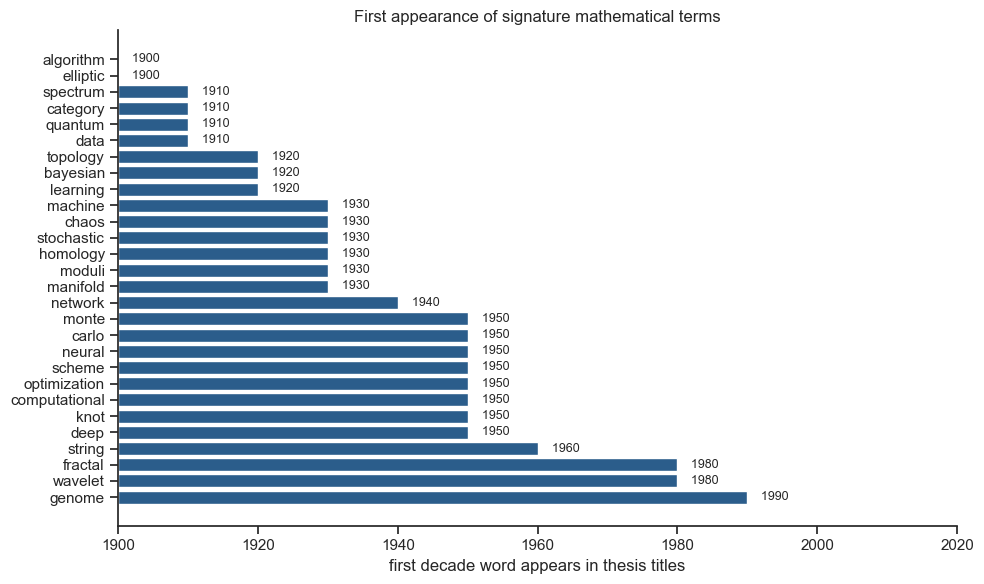

In [43]:
# For each term, the earliest decade in which it appears at all in titles.
watch = ["neural", "stochastic", "quantum", "computational", "optimization",
         "wavelet", "genome", "topology", "manifold", "scheme", "algorithm",
         "fractal", "chaos", "spectrum", "category", "homology", "knot",
         "bayesian", "monte", "carlo", "elliptic", "moduli", "string",
         "machine", "learning", "data", "network", "deep"]
watch = [w for w in watch if w in freq_by_decade.index]

first_year = {}
for w in watch:
    series = freq_by_decade.loc[w]
    nonzero = series[series > 0]
    if len(nonzero):
        first_year[w] = nonzero.index.min()
first_year = pd.Series(first_year).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(first_year.index[::-1], first_year.values[::-1] - 1900, left=1900, color="#2b5d8b")
for w, y in zip(first_year.index[::-1], first_year.values[::-1]):
    ax.text(int(y) + 1, w, f"  {int(y)}", va="center", fontsize=9)
ax.set_xlim(1900, 2020)
ax.set_xlabel("first decade word appears in thesis titles")
ax.set_title("First appearance of signature mathematical terms")
plt.tight_layout()
plt.show()

### 12.2 Top rising and falling words

For each word, fit a linear regression of frequency vs. decade. Largest positive slopes are "rising"; largest negative slopes are "falling".

In [44]:
# Only words present in at least 5 decades
present_in = (freq_by_decade > 0).sum(axis=1)
candidates = freq_by_decade[present_in >= 5]

# Slope per word (frequency growth per decade)
decade_x = np.array(decades, dtype=float)
slopes = candidates.apply(
    lambda row: np.polyfit(decade_x, row.values.astype(float), 1)[0], axis=1
)
recent_mean = candidates.iloc[:, -5:].mean(axis=1)
# Filter to words with non-trivial recent presence
slopes = slopes[recent_mean >= 1e-4]

rising = slopes.nlargest(15)
falling = slopes.nsmallest(15)
print("Top rising words (slope = Δfreq per decade):")
print(rising.round(7).to_string())
print("\nTop falling words:")
print(falling.round(7).to_string())

Top rising words (slope = Δfreq per decade):
models          0.000107
analysis        0.000093
data            0.000079
essays          0.000071
methods         0.000069
applications    0.000068
model           0.000067
systems         0.000061
algorithms      0.000055
based           0.000054
using           0.000052
control         0.000049
networks        0.000049
modeling        0.000048
estimation      0.000047

Top falling words:
theorie           -0.000165
curves            -0.000125
certain           -0.000113
linear            -0.000095
functions         -0.000094
order             -0.000093
plane             -0.000085
ordnung           -0.000083
einer             -0.000078
differential      -0.000077
study             -0.000071
equations         -0.000066
transformations   -0.000066
surfaces          -0.000064
groups            -0.000060


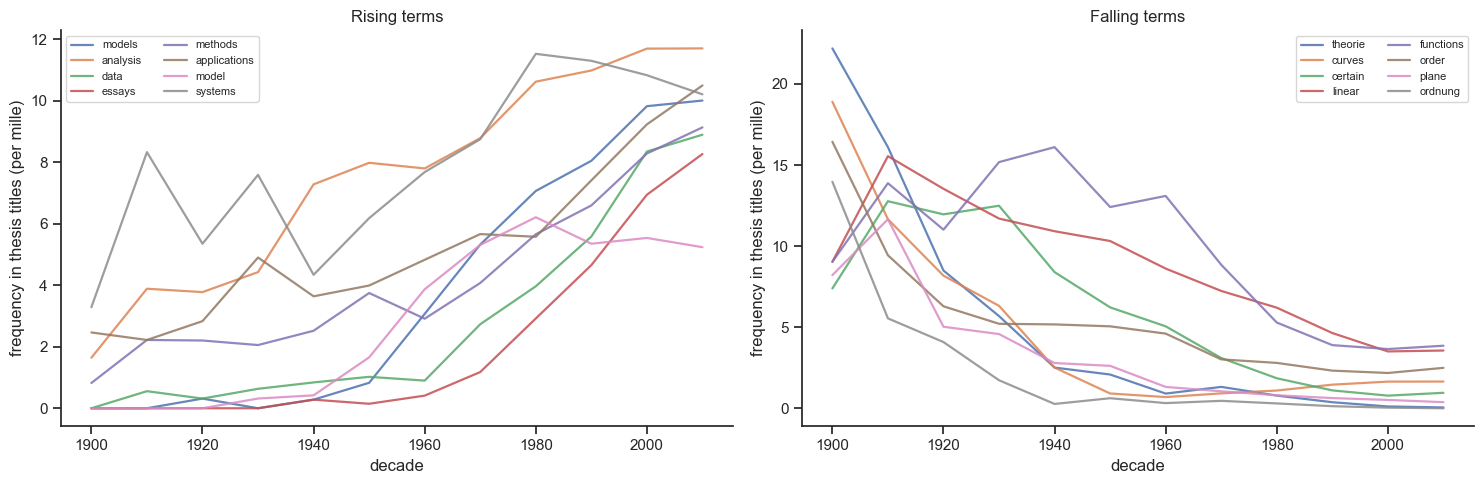

In [45]:
# Plot a few rising and falling words over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, words, title in [
    (axes[0], list(rising.head(8).index), "Rising terms"),
    (axes[1], list(falling.head(8).index), "Falling terms"),
]:
    for w in words:
        ax.plot(decade_x, freq_by_decade.loc[w].values * 1000,
                label=w, linewidth=1.6, alpha=0.85)
    ax.set_xlabel("decade")
    ax.set_ylabel("frequency in thesis titles (per mille)")
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 13. Historical ruptures

Do major political events show up in the data? Three case studies: WWI/WWII, the Nazi purge of 1933, and the post-Soviet brain drain.

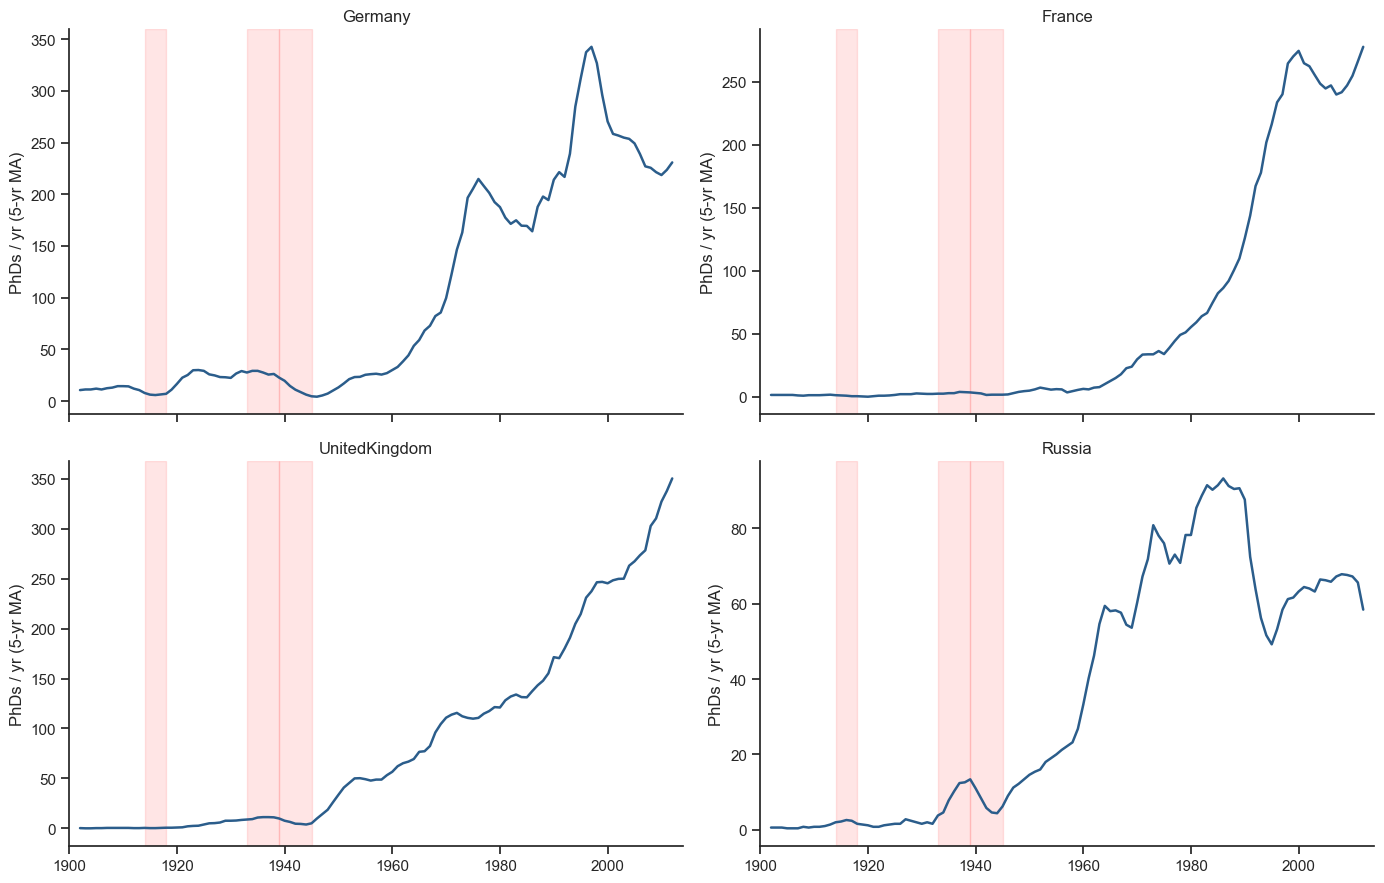

In [46]:
WAR_BANDS = [
    (1914, 1918, "WWI"),
    (1939, 1945, "WWII"),
    (1933, 1939, "Nazi purge"),
]

def country_series(c, y_min=1900, y_max=2014):
    s = df[(df["country"] == c) & df["year"].notna()].copy()
    s = s[(s["year"] >= y_min) & (s["year"] <= y_max)]
    return s["year"].astype(int).value_counts().sort_index().reindex(
        range(y_min, y_max + 1), fill_value=0
    )

countries = ["Germany", "France", "UnitedKingdom", "Russia"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, c in zip(axes.flat, countries):
    s = country_series(c).rolling(5, center=True).mean()
    ax.plot(s.index, s.values, linewidth=1.8, color="#2b5d8b")
    for start, end, label in [(1914, 1918, "WWI"), (1939, 1945, "WWII"),
                              (1933, 1939, "Nazi")]:
        ax.axvspan(start, end, color="red", alpha=0.10)
    ax.set_title(c)
    ax.set_ylabel("PhDs / yr (5-yr MA)")
    ax.set_xlim(1900, 2014)
plt.tight_layout()
plt.show()

### 13.1 The 1933 emigration wave: Germany → US flow by decade

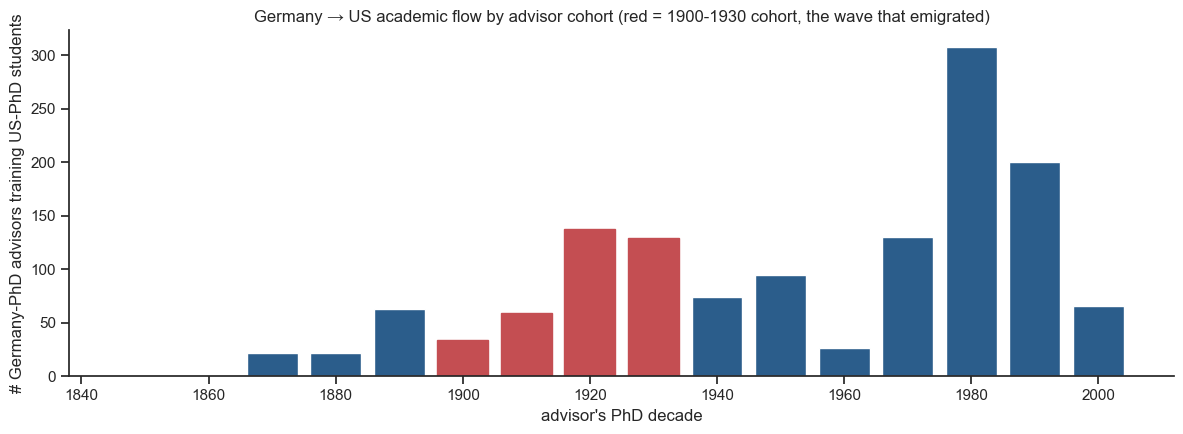

In [47]:
edges_full = pd.DataFrame(list(G.edges()), columns=["adv", "stu"])
edges_full["adv_c"] = edges_full["adv"].map(df["country"])
edges_full["stu_c"] = edges_full["stu"].map(df["country"])
edges_full["adv_y"] = edges_full["adv"].map(df["year"])
edges_full["stu_y"] = edges_full["stu"].map(df["year"])

g2us = edges_full[(edges_full["adv_c"] == "Germany") & (edges_full["stu_c"] == "UnitedStates")].copy()
g2us["adv_decade"] = (g2us["adv_y"] // 10) * 10
g2us = g2us.dropna(subset=["adv_decade"])
g2us["adv_decade"] = g2us["adv_decade"].astype(int)
trend = g2us.groupby("adv_decade").size()
trend = trend.reindex(range(1850, 2010, 10), fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
bars = ax.bar(trend.index, trend.values, width=8, color="#2b5d8b")
# Highlight 1900s-1930s bars
for i, d in enumerate(trend.index):
    if 1900 <= d <= 1930:
        bars[i].set_color("#c44e52")
ax.set_xlabel("advisor's PhD decade")
ax.set_ylabel("# Germany-PhD advisors training US-PhD students")
ax.set_title("Germany → US academic flow by advisor cohort (red = 1900-1930 cohort, the wave that emigrated)")
plt.tight_layout()
plt.show()

### 13.2 Russia → US after 1991

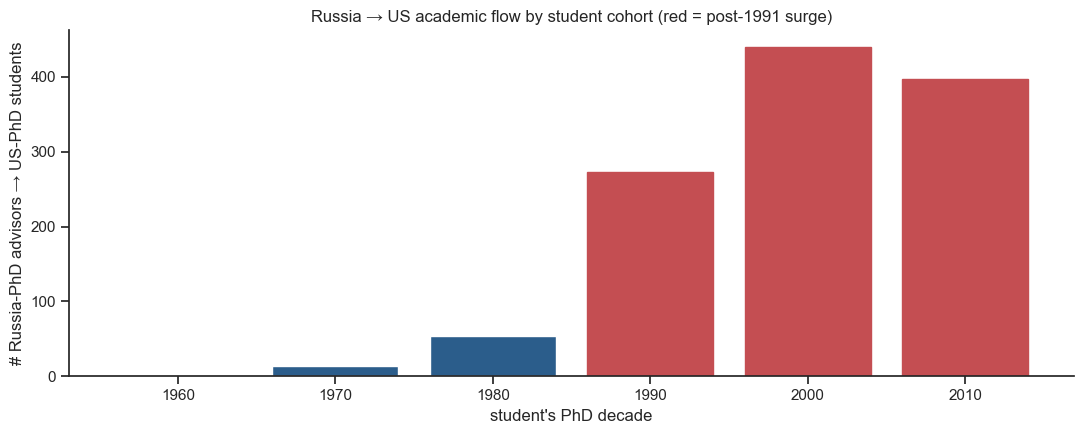

In [48]:
r2us = edges_full[(edges_full["adv_c"] == "Russia") & (edges_full["stu_c"] == "UnitedStates")].copy()
r2us["stu_decade"] = (r2us["stu_y"] // 10) * 10
r2us = r2us.dropna(subset=["stu_decade"])
trend_r = r2us.groupby("stu_decade").size().reindex(range(1960, 2020, 10), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(trend_r.index, trend_r.values, width=8, color="#2b5d8b")
# Post-Soviet highlight
for i, d in enumerate(trend_r.index):
    if d >= 1990:
        bars[i].set_color("#c44e52")
ax.set_xlabel("student's PhD decade")
ax.set_ylabel("# Russia-PhD advisors → US-PhD students")
ax.set_title("Russia → US academic flow by student cohort (red = post-1991 surge)")
plt.tight_layout()
plt.show()

## 14. Network — going deeper

### 14.1 Articulation points

In the giant WCC (treated as undirected), an **articulation point** is a node whose removal disconnects the graph. With a mostly-tree structure, many internal nodes qualify.

In [49]:
H_giant = G.to_undirected().subgraph(giant_wcc)
art = list(nx.articulation_points(H_giant))
print(f"# articulation points in giant WCC: {len(art):,} / {len(giant_wcc):,}")
print(f"  fraction:                          {len(art) / len(giant_wcc):.1%}")

# Rank articulation points by # descendants — those are the genealogy's "bottleneck patriarchs"
art_with_desc = pd.Series({a: len(desc_sets[a]) for a in art if a in desc_sets}).sort_values(ascending=False)
top_art = art_with_desc.head(20)
top_art_df = df.loc[top_art.index, ["name", "year", "country"]].copy()
top_art_df["descendants"] = top_art.values
top_art_df.reset_index(drop=True)

# articulation points in giant WCC: 44,774 / 239,464
  fraction:                          18.7%


,name,year,country,descendants
0,Kamāl al-Dīn Ibn Yūnus,NaN,NaN,171042
1,Nasir al-Dīn al-Ṭūsī,NaN,NaN,171041
2,Shams al‐Dīn al‐Bukhārī,NaN,Iran,171040
3,Gregory Chioniadis,NaN,Iran,171039
4,Manuel Bryennios,NaN,NaN,171038
5,Theodore Metochites,NaN,NaN,171037
6,Gregory Palamas,NaN,NaN,171035
7,Nilos Kabasilas,NaN,NaN,171034
8,Demetrios Kydones,NaN,NaN,171033
9,Georgios Plethon Gemistos,NaN,NaN,171009


### 14.2 Preferential attachment?

Does the network grow via preferential attachment — new students choosing advisors with probability proportional to their existing fertility — as the Barabási–Albert model predicts? Bin advisors by their out-degree at "snapshot time" T₀, then for new edges added in time (T₀, T₀+Δ], measure the fraction going to each bin.

/var/folders/cw/73nz0s3x6zx6nhpkxm7scs080000gn/T/ipykernel_39438/4070045123.py:39: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/fabianrigterink/Desktop/Code/math-genealogy-scraper/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


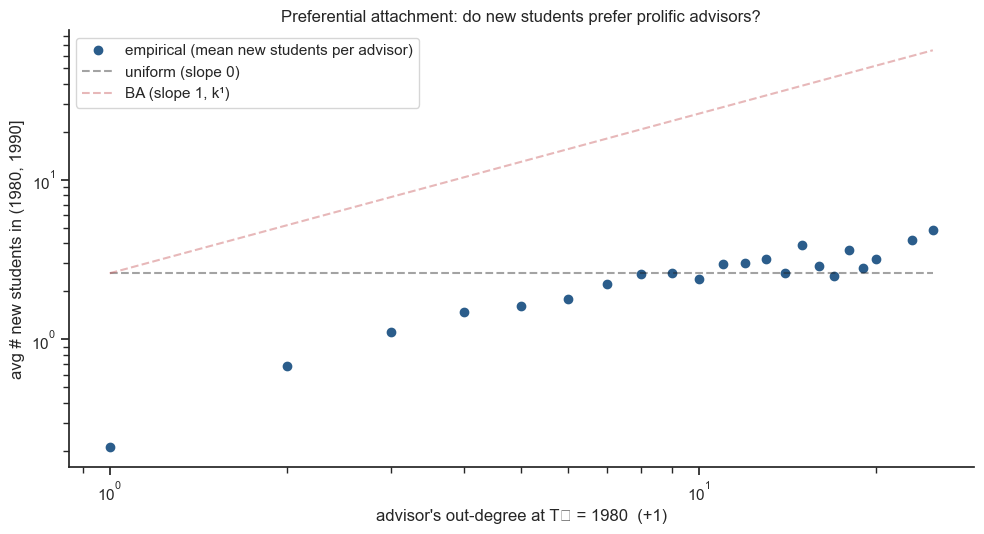

empirical attachment exponent: slope = 0.63
(slope ≈ 0 → uniform, slope ≈ 1 → Barabási–Albert)


In [50]:
# Build a year for each edge: use student's year as the edge's timestamp.
edges_full["edge_year"] = edges_full["stu_y"]

T0 = 1980
window = 10
# For each candidate advisor (must exist by T0), out-degree at T0:
adv_existed = df[df["year"].notna() & (df["year"] <= T0)].index
out_at_T0 = pd.Series(0, index=adv_existed, dtype=int)
edges_before = edges_full[edges_full["edge_year"] <= T0]
out_at_T0_actual = edges_before["adv"].value_counts()
out_at_T0.update(out_at_T0_actual)
out_at_T0 = out_at_T0.reindex(adv_existed, fill_value=0)

# New edges in (T0, T0+window]
new_edges = edges_full[(edges_full["edge_year"] > T0) &
                        (edges_full["edge_year"] <= T0 + window) &
                        edges_full["adv"].isin(adv_existed)]
new_counts = new_edges["adv"].value_counts().reindex(adv_existed, fill_value=0)

# Group by out-degree at T0, sum new attachments
df_pa = pd.DataFrame({"k": out_at_T0, "new": new_counts})
agg = df_pa.groupby("k").agg(n_advisors=("new", "size"), new_attach=("new", "sum"))
agg["expected_uniform"] = agg["n_advisors"] / agg["n_advisors"].sum() * agg["new_attach"].sum()
agg["attach_per_advisor"] = agg["new_attach"] / agg["n_advisors"]
agg = agg[agg["n_advisors"] >= 20]  # noise-floor

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.loglog(agg.index + 1, agg["attach_per_advisor"], "o", markersize=6, color="#2b5d8b",
          label="empirical (mean new students per advisor)")
# Reference: ~k^1 (BA) and ~k^0 (uniform)
k_ref = np.linspace(1, agg.index.max() + 1, 50)
ref_const = agg["attach_per_advisor"].median()
ax.loglog(k_ref, ref_const * np.ones_like(k_ref), "k--", alpha=0.4, label="uniform (slope 0)")
ax.loglog(k_ref, ref_const * (k_ref / k_ref[0]), "r--", alpha=0.4, label="BA (slope 1, k¹)")
ax.set_xlabel("advisor's out-degree at T₀ = 1980  (+1)")
ax.set_ylabel(f"avg # new students in ({T0}, {T0+window}]")
ax.set_title("Preferential attachment: do new students prefer prolific advisors?")
ax.legend()
plt.tight_layout()
plt.show()

# Fit a power law to the relationship
mask = (agg.index >= 1) & (agg.index <= 50)
log_k = np.log(agg.index[mask] + 1).values.astype(float)
log_y = np.log(agg["attach_per_advisor"][mask]).values.astype(float)
slope, intercept = np.polyfit(log_k, log_y, 1)
print(f"empirical attachment exponent: slope = {slope:.2f}")
print("(slope ≈ 0 → uniform, slope ≈ 1 → Barabási–Albert)")

### 14.3 Time-sliced snapshots

How did the network's macroscopic shape evolve? Build the graph as of year T (including only nodes with PhD year ≤ T, plus their inferred-earlier ancestors via propagation).

In [51]:
# Impute years for nodes without one: take min(successors.year) - 25 as a rough birth.
imputed_year = df["year"].copy()
remaining = set(df[df["year"].isna()].index)
for _ in range(5):  # iterate to propagate
    changed = 0
    for nid in list(remaining):
        succ_years = [imputed_year.get(s) for s in G.successors(nid)]
        succ_years = [y for y in succ_years if pd.notna(y)]
        if succ_years:
            imputed_year[nid] = min(succ_years) - 25
            remaining.discard(nid)
            changed += 1
    if not changed:
        break
# Backstop: anyone still NaN gets year = 1700 (mostly pre-modern, medieval)
imputed_year = imputed_year.fillna(1700)

rows = []
for T in (1700, 1800, 1850, 1900, 1950, 2000, 2014):
    keep = df.index[imputed_year <= T]
    GT = G.subgraph(keep)
    wccs = list(nx.weakly_connected_components(GT))
    giant = max(wccs, key=len) if wccs else set()
    rows.append({
        "T": T,
        "n_nodes": GT.number_of_nodes(),
        "n_edges": GT.number_of_edges(),
        "giant_size": len(giant),
        "giant_pct": len(giant) / max(GT.number_of_nodes(), 1),
        "n_components": len(wccs),
    })
snapshots = pd.DataFrame(rows)
snapshots

,T,n_nodes,n_edges,giant_size,giant_pct,n_components
0,1700,32236,6935,604,0.018737,25506
1,1800,32429,7265,888,0.027383,25426
2,1850,32686,8011,1834,0.056110,25102
3,1900,34003,10519,4042,0.118872,24414
4,1950,43510,22618,15419,0.354378,23223
5,2000,165094,162108,136680,0.827892,18617
6,2014,238151,252933,213141,0.894983,14776


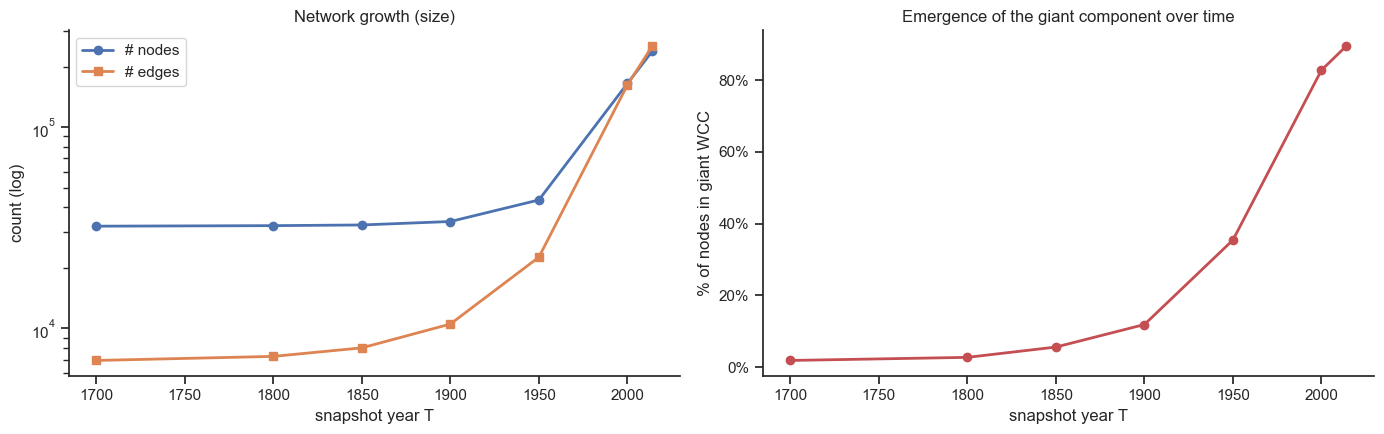

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(snapshots["T"], snapshots["n_nodes"], "o-", label="# nodes", linewidth=2)
axes[0].plot(snapshots["T"], snapshots["n_edges"], "s-", label="# edges", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("snapshot year T")
axes[0].set_ylabel("count (log)")
axes[0].set_title("Network growth (size)")
axes[0].legend()

axes[1].plot(snapshots["T"], snapshots["giant_pct"] * 100, "o-", linewidth=2, color="#c44e52")
axes[1].set_xlabel("snapshot year T")
axes[1].set_ylabel("% of nodes in giant WCC")
axes[1].set_title("Emergence of the giant component over time")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

### 14.4 Lineage survival

A lineage "survives" through a generation if it produces at least one student. Estimate the per-generation survival probability and the implied distribution of branch extinction times.

Cohort 1900-1950: 6,767 mathematicians
  branch depth = 0 (no students):     4,076  (60.2%)
  branch depth ≥ 1 (any students):    2,691  (39.8%)
  branch depth ≥ 3:                   1,858  (27.5%)
  branch depth ≥ 5:                   1,092  (16.1%)


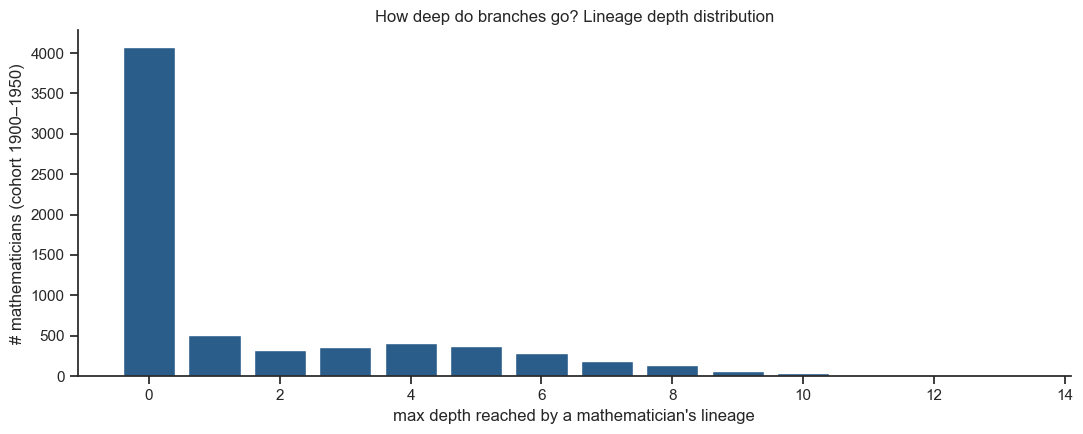

In [53]:
# For each node in the giant WCC with year >= 1900 (so coverage is decent), trace its
# branch downward and record the maximum depth reached.
branch_depths = pd.Series({v: 0 for v in G.nodes()}, dtype=int)
for v in reversed(topo):
    children_depths = [branch_depths[c] for c in G.successors(v)]
    if children_depths:
        branch_depths[v] = 1 + max(children_depths)

# Looking at people who got their PhD around 1900-1950 — they have had enough time
# for their branch to play out — what's the survival distribution?
cohort = df[df["year"].between(1900, 1950)].index
depths = branch_depths.loc[cohort]
print(f"Cohort 1900-1950: {len(cohort):,} mathematicians")
print(f"  branch depth = 0 (no students):     {(depths == 0).sum():,}  ({(depths == 0).mean():.1%})")
print(f"  branch depth ≥ 1 (any students):    {(depths >= 1).sum():,}  ({(depths >= 1).mean():.1%})")
print(f"  branch depth ≥ 3:                   {(depths >= 3).sum():,}  ({(depths >= 3).mean():.1%})")
print(f"  branch depth ≥ 5:                   {(depths >= 5).sum():,}  ({(depths >= 5).mean():.1%})")

fig, ax = plt.subplots(figsize=(11, 4.5))
counts = depths.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#2b5d8b")
ax.set_xlabel("max depth reached by a mathematician's lineage")
ax.set_ylabel("# mathematicians (cohort 1900–1950)")
ax.set_title("How deep do branches go? Lineage depth distribution")
plt.tight_layout()
plt.show()

## 15. Sociology

### 15.1 School "PhD endogamy"

For each school, what fraction of its PhDs were advised by someone who also got their PhD at that school? A high ratio = "the school trains its own future faculty / mentors."

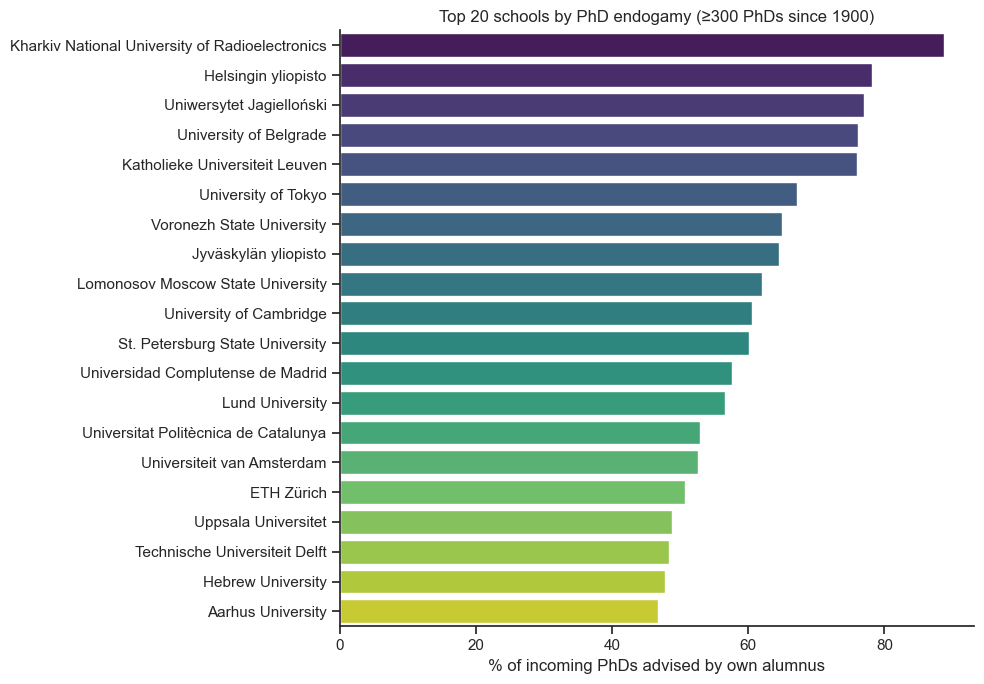

,total,same,endogamy
stu_school,,,
Kharkiv National University of Radioelectronics,408,362,0.887255
Helsingin yliopisto,326,255,0.782209
Uniwersytet Jagielloński,427,329,0.770492
University of Belgrade,462,352,0.761905
Katholieke Universiteit Leuven,781,593,0.759283
University of Tokyo,305,205,0.672131
Voronezh State University,416,270,0.649038
Jyväskylän yliopisto,346,223,0.644509
Lomonosov Moscow State University,1511,937,0.620119


In [54]:
edges_full["adv_school"] = edges_full["adv"].map(df["school"])
edges_full["stu_school"] = edges_full["stu"].map(df["school"])
es = edges_full.dropna(subset=["adv_school", "stu_school"])
es = es[(es["adv_y"] >= 1900) | (es["stu_y"] >= 1900)]

es["same_school"] = es["adv_school"] == es["stu_school"]
per_school = es.groupby("stu_school").agg(
    total=("same_school", "size"),
    same=("same_school", "sum"),
)
per_school["endogamy"] = per_school["same"] / per_school["total"]
per_school = per_school[per_school["total"] >= 300]
top = per_school.sort_values("endogamy", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top["endogamy"] * 100, y=top.index,
            hue=top.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("% of incoming PhDs advised by own alumnus")
ax.set_ylabel("")
ax.set_title("Top 20 schools by PhD endogamy (≥300 PhDs since 1900)")
plt.tight_layout()
plt.show()
top

### 15.2 Academic dynasties at three landmark schools

Internal subgraphs: edges where *both* endpoints got their PhDs at the same school.

In [55]:
for sch in ["Georg-August-Universität Göttingen", "Princeton University",
            "Massachusetts Institute of Technology"]:
    internal_edges = es[(es["adv_school"] == sch) & (es["stu_school"] == sch)]
    print(f"\n{sch}:")
    print(f"  internal edges: {len(internal_edges):,}")
    # Top 5 advisors by # students they trained at the same school
    if len(internal_edges):
        top5 = internal_edges["adv"].value_counts().head(5)
        for nid, n in top5.items():
            print(f"    {G.nodes[nid].get('name'):<40}  trained {n} same-school PhDs")


Georg-August-Universität Göttingen:
  internal edges: 30
    Richard Courant                           trained 8 same-school PhDs
    Axel Munk                                 trained 6 same-school PhDs
    Horst S. Holdgrün                         trained 5 same-school PhDs
    Ulrich Stuhler                            trained 3 same-school PhDs
    Gestur Olafsson                           trained 2 same-school PhDs

Princeton University:
  internal edges: 657
    John Wilder Tukey                         trained 56 same-school PhDs
    Alonzo Church                             trained 30 same-school PhDs
    William Browder                           trained 30 same-school PhDs
    Robert Clifford Gunning                   trained 28 same-school PhDs
    Arthur Strong Wightman                    trained 26 same-school PhDs

Massachusetts Institute of Technology:
  internal edges: 1,684
    Olivier Jean Blanchard                    trained 74 same-school PhDs
    Dimitris John Bertsi

### 15.3 Sibling subject homophily

For all pairs of students sharing an advisor, how often do they share an MSC code?

In [56]:
import itertools
same_adv_same_msc = 0
same_adv_total = 0
for v in G.nodes():
    students = list(G.successors(v))
    if len(students) < 2: continue
    students_with_msc = [s for s in students if pd.notna(df.at[s, "msc"])]
    for a, b in itertools.combinations(students_with_msc, 2):
        same_adv_total += 1
        if df.at[a, "msc"] == df.at[b, "msc"]:
            same_adv_same_msc += 1
sibling_p = same_adv_same_msc / same_adv_total if same_adv_total else float("nan")
random_p = (df["msc"].value_counts(normalize=True) ** 2).sum()

print(f"sibling pairs (both MSCs known):                  {same_adv_total:,}")
print(f"P(siblings share MSC):                            {sibling_p:.1%}")
print(f"random baseline:                                  {random_p:.1%}")
print(f"sibling homophily / random:                       {sibling_p / random_p:.1f}x")
print(f"\nReference: advisor → student MSC match was        ~70% (11.7× random)")
print(f"If siblings inherited *independently* from advisor: ~{0.7**2:.0%} match expected.")
print(f"Observed sibling match ({sibling_p:.0%}) is HIGHER than {0.7**2:.0%} —")
print("siblings are more correlated than independent inheritance would predict.")
print("Reading: an advisor's research focus is sticky across the whole cohort, not just")
print("transmitted edge-by-edge — when students deviate, they tend to deviate together.")

sibling pairs (both MSCs known):                  877,223
P(siblings share MSC):                            73.3%
random baseline:                                  6.0%
sibling homophily / random:                       12.3x

Reference: advisor → student MSC match was        ~70% (11.7× random)
If siblings inherited *independently* from advisor: ~49% match expected.
Observed sibling match (73%) is HIGHER than 49% —
siblings are more correlated than independent inheritance would predict.
Reading: an advisor's research focus is sticky across the whole cohort, not just
transmitted edge-by-edge — when students deviate, they tend to deviate together.


## 16. Speculative fun

### 16.1 Recent patriarchs

For each modern mathematician (PhD 2000–2014), find their *most recent* common ancestor — the deepest-in-the-tree node such that everyone in this cohort shares it. Then ask: which mid-period advisors are the recent patriarchs of the largest cohorts?

In [57]:
# For each mathematician with year >= 1900, find the most-recent named ancestor with
# year < 1900 (any "pre-modern" patriarch).
# Approach: BFS upward from each modern person, take the closest ancestor with year<1900.

modern = df[df["year"].between(2000, 2014)].index.tolist()
print(f"modern cohort (2000–2014): {len(modern):,} mathematicians")

# For each modern node, walk up to the closest ancestor with year < 1900.
ancestor_counts = Counter()
for nid in modern:
    visited = {nid}
    frontier = {nid}
    found = None
    for hop in range(60):
        nxt = set()
        for v in frontier:
            for p in G.predecessors(v):
                if p in visited: continue
                visited.add(p)
                nxt.add(p)
                y = df.at[p, "year"] if p in df.index else None
                if pd.notna(y) and y < 1900:
                    if found is None:
                        found = p
        if found is not None:
            break
        frontier = nxt
        if not frontier:
            break
    if found is not None:
        ancestor_counts[found] += 1

top_patriarch = pd.Series(ancestor_counts).sort_values(ascending=False).head(15)
patriarch_df = df.loc[top_patriarch.index, ["name", "year", "country"]].copy()
patriarch_df["modern_descendants"] = top_patriarch.values
patriarch_df.reset_index(drop=True)

modern cohort (2000–2014): 77,956 mathematicians


,name,year,country,modern_descendants
0,David Hilbert,1885.0,Germany,7193
1,E. H. (Eliakim Hastings) Moore,1885.0,UnitedStates,6519
2,Arnold Johannes Wilhelm Sommerfeld,1891.0,Germany,3496
3,Ernst Eduard Kummer,1831.0,Germany,3146
4,William Edward Story,1875.0,Germany,3113
5,Andrew Russell Forsyth,1881.0,UnitedKingdom,2502
6,Émile Borel,1893.0,France,2387
7,Hermann Amandus Schwarz,1864.0,Germany,2328
8,Georgy Fedoseevich Voronoy,1896.0,Russia,2108
9,Julius Plücker,1823.0,Germany,2015


### 16.2 The Hilbert number

Erdős numbers are computed on the co-authorship graph; the analogous "Hilbert number" is the undirected shortest-path distance from David Hilbert in the genealogy.

reachable from Hilbert: 239,464 / 262,967  (91.1%)
mean Hilbert number:    7.89
median Hilbert number:  8


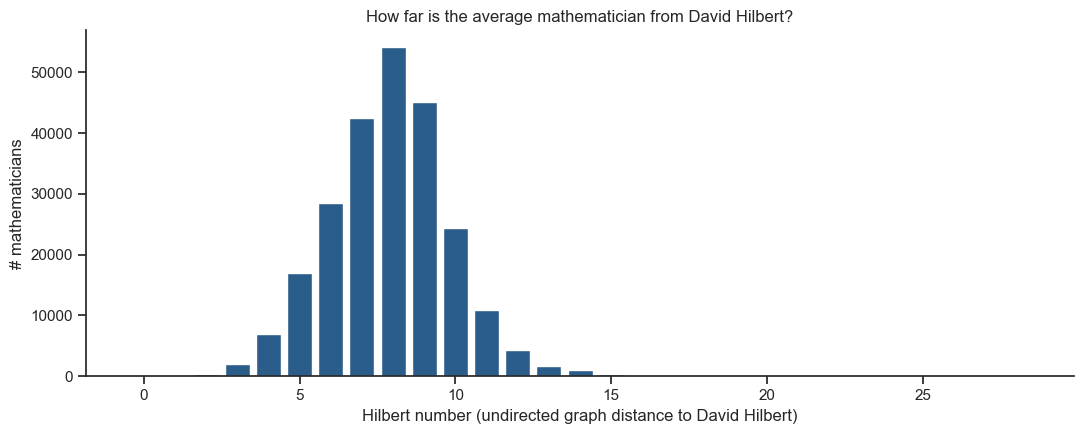

In [58]:
hilbert_id = df[df["name"].fillna("") == "David Hilbert"].index[0]
H_undirected = G.to_undirected()
dist_to_hilbert = nx.single_source_shortest_path_length(H_undirected, hilbert_id)
dh = pd.Series(dist_to_hilbert)

print(f"reachable from Hilbert: {len(dh):,} / {G.number_of_nodes():,}  ({len(dh)/G.number_of_nodes():.1%})")
print(f"mean Hilbert number:    {dh.mean():.2f}")
print(f"median Hilbert number:  {dh.median():.0f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
counts = dh.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#2b5d8b")
ax.set_xlabel("Hilbert number (undirected graph distance to David Hilbert)")
ax.set_ylabel("# mathematicians")
ax.set_title("How far is the average mathematician from David Hilbert?")
plt.tight_layout()
plt.show()

## 17. Prize laureates in the genealogy

Match Fields Medalists and Abel laureates to MGP records (by case- and accent-insensitive last+first matching), then compare their structural position to peers.

In [59]:
import unicodedata

def normalize(s):
    if not isinstance(s, str): return ""
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s.lower()

df["name_norm"] = df["name"].fillna("").map(normalize)

def lookup_id(name):
    n_norm = normalize(name)
    parts = n_norm.split()
    if len(parts) < 2: return None
    last = parts[-1]
    first = parts[0]
    # Last name must appear as a whole word, not as a substring.
    last_re = rf"\b{re.escape(last)}\b"
    cands = df[df["name_norm"].str.contains(last_re, regex=True) &
               df["name_norm"].str.contains(first, regex=False)]
    if len(cands) == 0:
        return None
    # Prefer closest-name-length match.
    cands = cands.assign(d=cands["name_norm"].str.len().sub(len(n_norm)).abs())
    return cands.sort_values("d").index[0]

FIELDS_MEDALISTS = [
    "Lars Ahlfors","Jesse Douglas","Laurent Schwartz","Atle Selberg",
    "Kunihiko Kodaira","Jean-Pierre Serre","Klaus Roth","René Thom",
    "Lars Hörmander","John Milnor","Michael Atiyah","Paul Cohen",
    "Alexander Grothendieck","Stephen Smale","Alan Baker","Heisuke Hironaka",
    "Sergei Novikov","John G. Thompson","Enrico Bombieri","David Mumford",
    "Pierre Deligne","Charles Fefferman","Grigory Margulis","Daniel Quillen",
    "Alain Connes","William Thurston","Shing-Tung Yau","Simon Donaldson",
    "Gerd Faltings","Michael Freedman","Vladimir Drinfeld","Vaughan Jones",
    "Shigefumi Mori","Edward Witten","Jean Bourgain","Pierre-Louis Lions",
    "Jean-Christophe Yoccoz","Efim Zelmanov","Richard Borcherds",
    "Timothy Gowers","Maxim Kontsevich","Curtis McMullen","Laurent Lafforgue",
    "Vladimir Voevodsky","Andrei Okounkov","Grigori Perelman","Terence Tao",
    "Wendelin Werner","Elon Lindenstrauss","Stanislav Smirnov",
    "Cédric Villani","Artur Avila","Manjul Bhargava","Martin Hairer",
    "Maryam Mirzakhani","Caucher Birkar","Alessio Figalli","Peter Scholze",
    "Akshay Venkatesh",
]
ABEL_LAUREATES = [
    "Jean-Pierre Serre","Michael Atiyah","Isadore Singer","Peter Lax",
    "Lennart Carleson","S. R. Srinivasa Varadhan","John Griggs Thompson",
    "Jacques Tits","Mikhail Gromov","John Tate","John Milnor",
    "Endre Szemerédi","Pierre Deligne","Yakov Sinai","John F. Nash",
    "Louis Nirenberg","Andrew Wiles","Yves Meyer","Robert Langlands",
    "Karen Uhlenbeck",
]

fields_ids = {n: lookup_id(n) for n in FIELDS_MEDALISTS}
abel_ids   = {n: lookup_id(n) for n in ABEL_LAUREATES}
n_fields_matched = sum(1 for v in fields_ids.values() if v is not None)
n_abel_matched   = sum(1 for v in abel_ids.values()   if v is not None)
print(f"Fields medalists matched: {n_fields_matched}/{len(FIELDS_MEDALISTS)}")
print(f"Abel laureates matched:    {n_abel_matched}/{len(ABEL_LAUREATES)}")

laureate_ids = set([v for v in fields_ids.values() if v is not None] +
                   [v for v in abel_ids.values() if v is not None])
print(f"distinct laureate node IDs: {len(laureate_ids)}")

Fields medalists matched: 57/59
Abel laureates matched:    19/20
distinct laureate node IDs: 72


### 17.1 Are laureates structurally distinctive?

Compare laureates to a matched cohort (same PhD year ±5, same country) on three metrics: out-degree (fertility), descendants (lineage size), Hilbert number (centrality).

Median value comparison (laureates vs. matched controls):
  out-degree    laureates=11.0  controls=3.0
  descendants   laureates=44  controls=5
  Hilbert no.   laureates=7.0  controls=7.0


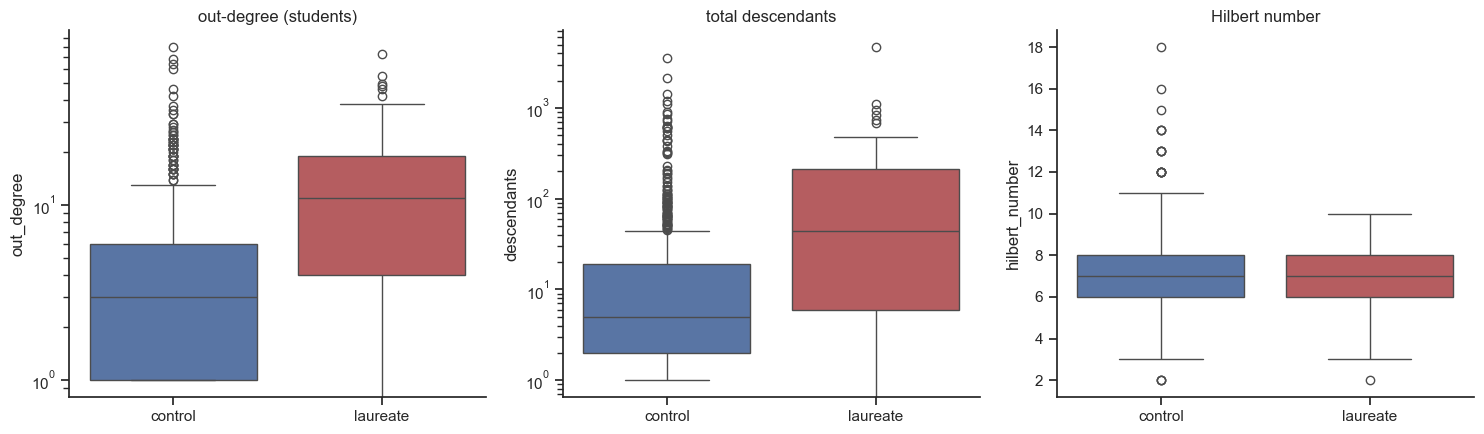

In [60]:
metrics = pd.DataFrame({
    "out_degree": pd.Series({n: G.out_degree(n) for n in G.nodes()}),
    "descendants": desc_count,
})

# Hilbert number
hilbert_id = df[df["name_norm"].str.contains("david hilbert")].index[0]
hd = pd.Series(nx.single_source_shortest_path_length(G.to_undirected(), hilbert_id))
metrics["hilbert_number"] = hd
metrics = metrics.join(df[["name", "year", "country"]])

laureate_metrics = metrics.loc[list(laureate_ids)].dropna(subset=["year"]).copy()
laureate_metrics["is_laureate"] = True

# Matched cohort: same country, year within ±5, AND at least 1 student
# (so we compare laureates to "real advisors", not random PhDs).
matched_idx = set()
RNG_LAU = np.random.default_rng(0)
for nid, row in laureate_metrics.iterrows():
    y, c = row["year"], row["country"]
    pool = metrics[
        (metrics["year"].between(y - 5, y + 5)) &
        (metrics["country"] == c) &
        (metrics["out_degree"] >= 1) &
        (~metrics.index.isin(laureate_metrics.index))
    ]
    if len(pool) > 0:
        sample = pool.sample(min(10, len(pool)), random_state=RNG_LAU.integers(1e6))
        matched_idx.update(sample.index)

control = metrics.loc[list(matched_idx)].copy()
control["is_laureate"] = False

print("Median value comparison (laureates vs. matched controls):")
print(f"  out-degree    laureates={laureate_metrics['out_degree'].median():.1f}  "
      f"controls={control['out_degree'].median():.1f}")
print(f"  descendants   laureates={laureate_metrics['descendants'].median():.0f}  "
      f"controls={control['descendants'].median():.0f}")
print(f"  Hilbert no.   laureates={laureate_metrics['hilbert_number'].median():.1f}  "
      f"controls={control['hilbert_number'].median():.1f}")

combined = pd.concat([laureate_metrics, control], axis=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, label in zip(axes,
        ["out_degree", "descendants", "hilbert_number"],
        ["out-degree (students)", "total descendants", "Hilbert number"]):
    sns.boxplot(data=combined, x="is_laureate", y=col, hue="is_laureate",
                legend=False, palette={False: "#4c72b0", True: "#c44e52"}, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["control", "laureate"])
    ax.set_yscale("log" if col in ("out_degree", "descendants") else "linear")
    ax.set_title(label)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 18. What predicts advisor fertility and lineage survival?

A simple multivariate model on cohort 1900–1980 (so most careers are visible). Predictors: PhD year, country, school, advisor's own out-degree, and (for survival) the advisor's own fertility.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

cohort = df[df["year"].between(1900, 1980)].copy()
cohort["out_degree"]   = cohort.index.map(metrics["out_degree"])
cohort["has_students"] = (cohort["out_degree"] >= 1).astype(int)
cohort["depth_ge_3"]   = (cohort.index.map(branch_depths) >= 3).astype(int)

# Advisor's out-degree (parent's fertility). Use mean over parents if multiple.
parent_out = {}
for nid in cohort.index:
    preds = list(G.predecessors(nid))
    if preds:
        parent_out[nid] = np.mean([metrics["out_degree"].get(p, np.nan) for p in preds])
cohort["parent_out"] = cohort.index.map(parent_out)

# Top countries and schools as categorical predictors (one-hot)
TOP_COUNTRIES = cohort["country"].value_counts().head(10).index
TOP_SCHOOLS = cohort["school"].value_counts().head(15).index
for c in TOP_COUNTRIES:
    cohort[f"c_{c}"] = (cohort["country"] == c).astype(int)
for s in TOP_SCHOOLS:
    sname = re.sub(r"[^a-zA-Z0-9]", "_", s)[:20]
    cohort[f"s_{sname}"] = (cohort["school"] == s).astype(int)

features = ["year", "parent_out"] + [f"c_{c}" for c in TOP_COUNTRIES] + \
           [c for c in cohort.columns if c.startswith("s_")]

# Drop rows missing predictors
X_df = cohort[features].copy()
mask = X_df["parent_out"].notna()
X_df = X_df[mask]
y_fert = cohort.loc[X_df.index, "has_students"].values
y_surv = cohort.loc[X_df.index, "depth_ge_3"].values

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

print(f"training set: {len(X):,} mathematicians (cohort 1900-1980 with known parent)")
print()

training set: 43,599 mathematicians (cohort 1900-1980 with known parent)



In [62]:
def fit_and_report(X, y, X_df, name):
    model = LogisticRegression(max_iter=400, C=1.0)
    model.fit(X, y)
    score = model.score(X, y)
    print(f"--- predicting: {name} ---")
    print(f"  accuracy: {score:.3f}  (base rate: {y.mean():.3f})")
    coefs = pd.Series(model.coef_[0], index=X_df.columns)
    print(f"  top 8 positive coefficients (in z-units):")
    for k, v in coefs.sort_values(ascending=False).head(8).items():
        print(f"    {k:<30} {v:+.3f}")
    print(f"  top 5 negative coefficients:")
    for k, v in coefs.sort_values().head(5).items():
        print(f"    {k:<30} {v:+.3f}")
    print()
    return model, coefs

m1, c1 = fit_and_report(X, y_fert, X_df, "P(advised ≥1 student)")
m2, c2 = fit_and_report(X, y_surv, X_df, "P(lineage reaches depth ≥3)")

--- predicting: P(advised ≥1 student) ---
  accuracy: 0.662  (base rate: 0.381)
  top 8 positive coefficients (in z-units):
    s_Princeton_University         +0.221
    s_Harvard_University           +0.203
    s_Stanford_University          +0.144
    c_France                       +0.130
    s_The_University_of_Ch         +0.129
    s_Massachusetts_Instit         +0.102
    s_Cornell_University           +0.092
    s_University_of_Cambri         +0.078
  top 5 negative coefficients:
    c_UnitedStates                 -0.447
    parent_out                     -0.272
    c_Germany                      -0.169
    year                           -0.155
    c_Netherlands                  -0.155

--- predicting: P(lineage reaches depth ≥3) ---
  accuracy: 0.854  (base rate: 0.147)
  top 8 positive coefficients (in z-units):
    s_Princeton_University         +0.214
    s_Harvard_University           +0.196
    s_Stanford_University          +0.191
    c_France                       +0.140


### 18.1 Advisor → student fertility correlation (within-cohort)

Already known: global degree assortativity ≈ 0. But conditional on country and decade, does an advisor's fertility predict their student's?

In [63]:
edges_full["adv_out"] = edges_full["adv"].map(metrics["out_degree"])
edges_full["stu_out"] = edges_full["stu"].map(metrics["out_degree"])
edges_full["adv_decade"] = (edges_full["adv_y"] // 10) * 10

# Within cohort × country
within = edges_full.dropna(subset=["adv_out","stu_out","adv_decade","adv_c"])
within = within[within["adv_decade"].between(1900, 1980)]

# Compute correlation conditional on decade × country
def cond_corr(group):
    if len(group) < 100: return np.nan
    return group["adv_out"].corr(group["stu_out"])
cond = within.groupby(["adv_decade", "adv_c"]).apply(cond_corr, include_groups=False).dropna()
print(f"global correlation (adv out × stu out):           {within['adv_out'].corr(within['stu_out']):.3f}")
print(f"mean of decade × country conditional correlations: {cond.mean():.3f}")
print(f"median:                                           {cond.median():.3f}")

global correlation (adv out × stu out):           0.027
mean of decade × country conditional correlations: -0.010
median:                                           -0.013


## 19. Mesoscale structure

### 19.1 Louvain community detection

On the undirected giant WCC. Louvain finds communities by greedily maximising modularity.

In [64]:
H_giant = G.to_undirected().subgraph(giant_wcc)
print("running Louvain community detection (may take ~15s)...")
communities = nx.community.louvain_communities(H_giant, seed=0, resolution=1.0)
sizes = pd.Series([len(c) for c in communities])
print(f"  {len(communities)} communities found")
print(f"  size distribution:")
print(f"    max:     {sizes.max():,}")
print(f"    median:  {sizes.median():.0f}")
print(f"    p90:     {sizes.quantile(0.9):.0f}")
print(f"    p99:     {sizes.quantile(0.99):.0f}")

# Inspect the top-5 communities — what's their dominant country / subject / school?
node_to_community = {}
for i, c in enumerate(communities):
    for n in c:
        node_to_community[n] = i
df["community"] = df.index.map(node_to_community)

big5 = sizes.sort_values(ascending=False).head(5).index.tolist()
for ci in big5:
    members = df[df["community"] == ci]
    top_country = members["country"].value_counts().head(3)
    top_school = members["school"].value_counts().head(3)
    top_subject = members["subject_clean"].value_counts().head(3)
    print(f"\n  community {ci} (size {len(members):,}):")
    print(f"    top countries: {top_country.index.tolist()}")
    print(f"    top schools:   {top_school.index.tolist()}")
    print(f"    top subjects:  {top_subject.index.tolist()[:2]}")

running Louvain community detection (may take ~15s)...
  261 communities found
  size distribution:
    max:     10,106
    median:  663
    p90:     1645
    p99:     3937

  community 53 (size 10,106):
    top countries: ['UnitedStates', 'UnitedKingdom', 'Spain']
    top schools:   ['Massachusetts Institute of Technology', 'Stanford University', 'University of Minnesota-Minneapolis']
    top subjects:  ['Game theory, economics, social and behavioral sciences', 'Statistics']

  community 94 (size 4,549):
    top countries: ['Germany', 'UnitedStates', 'Austria']
    top schools:   ['Universität Berlin', 'Georg-August-Universität Göttingen', 'Masaryk University Brno']
    top subjects:  ['Astronomy and astrophysics', 'Geometry']

  community 101 (size 4,037):
    top countries: ['UnitedStates', 'Canada', 'UnitedKingdom']
    top schools:   ['North Carolina State University', 'Iowa State University', 'University of Minnesota-Minneapolis']
    top subjects:  ['Statistics', 'Probability th

### 19.2 k-core decomposition

The k-core is the maximal subgraph where every node has at least k connections. The deepest core is the densest "clique-like" cluster.

In [65]:
H_undir = G.to_undirected()
core_num = nx.core_number(H_undir)
core_series = pd.Series(core_num)
print(f"max core number: {core_series.max()}")
print(f"core size by k:")
for k in range(int(core_series.max()) + 1):
    print(f"  k={k}: {(core_series >= k).sum():,}")

# Who's in the deepest core?
max_k = int(core_series.max())
in_max_core = core_series[core_series == max_k].index
print(f"\nMembers of the deepest core (k={max_k}):")
for nid in list(in_max_core)[:15]:
    a = G.nodes[nid]
    print(f"  {a.get('name'):<40}  {a.get('year')}  {a.get('school')}")

max core number: 4
core size by k:
  k=0: 262,967
  k=1: 253,827
  k=2: 64,221
  k=3: 482
  k=4: 14

Members of the deepest core (k=4):
  Shintaro Nakao                            None  None
  Nikolay Kuznetsov                         2008  Jyväskylän yliopisto
  Timo Tiihonen                             1987  Jyväskylän yliopisto and Université de Nice-Sophia Antipolis
  Renat Yuldashev                           2013  Jyväskylän yliopisto
  Marat Yuldashev                           2013  St. Petersburg State University
  Alexander Zaretskiy                       2013  Jyväskylän yliopisto
  Elena Solovyeva                           2013  Jyväskylän yliopisto
  Masatoshi Fukushima                       None  None
  Masayoshi Takeda                          None  None
  Pekka Neittaanmäki                        1978  Jyväskylän yliopisto
  Gennadii Alekseevich Leonov               1971  St. Petersburg State University
  Nobuyuki Ikeda                            None  
  Takesi Watanabe 

### 19.3 Biconnected blocks

Maximal biconnected subgraphs of the giant WCC — clusters where any two nodes have at least two node-disjoint paths between them. With a tree-like structure, most blocks are trivial (just edges).

In [66]:
H_giant_undir = G.to_undirected().subgraph(giant_wcc)
blocks = list(nx.biconnected_components(H_giant_undir))
block_sizes = pd.Series([len(b) for b in blocks]).sort_values(ascending=False)
print(f"# biconnected blocks: {len(blocks):,}")
print(f"  size distribution:")
print(f"    max:     {block_sizes.max():,}")
print(f"    > 5:     {(block_sizes > 5).sum():,}")
print(f"    median:  {block_sizes.median():.0f} (most are trivial 2-node edges)")

# Look at non-trivial blocks
big_blocks = [b for b in blocks if len(b) >= 5]
print(f"\nLargest non-trivial blocks (≥5 nodes):")
for b in sorted(big_blocks, key=len, reverse=True)[:5]:
    members = df.loc[list(b)]
    names = members["name"].fillna("?").tolist()
    print(f"  size {len(b)}: {names[:5]}...")

# biconnected blocks: 177,916
  size distribution:
    max:     58,020
    > 5:     160
    median:  2 (most are trivial 2-node edges)

Largest non-trivial blocks (≥5 nodes):
  size 58020: ['Xu Yang', 'Ernest Willard Anderson', 'Yinghui Liu', 'Saeed Golnabi', 'Shenghe Zhan']...
  size 48: ['Deborah Lynn Kelley', 'Jennifer M. Bunner', 'Piper A. Farrell-Singleton', 'Roberta A. Foust', 'Juanita M. Lyons']...
  size 17: ['Hadar Benyamini', 'Inbal Halperin-Landsberg', 'Maxim Shatsky', 'Nurit Haspel', 'Yuval Inbar']...
  size 14: ['Andrew Bernard Whinston', 'Abdulnasser Minkara', 'Anita Lee-Post', 'Clyde W. Holsapple', 'Suranjan De']...
  size 12: ['Anthony Arie Jongejan', 'Dale Martin Bryson', 'Michael Neill', 'David Olson', 'Jamil Elias Effarah']...


## 20. Career trajectories

For each prolific advisor (≥3 students, all with known years), reconstruct their student-year sequence and ask: how long is a career? When does it peak? How bursty is the production?

advisors with ≥3 students and known PhD year (1850-1970 cohort): 6,203
  median age at first student:   10 years post-PhD
  median career length:          22 years
  90th percentile career length: 38


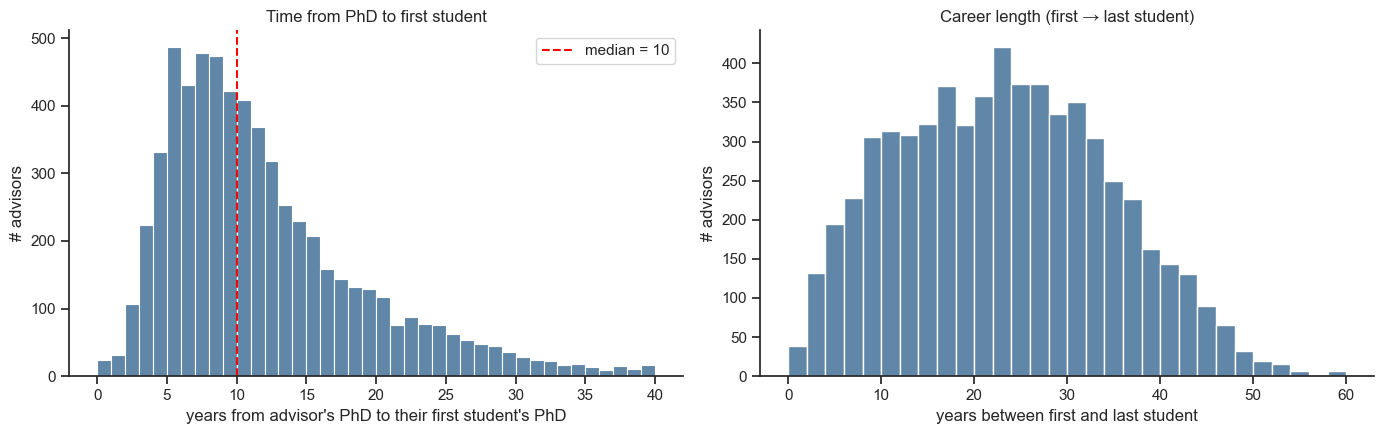

In [67]:
edges_y = pd.DataFrame(list(G.edges()), columns=["adv", "stu"])
edges_y["adv_y"] = edges_y["adv"].map(df["year"])
edges_y["stu_y"] = edges_y["stu"].map(df["year"])

# For each advisor with ≥3 students and known years
career = (edges_y.dropna(subset=["adv_y", "stu_y"])
          .groupby("adv")
          .agg(n_students=("stu_y", "size"),
               first_stu=("stu_y", "min"),
               last_stu=("stu_y", "max"),
               adv_y=("adv_y", "first")))
career = career[career["n_students"] >= 3]
career["age_at_first_stu"] = career["first_stu"] - career["adv_y"]
career["career_length"] = career["last_stu"] - career["first_stu"]

# Restrict to cohort with full careers visible
career_full = career[career["adv_y"].between(1850, 1970)]

print(f"advisors with ≥3 students and known PhD year (1850-1970 cohort): {len(career_full):,}")
print(f"  median age at first student:   {career_full['age_at_first_stu'].median():.0f} years post-PhD")
print(f"  median career length:          {career_full['career_length'].median():.0f} years")
print(f"  90th percentile career length: {career_full['career_length'].quantile(0.9):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(career_full["age_at_first_stu"].clip(0, 40),
             bins=range(0, 41), ax=axes[0], color="#2b5d8b")
axes[0].set_xlabel("years from advisor's PhD to their first student's PhD")
axes[0].set_ylabel("# advisors")
axes[0].set_title("Time from PhD to first student")
axes[0].axvline(career_full["age_at_first_stu"].median(), color="red", linestyle="--",
                label=f"median = {career_full['age_at_first_stu'].median():.0f}")
axes[0].legend()

sns.histplot(career_full["career_length"].clip(0, 60),
             bins=range(0, 61, 2), ax=axes[1], color="#2b5d8b")
axes[1].set_xlabel("years between first and last student")
axes[1].set_ylabel("# advisors")
axes[1].set_title("Career length (first → last student)")
plt.tight_layout()
plt.show()

### 20.1 Burstiness in student production

The Goh–Barabási burstiness coefficient B = (σ − μ) / (σ + μ) for inter-event times, where σ and μ are the std and mean of the gaps between consecutive students. B → −1 = perfectly regular; B = 0 = Poisson; B → 1 = very bursty.

advisors with ≥5 students (eligible): 15,109
mean burstiness B:    -0.068
median:               -0.057
  (B<0 = regular, B≈0 = Poisson, B>0 = bursty)


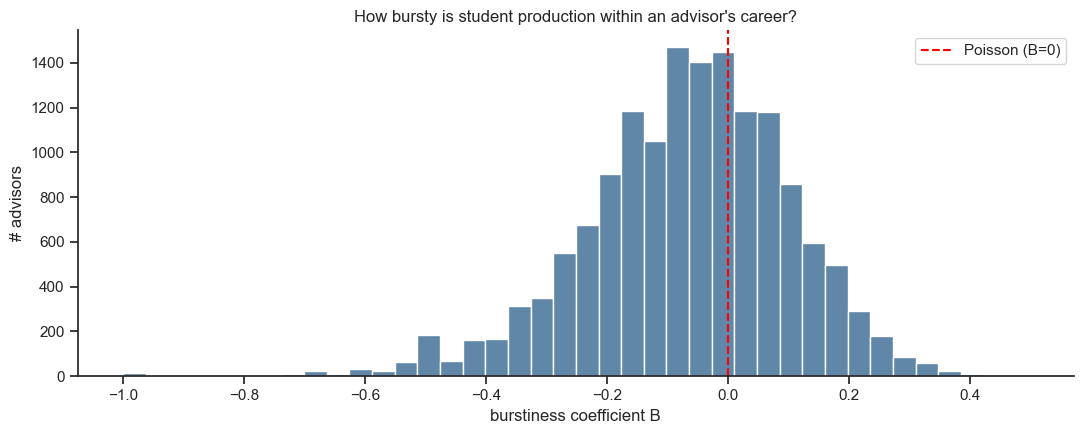

In [68]:
burst_vals = []
for adv, group in edges_y.dropna(subset=["stu_y"]).groupby("adv"):
    years = sorted(group["stu_y"].astype(int).tolist())
    if len(years) < 5: continue
    gaps = np.diff(years)
    if len(gaps) < 4: continue
    mu, sigma = gaps.mean(), gaps.std()
    if mu + sigma == 0: continue
    burst_vals.append((sigma - mu) / (sigma + mu))

burst = pd.Series(burst_vals)
print(f"advisors with ≥5 students (eligible): {len(burst):,}")
print(f"mean burstiness B:    {burst.mean():.3f}")
print(f"median:               {burst.median():.3f}")
print("  (B<0 = regular, B≈0 = Poisson, B>0 = bursty)")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(burst, bins=40, ax=ax, color="#2b5d8b")
ax.axvline(0, color="red", linestyle="--", label="Poisson (B=0)")
ax.set_xlabel("burstiness coefficient B")
ax.set_ylabel("# advisors")
ax.set_title("How bursty is student production within an advisor's career?")
ax.legend()
plt.tight_layout()
plt.show()

### 20.2 Generation length by country

Refines §5 by conditioning on country of the advisor.

In [69]:
edges_gap = edges_y.dropna(subset=["adv_y", "stu_y"]).copy()
edges_gap["gap"] = edges_gap["stu_y"] - edges_gap["adv_y"]
edges_gap["adv_c"] = edges_gap["adv"].map(df["country"])
top10c = df["country"].value_counts().head(10).index.tolist()
gap_by_country = (edges_gap[edges_gap["adv_c"].isin(top10c)]
                  .groupby("adv_c")["gap"]
                  .agg(["median", "mean", "count"]))
gap_by_country = gap_by_country.sort_values("median")
gap_by_country

,median,mean,count
adv_c,,,
Spain,15.0,16.464253,3231
Canada,17.0,18.805383,5313
France,17.0,18.579754,8871
Australia,18.0,19.654472,1968
UnitedStates,18.0,19.561491,116691
Netherlands,19.0,20.250245,8176
Switzerland,20.0,20.999347,3062
UnitedKingdom,20.0,20.703191,13352
Germany,21.0,21.685962,10486


## 21. Subject meta-network

A graph where nodes = MSC codes and edge weights = # advisor→student pairs across that subject pair. Reveals which subjects "feed" others.

In [70]:
edges_msc = edges_full.copy()
edges_msc["adv_msc"] = edges_msc["adv"].map(df["msc"])
edges_msc["stu_msc"] = edges_msc["stu"].map(df["msc"])
edges_msc = edges_msc.dropna(subset=["adv_msc", "stu_msc"])

# Pick top-20 subjects
top20_msc = df["msc"].value_counts().head(20).index.tolist()
edges_msc20 = edges_msc[edges_msc["adv_msc"].isin(top20_msc) &
                        edges_msc["stu_msc"].isin(top20_msc)]
msc_pairs = edges_msc20.groupby(["adv_msc", "stu_msc"]).size().reset_index(name="n")

# Build a directed subject graph (excluding self-loops to see inter-subject flows)
S = nx.DiGraph()
S.add_nodes_from(top20_msc)
for _, row in msc_pairs.iterrows():
    if row["adv_msc"] != row["stu_msc"]:
        S.add_edge(row["adv_msc"], row["stu_msc"], weight=int(row["n"]))

# Edges above a threshold for readability
strong_edges = [(u, v, d["weight"]) for u, v, d in S.edges(data=True) if d["weight"] >= 200]
strong_edges.sort(key=lambda e: -e[2])
print(f"strong subject→subject flows (≥200 edges):  {len(strong_edges)}")
print("Top 15 cross-subject flows:")
msc_label = df.dropna(subset=["msc"]).groupby("msc")["subject_clean"].first()
for u, v, w in strong_edges[:15]:
    lu = (msc_label.get(u) or u)[:30]
    lv = (msc_label.get(v) or v)[:30]
    print(f"  {lu:<32} -> {lv:<32} {w:>5}")

strong subject→subject flows (≥200 edges):  15
Top 15 cross-subject flows:
  Probability theory and stochas   -> Statistics                         721
  Statistics                       -> Game theory, economics, social     717
  Mathematical logic and foundat   -> Computer science                   710
  Game theory, economics, social   -> Statistics                         555
  Operations research, mathemati   -> Game theory, economics, social     545
  Information and communication,   -> Computer science                   484
  Systems theory; control          -> Computer science                   352
  Partial differential equations   -> Numerical analysis                 305
  Combinatorics                    -> Computer science                   273
  Computer science                 -> Information and communication,     261
  Numerical analysis               -> Computer science                   261
  Statistics                       -> Probability theory and stochas     259
 

### 21.1 Subject inheritance asymmetry

P(A→B) and P(B→A) for each pair. Asymmetry indicates directional flow: subject A often "feeds into" B but not vice versa.

In [71]:
# Normalize rows of the cross-subject matrix to conditional probabilities
M = msc_pairs.pivot(index="adv_msc", columns="stu_msc", values="n").fillna(0)
M = M.reindex(index=top20_msc, columns=top20_msc, fill_value=0)
P = M.div(M.sum(axis=1), axis=0)

# Asymmetry: A -> B but not B -> A
asym_pairs = []
for u in top20_msc:
    for v in top20_msc:
        if u == v: continue
        diff = P.loc[u, v] - P.loc[v, u]
        if diff > 0.01:  # u -> v dominates
            asym_pairs.append((u, v, P.loc[u, v], P.loc[v, u], diff))
asym_pairs.sort(key=lambda x: -x[4])
print("Top 12 asymmetric subject flows (advisor MSC → student MSC):")
print(f"{'from':<35} {'to':<35} {'P(to|from)':>10} {'P(from|to)':>10}")
for u, v, p_uv, p_vu, _ in asym_pairs[:12]:
    lu = (msc_label.get(u) or u)[:33]
    lv = (msc_label.get(v) or v)[:33]
    print(f"{lu:<35} {lv:<35} {p_uv:>10.2%} {p_vu:>10.2%}")

Top 12 asymmetric subject flows (advisor MSC → student MSC):
from                                to                                  P(to|from) P(from|to)
Mathematical logic and foundation   Computer science                        31.22%      0.94%
Information and communication, ci   Computer science                        19.65%      1.64%
Combinatorics                       Computer science                        15.61%      0.57%
Operations research, mathematical   Game theory, economics, social an       16.30%      1.37%
Probability theory and stochastic   Statistics                              17.09%      3.09%
Systems theory; control             Computer science                        12.85%      0.38%
Numerical analysis                  Computer science                         7.04%      0.51%
Partial differential equations      Numerical analysis                      11.34%      5.13%
Operations research, mathematical   Computer science                         6.88%      0.82%

### 21.2 Subject drift within Hilbert's lineage

How does the subject mix change as we go down generations of Hilbert's tree?

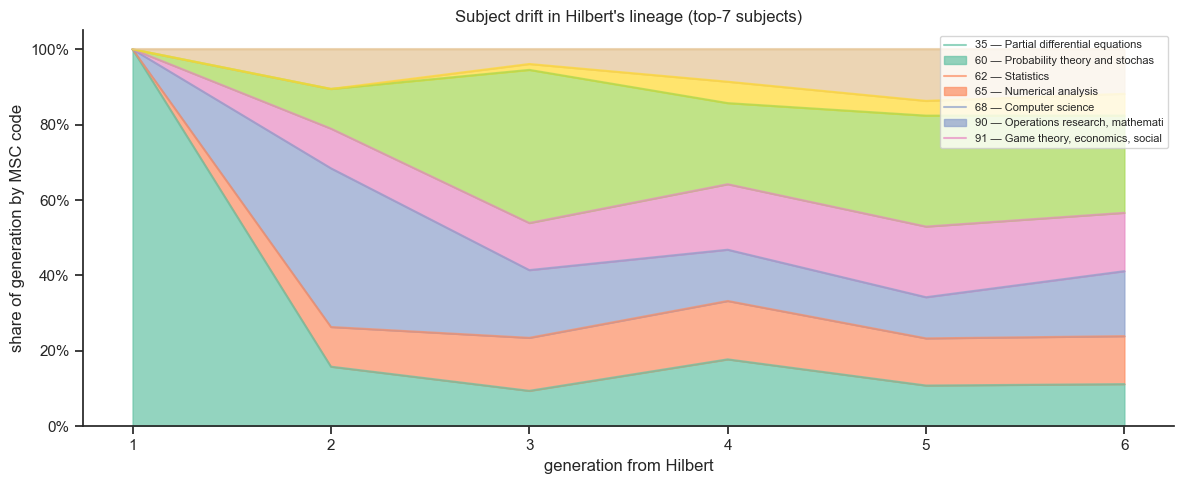

In [72]:
hilbert_id = df[df["name_norm"].str.contains("david hilbert")].index[0]
# BFS Hilbert's descendants, recording generation
gen = {hilbert_id: 0}
frontier = [hilbert_id]
for d in range(1, 7):
    nxt = []
    for v in frontier:
        for s in G.successors(v):
            if s not in gen:
                gen[s] = d
                nxt.append(s)
    frontier = nxt

hilbert_tree = pd.DataFrame({
    "gen": pd.Series(gen),
    "msc": df["msc"],
}).dropna(subset=["msc"])

# Top-7 subjects in Hilbert's tree
top_subj = hilbert_tree["msc"].value_counts().head(7).index.tolist()
subj_by_gen = (hilbert_tree[hilbert_tree["msc"].isin(top_subj)]
               .groupby(["gen", "msc"]).size().unstack(fill_value=0))
subj_by_gen_pct = subj_by_gen.div(subj_by_gen.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
subj_by_gen_pct.plot.area(ax=ax, alpha=0.7,
                          color=sns.color_palette("Set2", len(top_subj)))
ax.set_xlabel("generation from Hilbert")
ax.set_ylabel("share of generation by MSC code")
ax.set_title("Subject drift in Hilbert's lineage (top-7 subjects)")
legend_labels = [f"{m} — {(msc_label.get(m) or '')[:30]}" for m in subj_by_gen_pct.columns]
ax.legend(legend_labels, loc="upper right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0, xmax=1))
plt.tight_layout()
plt.show()

## 22. Geographic deeper

### 22.1 City-level rankings

Map school names to cities via a small hand-built dictionary covering the top-30 schools by PhD count.

In [73]:
SCHOOL_TO_CITY = {
    "Massachusetts Institute of Technology": "Cambridge MA, US",
    "Harvard University": "Cambridge MA, US",
    "Princeton University": "Princeton, US",
    "Stanford University": "Stanford, US",
    "University of California, Berkeley": "Berkeley, US",
    "Columbia University": "New York, US",
    "Yale University": "New Haven, US",
    "Cornell University": "Ithaca, US",
    "University of Chicago": "Chicago, US",
    "California Institute of Technology": "Pasadena, US",
    "University of Michigan": "Ann Arbor, US",
    "University of Wisconsin-Madison": "Madison, US",
    "University of Illinois at Urbana-Champaign": "Urbana-Champaign, US",
    "University of Texas at Austin": "Austin, US",
    "University of Cambridge": "Cambridge, UK",
    "University of Oxford": "Oxford, UK",
    "Imperial College London": "London, UK",
    "University College London": "London, UK",
    "Georg-August-Universität Göttingen": "Göttingen, DE",
    "Humboldt-Universität zu Berlin": "Berlin, DE",
    "Universität Berlin": "Berlin, DE",
    "Ludwig-Maximilians-Universität München": "Munich, DE",
    "Technische Universität München": "Munich, DE",
    "Université de Paris": "Paris, FR",
    "Sorbonne Université": "Paris, FR",
    "École Polytechnique": "Paris, FR",
    "École Normale Supérieure": "Paris, FR",
    "Lomonosov Moscow State University": "Moscow, RU",
    "ETH Zürich": "Zürich, CH",
    "Université de Montréal": "Montreal, CA",
    "University of Toronto": "Toronto, CA",
}
df["city"] = df["school"].map(SCHOOL_TO_CITY)
city_counts = df["city"].value_counts().head(20)
print(city_counts)

city
Cambridge MA, US        8423
Berkeley, US            5005
Stanford, US            4082
Madison, US             3437
Urbana-Champaign, US    3066
Ann Arbor, US           2876
Princeton, US           2596
Ithaca, US              2222
Cambridge, UK           2099
Austin, US              2061
Pasadena, US            1730
New York, US            1718
Zürich, CH              1546
Moscow, RU              1465
New Haven, US           1444
Toronto, CA             1244
London, UK              1006
Munich, DE               831
Berlin, DE               700
Paris, FR                621
Name: count, dtype: int64


### 22.2 First female PhD by country

> ⚠️ **Heavy caveat**: gender is inferred from given names. Per-country "first" timestamps are dominated by single misclassifications (names like *Camille*, *Lise*, *Kari*, *Michele* get flagged "female" but often refer to men in the underlying records). The aggregate trends in §11 are robust at scale, but individual-level "first female PhD" claims from name inference alone are **not reliable**. The table below shows the raw results — treat them as candidates to verify, not facts.

In [74]:
# Restrict to STRICT "female" (not "mostly_female") to reduce false positives.
female = df[df["gender"] == "female"].dropna(subset=["year", "country"])
female = female.copy()
female["year"] = female["year"].astype(int)
firsts_f = female.groupby("country")["year"].min().sort_values()
firsts_f = firsts_f[firsts_f.index.isin(df["country"].value_counts().head(30).index)]
print("Earliest 'strict female' (name-inferred) PhD per top-30 country — UNVERIFIED:")
for c, y in firsts_f.head(20).items():
    sub = female[(female["country"] == c) & (female["year"] == y)]
    name = sub["name"].iloc[0]
    print(f"  {int(y)}  {c:<18} ({name})")

Earliest 'strict female' (name-inferred) PhD per top-30 country — UNVERIFIED:
  1830  Germany            (Sophie Germain)
  1858  Netherlands        (Eliza van der Ven)
  1879  Switzerland        (Elisabetha von Litwinova-Iwaschkina)
  1885  France             (Marie Georges Humbert)
  1886  UnitedStates       (Winifred Edgerton Merrill)
  1902  Italy              (Michele Cipolla)
  1906  Austria            (Lise Meitner)
  1910  Canada             (Eli Franklin Burton)
  1913  Serbia             (Sima Marković)
  1926  Russia             (Nina Karlovna Bari)
  1927  Spain              (Maria del Carmen Martínez Sancho)
  1929  UnitedKingdom      (Bertha Swirles)
  1937  Ukraine            (Polina Grigorievna Rekhtman)
  1941  Turkey             (Hermine Kalustyan)
  1947  Japan              (Eli Teramoto)
  1947  Finland            (Kari Karhunen)
  1949  Poland             (Zofia Szmydt)
  1953  Israel             (Zipora Alterman)
  1953  India              (Shri Krishna Singh)
  1

### 22.3 Continent-level migration flows

In [75]:
COUNTRY_TO_CONTINENT = {
    "UnitedStates": "Americas", "Canada": "Americas", "Mexico": "Americas",
    "Brazil": "Americas", "Argentina": "Americas", "Chile": "Americas",
    "Colombia": "Americas", "Venezuela": "Americas",
    "Germany": "Europe", "France": "Europe", "UnitedKingdom": "Europe",
    "Italy": "Europe", "Spain": "Europe", "Netherlands": "Europe",
    "Belgium": "Europe", "Austria": "Europe", "Switzerland": "Europe",
    "Sweden": "Europe", "Denmark": "Europe", "Norway": "Europe",
    "Finland": "Europe", "Poland": "Europe", "CzechRepublic": "Europe",
    "Hungary": "Europe", "Romania": "Europe", "Russia": "Europe",
    "Ukraine": "Europe", "Belarus": "Europe", "Serbia": "Europe",
    "Greece": "Europe", "Portugal": "Europe", "Ireland": "Europe",
    "Bulgaria": "Europe", "Croatia": "Europe", "Slovenia": "Europe",
    "Estonia": "Europe", "Latvia": "Europe", "Lithuania": "Europe",
    "China": "Asia", "Japan": "Asia", "India": "Asia", "SouthKorea": "Asia",
    "Iran": "Asia", "Israel": "Asia", "Turkey": "Asia", "Vietnam": "Asia",
    "Pakistan": "Asia", "Indonesia": "Asia", "Singapore": "Asia",
    "Australia": "Oceania", "NewZealand": "Oceania",
    "SouthAfrica": "Africa", "Egypt": "Africa", "Morocco": "Africa",
    "Nigeria": "Africa", "Tunisia": "Africa", "Algeria": "Africa",
}

ec = edges_full[["adv_c", "stu_c"]].dropna()
ec["adv_cont"] = ec["adv_c"].map(COUNTRY_TO_CONTINENT)
ec["stu_cont"] = ec["stu_c"].map(COUNTRY_TO_CONTINENT)
ec = ec.dropna(subset=["adv_cont", "stu_cont"])
ec = ec[ec["adv_cont"] != ec["stu_cont"]]

cont_flows = ec.groupby(["adv_cont", "stu_cont"]).size().reset_index(name="n")
print("Inter-continental academic flows:")
for _, row in cont_flows.sort_values("n", ascending=False).iterrows():
    print(f"  {row['adv_cont']:<12} -> {row['stu_cont']:<12} {row['n']:>5}")

# Sankey
conts = sorted(set(ec["adv_cont"]) | set(ec["stu_cont"]))
left = list(conts); right = [c + " " for c in conts]
labels = left + right
src_i = {c: i for i, c in enumerate(left)}
tgt_i = {c: i + len(left) for i, c in enumerate(left)}
sankey = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(label=labels, pad=20, thickness=22,
              line=dict(color="white", width=0.5),
              color=px.colors.qualitative.Bold[:len(left)] * 2),
    link=dict(
        source=[src_i[r["adv_cont"]] for _, r in cont_flows.iterrows()],
        target=[tgt_i[r["stu_cont"]] for _, r in cont_flows.iterrows()],
        value=cont_flows["n"].tolist(),
        color=["rgba(43,93,139,0.35)"] * len(cont_flows),
    ),
))
sankey.update_layout(
    title="Inter-continental academic flows (advisor → student)",
    height=600, margin=dict(l=20, r=20, t=60, b=20), font=dict(size=13),
)
sankey.show()

Inter-continental academic flows:
  Europe       -> Americas     15666
  Americas     -> Europe        7718
  Americas     -> Asia          3780
  Asia         -> Americas      2241
  Europe       -> Asia          1984
  Europe       -> Oceania       1269
  Europe       -> Africa         765
  Americas     -> Oceania        737
  Oceania      -> Americas       454
  Asia         -> Europe         395
  Oceania      -> Europe         275
  Americas     -> Africa         145
  Oceania      -> Asia           104
  Africa       -> Americas        92
  Africa       -> Europe          32
  Asia         -> Oceania         22
  Asia         -> Africa          13
  Oceania      -> Africa           5
  Africa       -> Asia             4
  Africa       -> Oceania          2


## 23. Case studies

### 23.1 Princeton vs Göttingen: when did the math centre of gravity move?

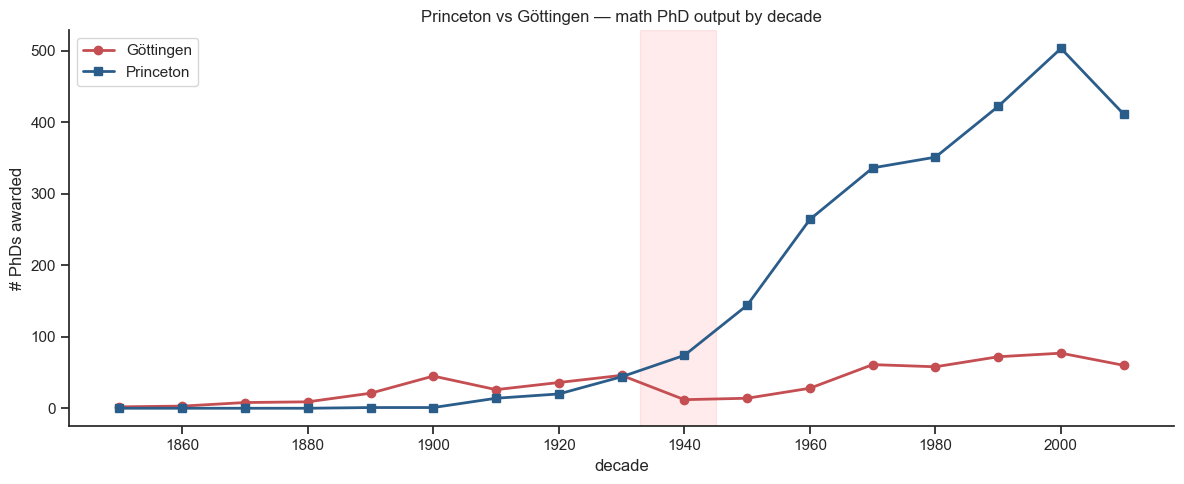

first decade Princeton > Göttingen by PhD output: 1940


In [76]:
princeton = df[df["school"] == "Princeton University"].dropna(subset=["year"])
gottingen = df[df["school"] == "Georg-August-Universität Göttingen"].dropna(subset=["year"])

p_by_decade = (princeton["year"].astype(int)
               .pipe(lambda s: (s // 10) * 10)
               .value_counts().sort_index())
g_by_decade = (gottingen["year"].astype(int)
               .pipe(lambda s: (s // 10) * 10)
               .value_counts().sort_index())
years_all = pd.Index(range(1850, 2020, 10))
p_by_decade = p_by_decade.reindex(years_all, fill_value=0)
g_by_decade = g_by_decade.reindex(years_all, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_all, g_by_decade.values, "o-", linewidth=2,
        label="Göttingen", color="#c44e52")
ax.plot(years_all, p_by_decade.values, "s-", linewidth=2,
        label="Princeton", color="#2b5d8b")
ax.axvspan(1933, 1945, color="red", alpha=0.08)
ax.set_xlabel("decade")
ax.set_ylabel("# PhDs awarded")
ax.set_title("Princeton vs Göttingen — math PhD output by decade")
ax.legend()
plt.tight_layout()
plt.show()

# Crossover year
combined = pd.DataFrame({"Princeton": p_by_decade, "Göttingen": g_by_decade})
combined["P>G"] = combined["Princeton"] > combined["Göttingen"]
crossover = combined[combined["P>G"]].head(1)
print(f"first decade Princeton > Göttingen by PhD output: {crossover.index[0] if len(crossover) else 'never'}")

### 23.2 The Bourbaki effect

Trace the lineages of the seven Bourbaki founders. Does the modern descendant pool concentrate in algebraic geometry / abstract algebra?

In [77]:
BOURBAKI = [
    "Henri Cartan",
    "Claude Chevalley",
    "Jean Coulomb",
    "Jean Delsarte",
    "Jean Dieudonné",
    "André Weil",
    "René de Possel",
]
bourbaki_ids = []
for name in BOURBAKI:
    nid = lookup_id(name)
    if nid is not None:
        bourbaki_ids.append(nid)
        rec = df.loc[nid]
        y = rec.get("year")
        y_str = f"{int(y)}" if pd.notna(y) else "?"
        print(f"  {name:<25} -> {rec['name']} ({y_str})")
    else:
        print(f"  NOT FOUND: {name}")

# Combined descendant set
bourbaki_desc = set()
for nid in bourbaki_ids:
    bourbaki_desc |= desc_sets[nid]
print(f"\ntotal Bourbaki descendant pool: {len(bourbaki_desc):,}")

# Subject composition of Bourbaki descendants vs overall
b_subj = df.loc[list(bourbaki_desc), "subject_clean"].value_counts(normalize=True)
all_subj = df["subject_clean"].value_counts(normalize=True)
print("\nTop subjects in Bourbaki descendants vs. all of MGP (top 10 in Bourbaki):")
print(f"{'subject':<40} {'Bourbaki':>10} {'MGP':>10} {'ratio':>8}")
for s in b_subj.head(10).index:
    b_v = b_subj.get(s, 0)
    m_v = all_subj.get(s, 0)
    ratio = b_v / m_v if m_v > 0 else float("inf")
    print(f"  {(s or '')[:38]:<40} {b_v:>10.1%} {m_v:>10.1%} {ratio:>7.1f}x")

  Henri Cartan              -> Henri Paul Cartan (1928)
  Claude Chevalley          -> Claude C. Chevalley (1933)
  Jean Coulomb              -> Jean-Michel Coulomb (?)
  Jean Delsarte             -> Jean Delsarte (1928)
  Jean Dieudonné            -> Jean Alexandre Eugène Dieudonné (1931)
  André Weil                -> André Abraham Weil (?)
  René de Possel            -> René De Possel (1932)

total Bourbaki descendant pool: 2,240

Top subjects in Bourbaki descendants vs. all of MGP (top 10 in Bourbaki):
subject                                    Bourbaki        MGP    ratio
  Algebraic geometry                            25.9%       2.0%    13.1x
  Number theory                                  9.5%       2.5%     3.7x
  Probability theory and stochastic proc         6.6%       3.8%     1.7x
  Statistics                                     5.2%       8.3%     0.6x
  Algebraic topology                             4.3%       0.8%     5.5x
  Group theory and generalizations            

### 23.3 The Russian diaspora: who received the post-1991 wave?

In [78]:
r2us = edges_full[(edges_full["adv_c"] == "Russia") &
                  (edges_full["stu_c"] == "UnitedStates")].copy()
r2us = r2us.dropna(subset=["stu_y"])
r2us["stu_decade"] = (r2us["stu_y"] // 10) * 10

post91 = r2us[r2us["stu_y"] >= 1991]
post91["adv_name"] = post91["adv"].map(df["name"])
post91["stu_school"] = post91["stu"].map(df["school"])

print(f"Russia → US edges with student PhD ≥ 1991: {len(post91):,}")
top_receivers = post91["stu_school"].value_counts().head(10)
print("\nTop US receiving schools for the post-1991 wave:")
for sch, n in top_receivers.items():
    print(f"  {sch:<60} {n:>4}")

# Top Russian-PhD advisors of post-1991 US students
top_advisors = post91["adv"].value_counts().head(10)
print("\nMost prolific Russia-PhD advisors for the post-1991 US cohort:")
for nid, n in top_advisors.items():
    print(f"  {df.loc[nid, 'name']:<35} → {n} US students")

Russia → US edges with student PhD ≥ 1991: 1,109

Top US receiving schools for the post-1991 wave:
  The Pennsylvania State University                              69
  City University of New York                                    48
  Stanford University                                            36
  University of California, Berkeley                             35
  Yale University                                                32
  University of Illinois at Urbana-Champaign                     28
  University of Michigan                                         28
  The University of Chicago                                      28
  Massachusetts Institute of Technology                          27
  University of Minnesota-Minneapolis                            26

Most prolific Russia-PhD advisors for the post-1991 US cohort:
  Anatole Boris Katok                 → 34 US students
  Yakov Eliashberg                    → 30 US students
  Victor Yakovlevich Pan              → 23 US s

## 24. Data quality / outliers

### 24.1 Implausible records

In [79]:
issues = []
# 1. Advisors younger than students
for u, v in G.edges():
    yu = df.at[u, "year"] if u in df.index else None
    yv = df.at[v, "year"] if v in df.index else None
    if pd.notna(yu) and pd.notna(yv) and yu > yv:
        issues.append((u, v, "advisor year > student year", yu, yv))
print(f"edges where advisor's PhD year > student's PhD year:  {len(issues):,}")

# 2. Implausible advisor-student year gap (> 70 years)
big_gaps = edges_y.dropna(subset=["adv_y", "stu_y"])
big_gaps = big_gaps[(big_gaps["stu_y"] - big_gaps["adv_y"]) > 70]
print(f"edges with gap > 70 years (likely error):              {len(big_gaps):,}")

# 3. Students older than their PhD year + 90 (data-entry errors)
# (can't easily check without birth-year data)

# 4. Duplicate-name records
name_counts = df["name"].value_counts()
duplicates = name_counts[name_counts >= 5]
print(f"names appearing ≥5 times (possible duplicates):        {len(duplicates):,}")
print("\nMost common 'duplicate' names (may be common-name collisions):")
print(duplicates.head(8).to_string())

edges where advisor's PhD year > student's PhD year:  255
edges with gap > 70 years (likely error):              4
names appearing ≥5 times (possible duplicates):        233

Most common 'duplicate' names (may be common-name collisions):
name
Wei Wang     23
Wei Zhang    21
Wei Li       18
Jing Wang    18
Yang Liu     16
Tao Wang     16
Ming Li      15
Lei Zhang    15


### 24.2 Hub sanity check — really 100+ students?

In [80]:
mega_hubs = pd.Series({n: G.out_degree(n) for n in G.nodes()})
mega_hubs = mega_hubs[mega_hubs >= 40].sort_values(ascending=False)
hub_df = df.loc[mega_hubs.index, ["name", "year", "country", "school", "subject_clean"]].copy()
hub_df["students"] = mega_hubs.values
hub_df.reset_index(drop=True).head(15)

,name,year,country,school,subject_clean,students
0,C.-C. Jay Kuo,1987.0,UnitedStates,Massachusetts Institute of Technology,"Information and communication, circuits",155
1,Roger Meyer Temam,1967.0,France,Université de Paris,NaN,123
2,Pekka Neittaanmäki,1978.0,Finland,Jyväskylän yliopisto,NaN,116
3,Shlomo Noach (Stephen Ram) Sawilowsky,1985.0,UnitedStates,University of South Florida,Statistics,109
4,Andrew Bernard Whinston,1962.0,UnitedStates,Carnegie Mellon University,"Operations research, mathematical programming",108
5,Alexander Vasil'evich Mikhalëv,1967.0,Russia,Lomonosov Moscow State University,Associative rings and algebras,101
6,Willi Jäger,1966.0,Germany,Ludwig-Maximilians-Universität München,NaN,101
7,Ronold Wyeth Percival King,1932.0,UnitedStates,University of Wisconsin-Madison,NaN,100
8,Leonard Salomon Ornstein,NaN,Netherlands,NaN,"Statistical mechanics, structure of matter",95
9,Erol Gelenbe,NaN,UnitedStates,NaN,Computer science,95


## 25. Mathematical Eve — does a single ancestor unite modern math?

For each candidate ancestor `a`, compute the fraction of modern PhDs (year 2000–2014) who descend from `a`. The "Mathematical Eve" would be the latest-in-time ancestor whose lineage contains *all* moderns.

> Spoiler: there isn't one. The maximum coverage of any single ancestor is only ~74%.

In [81]:
modern = set(df[df["year"].between(2000, 2014)].index)
modern_giant = modern & giant_wcc
print(f"modern PhDs (2000-2014): {len(modern):,}")
print(f"  of those, in giant WCC: {len(modern_giant):,}  ({len(modern_giant)/len(modern):.1%})")
print(f"  outside giant (can't share an ancestor with most of the graph): {len(modern - giant_wcc):,}")

# For each candidate ancestor with a non-trivial total descendant set, compute
# the fraction of moderns who descend from it.
candidates = []
threshold = len(modern_giant) * 0.3
for v, ds in desc_sets.items():
    if len(ds) < threshold:
        continue
    n_modern = len(modern_giant & ds)
    if n_modern == 0:
        continue
    candidates.append({
        "id": v,
        "name": G.nodes[v].get("name") or f"#{v}",
        "year": G.nodes[v].get("year"),
        "country": G.nodes[v].get("country"),
        "total_descendants": len(ds),
        "modern_descendants": n_modern,
        "frac_of_moderns": n_modern / len(modern_giant),
    })
cdf = pd.DataFrame(candidates).sort_values("frac_of_moderns", ascending=False)
print(f"\nmax fraction of modern PhDs sharing any single ancestor: {cdf['frac_of_moderns'].max():.1%}")
print(f"(no single ancestor unites all of modern math — Mathematical Eve does not exist)\n")
print("Top 10 'broadest' ancestors:")
print(cdf.head(10)[["name", "year", "total_descendants", "frac_of_moderns"]].to_string(index=False))

modern PhDs (2000-2014): 77,956
  of those, in giant WCC: 74,122  (95.1%)
  outside giant (can't share an ancestor with most of the graph): 3,834

max fraction of modern PhDs sharing any single ancestor: 73.7%
(no single ancestor unites all of modern math — Mathematical Eve does not exist)

Top 10 'broadest' ancestors:
                        name  year  total_descendants  frac_of_moderns
  Thomas von Kempen à Kempis   NaN             170917         0.736853
                 Moses Perez   NaN             170920         0.736853
           Elissaeus Judaeus   NaN             171010         0.736853
             Nilos Kabasilas   NaN             171034         0.736853
           Demetrios Kydones   NaN             171033         0.736853
   Georgios Plethon Gemistos   NaN             171009         0.736853
          Manuel Chrysoloras   NaN             170979         0.736853
          Basilios Bessarion   NaN             171006         0.736853
Geert Gerardus Magnus Groote   NaN      

### 25.1 The latest broad ancestor

Among ancestors with a known year, who's the most recent figure whose lineage still contains ≥50% of modern math?

In [82]:
known_year = cdf.dropna(subset=["year"]).copy()
known_year["year"] = known_year["year"].astype(int)

# Latest ancestor with at least k% coverage
for thresh in (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
    sub = known_year[known_year["frac_of_moderns"] >= thresh]
    if len(sub):
        latest = sub.sort_values("year").iloc[-1]
        print(f"  ≥{thresh:>4.0%} coverage:  latest = {latest['name']:<35} ({int(latest['year'])})"
              f"  with {latest['frac_of_moderns']:.1%} of moderns")

  ≥ 50% coverage:  latest = Siméon Denis Poisson                (1800)  with 51.1% of moderns
  ≥ 40% coverage:  latest = Siméon Denis Poisson                (1800)  with 51.1% of moderns
  ≥ 30% coverage:  latest = Julius Plücker                      (1823)  with 30.7% of moderns
  ≥ 20% coverage:  latest = Julius Plücker                      (1823)  with 30.7% of moderns
  ≥ 10% coverage:  latest = E. H. (Eliakim Hastings) Moore      (1885)  with 12.5% of moderns


### 25.2 The coverage curve

How does ancestral coverage of modern math decay over time? Plot fraction of moderns covered vs. year of ancestor.

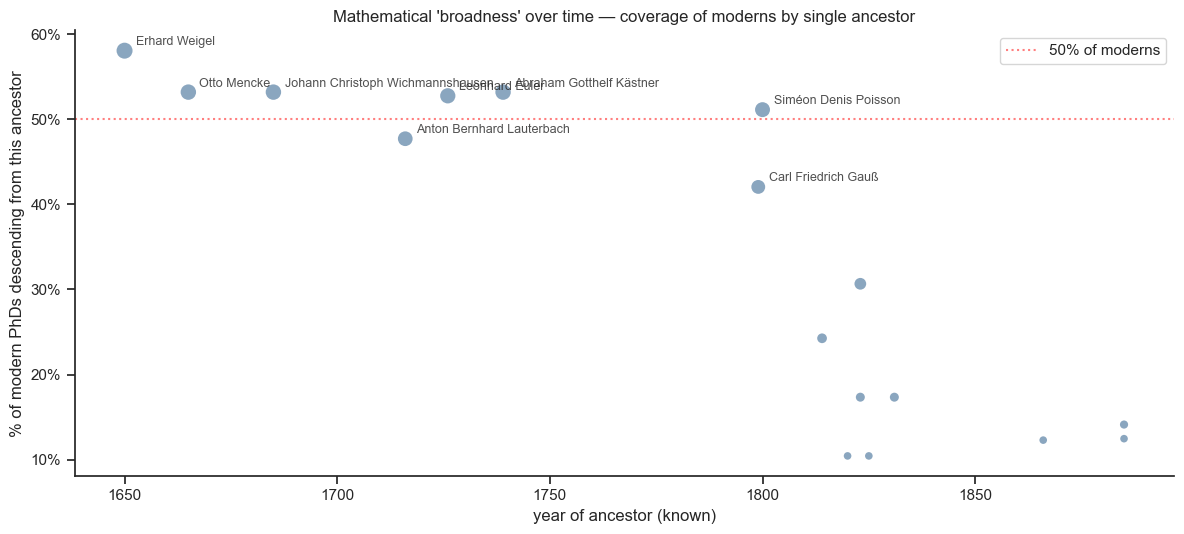

In [83]:
known_year = cdf.dropna(subset=["year"]).copy()
known_year["year"] = known_year["year"].astype(int)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.scatter(known_year["year"], known_year["frac_of_moderns"] * 100,
           s=np.clip(known_year["total_descendants"] / 1000, 30, 600),
           alpha=0.55, color="#2b5d8b", edgecolors="none")
# Annotate the top few names
top_label = known_year.nlargest(8, "frac_of_moderns")
for _, row in top_label.iterrows():
    ax.annotate(row["name"], (row["year"], row["frac_of_moderns"] * 100),
                xytext=(8, 4), textcoords="offset points", fontsize=9, alpha=0.8)
ax.set_xlabel("year of ancestor (known)")
ax.set_ylabel("% of modern PhDs descending from this ancestor")
ax.set_title("Mathematical 'broadness' over time — coverage of moderns by single ancestor")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.axhline(50, color="red", linestyle=":", alpha=0.5, label="50% of moderns")
ax.legend()
plt.tight_layout()
plt.show()

## 26. WWII as a natural experiment: German mathematicians who stayed vs. emigrated

For each German-PhD advisor with PhD year 1900–1933 and ≥3 students whose PhDs came *after* 1933, compute the fraction of those post-1933 students whose own PhDs were awarded *outside* Germany. This is a coarse proxy for "advisor moved their lab abroad" — though some "stayers" trained students who themselves later emigrated, and vice versa.

Then compare the long-run lineage outcomes of the two groups.

In [84]:
german_1933 = df[(df["country"] == "Germany") & df["year"].between(1900, 1933)].index

records = []
for nid in german_1933:
    students = list(G.successors(nid))
    students_post33 = [s for s in students
                       if pd.notna(df.at[s, "year"]) and df.at[s, "year"] > 1933]
    if len(students_post33) < 3:
        continue
    s_countries = [df.at[s, "country"] for s in students_post33]
    non_german = sum(1 for c in s_countries if isinstance(c, str) and c != "Germany")
    records.append({
        "id": nid,
        "name": df.at[nid, "name"],
        "year": df.at[nid, "year"],
        "n_post33_students": len(students_post33),
        "frac_non_german_post33": non_german / len(students_post33),
        "total_descendants": len(desc_sets[nid]),
    })
records = pd.DataFrame(records)
records["group"] = np.where(records["frac_non_german_post33"] >= 0.5,
                            "Emigrated (≥50% non-DE)", "Stayed (<50% non-DE)")

print(f"German advisors with ≥3 post-1933 students:  {len(records):,}")
print(f"  emigrated (post-33 students mostly non-DE):  {(records['group'].str.startswith('Emigrated')).sum():,}")
print(f"  stayed:                                       {(records['group'].str.startswith('Stayed')).sum():,}")
print()
print("Lineage outcomes by group (descendants by 2014):")
print(records.groupby("group")["total_descendants"].agg(["median", "mean", "count"]).round(0))

German advisors with ≥3 post-1933 students:  51
  emigrated (post-33 students mostly non-DE):  32
  stayed:                                       19

Lineage outcomes by group (descendants by 2014):
                         median    mean  count
group                                         
Emigrated (≥50% non-DE)   187.0   866.0     32
Stayed (<50% non-DE)      215.0  1355.0     19


### 26.1 Top of each branch

Lists are recognisable: the "emigrated" branch is largely the Jewish/dissident diaspora that founded e.g. the Courant Institute; the "stayed" branch includes Hilbert's most prolific student Erhard Schmidt.

In [85]:
print("Top 8 'emigrated' (≥50% non-DE post-33 students) by total descendants:")
print(records[records["group"].str.startswith("Emigrated")]
      .nlargest(8, "total_descendants")
      [["name", "year", "frac_non_german_post33", "total_descendants"]]
      .to_string(index=False))
print()
print("Top 8 'stayers' (<50% non-DE post-33 students) by total descendants:")
print(records[records["group"].str.startswith("Stayed")]
      .nlargest(8, "total_descendants")
      [["name", "year", "frac_non_german_post33", "total_descendants"]]
      .to_string(index=False))

Top 8 'emigrated' (≥50% non-DE post-33 students) by total descendants:
                   name   year  frac_non_german_post33  total_descendants
        Richard Courant 1910.0                0.916667               7593
             Heinz Hopf 1925.0                0.944444               5690
        Salomon Bochner 1921.0                1.000000               3922
 Hugo Dyonizy Steinhaus 1911.0                1.000000               2789
I. Paul (Isaak) Bernays 1912.0                1.000000               2162
   Kurt Otto Friedrichs 1925.0                1.000000               1004
Richard Dagobert Brauer 1926.0                1.000000                860
         Wilhelm Magnus 1931.0                0.986486                601

Top 8 'stayers' (<50% non-DE post-33 students) by total descendants:
                  name   year  frac_non_german_post33  total_descendants
        Erhard Schmidt 1905.0                0.000000              13634
           Erich Hecke 1910.0                0.

### 26.2 Where are the modern descendants of each branch?

The starkest difference is *not* lineage size but **geography**: emigrants' descendants are concentrated in the US; stayers' in Germany.

Emigrant branch — unique descendants by 2014:  25,265
Stayer branch — unique descendants by 2014:    22,636
Overlap (people descended from both):          11,948


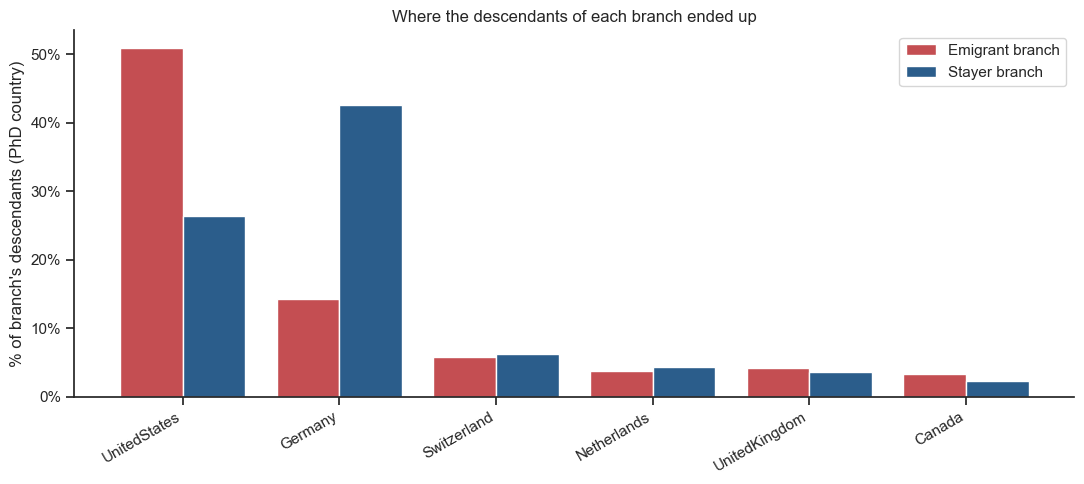


Top country in each branch:
  Emigrant branch top country:  UnitedStates     (50.9%)
  Stayer branch top country:    Germany          (42.6%)


In [86]:
def descendant_geography(advisor_id):
    desc = desc_sets[advisor_id]
    countries = df.loc[list(desc), "country"].value_counts(normalize=True)
    return countries

emig_advisors = records[records["group"].str.startswith("Emigrated")]["id"].tolist()
stay_advisors = records[records["group"].str.startswith("Stayed")]["id"].tolist()

# Combined descendant pools (weighted by union, not sum, to avoid double-counting)
emig_desc = set()
for a in emig_advisors:
    emig_desc |= desc_sets[a]
stay_desc = set()
for a in stay_advisors:
    stay_desc |= desc_sets[a]

print(f"Emigrant branch — unique descendants by 2014:  {len(emig_desc):,}")
print(f"Stayer branch — unique descendants by 2014:    {len(stay_desc):,}")
print(f"Overlap (people descended from both):          {len(emig_desc & stay_desc):,}")

# Country distribution of each branch's descendants
emig_c = df.loc[list(emig_desc), "country"].value_counts(normalize=True).head(6)
stay_c = df.loc[list(stay_desc), "country"].value_counts(normalize=True).head(6)

fig, ax = plt.subplots(figsize=(11, 5))
top_countries_combined = pd.Index(set(emig_c.index) | set(stay_c.index))
emig_aligned = emig_c.reindex(top_countries_combined, fill_value=0)
stay_aligned = stay_c.reindex(top_countries_combined, fill_value=0)
order = (emig_aligned + stay_aligned).sort_values(ascending=False).index
x = np.arange(len(order))
w = 0.4
ax.bar(x - w/2, emig_aligned.reindex(order) * 100, w, label="Emigrant branch", color="#c44e52")
ax.bar(x + w/2, stay_aligned.reindex(order) * 100, w, label="Stayer branch", color="#2b5d8b")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("% of branch's descendants (PhD country)")
ax.set_title("Where the descendants of each branch ended up")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop country in each branch:")
print(f"  Emigrant branch top country:  {emig_c.idxmax():<15}  ({emig_c.max():.1%})")
print(f"  Stayer branch top country:    {stay_c.idxmax():<15}  ({stay_c.max():.1%})")

### 26.3 Did the shock change advisor productivity?

For each advisor, compute the rate of student production before vs. after 1933. The natural experiment: did the wave that emigrated continue advising at a similar rate, or did the disruption suppress them?

In [87]:
def student_rate(advisor_id, y0, y1):
    students = list(G.successors(advisor_id))
    in_window = [s for s in students
                 if pd.notna(df.at[s, "year"]) and y0 <= df.at[s, "year"] <= y1]
    return len(in_window) / (y1 - y0 + 1)

records["pre33_rate"]  = records["id"].apply(lambda v: student_rate(v, 1925, 1933))
records["post45_rate"] = records["id"].apply(lambda v: student_rate(v, 1946, 1960))

# Only advisors who were producing pre-33 (otherwise undefined ratio)
active_pre33 = records[records["pre33_rate"] > 0].copy()
active_pre33["ratio"] = active_pre33["post45_rate"] / active_pre33["pre33_rate"]

print("Median (post-1945 students/yr) / (pre-1933 students/yr):")
print(active_pre33.groupby("group")["ratio"].agg(["median", "mean", "count"]).round(2))
print("\n(ratio < 1 = career slowed; ratio > 1 = career sped up; ratio = NaN if pre-33 rate = 0)")

Median (post-1945 students/yr) / (pre-1933 students/yr):
                         median  mean  count
group                                       
Emigrated (≥50% non-DE)    0.94  1.69     11
Stayed (<50% non-DE)       0.13  0.66      7

(ratio < 1 = career slowed; ratio > 1 = career sped up; ratio = NaN if pre-33 rate = 0)


## 27. Notable mathematicians MGP can't see

Some of math's most influential figures advised few or no PhD students — Galois died at 20, Abel at 26, Ramanujan never finished a PhD, Fermat predates the institution. This section uses a hand-curated list as a calibration exercise: what does MGP capture, and what does it miss?

In [88]:
# Hyphen-tolerant variant of lookup_id (Lagrange's MGP entry has no hyphen).
def lookup_id_loose(name):
    n_norm = normalize(name).replace("-", " ")
    parts = n_norm.split()
    if len(parts) < 2: return None
    last_re = rf"\b{re.escape(parts[-1])}\b"
    name_norm_loose = df["name_norm"].str.replace("-", " ", regex=False)
    cands = df[name_norm_loose.str.contains(last_re, regex=True) &
               name_norm_loose.str.contains(parts[0], regex=False)]
    if not len(cands): return None
    cands = cands.assign(d=name_norm_loose.loc[cands.index].str.len().sub(len(n_norm)).abs())
    return cands.sort_values("d").index[0]

NOTABLE = [
    ("Pierre de Fermat",          1665, "Lawyer; founded modern number theory"),
    ("Blaise Pascal",             1662, "Pascal's triangle; probability"),
    ("René Descartes",            1650, "Cartesian coordinates; analytic geometry"),
    ("Isaac Newton",              1727, "Calculus; gravitation"),
    ("Gottfried Wilhelm Leibniz", 1716, "Calculus; symbolic logic"),
    ("Pierre-Simon Laplace",      1827, "Probability; celestial mechanics"),
    ("Joseph-Louis Lagrange",     1813, "Lagrangian mechanics; calculus of variations"),
    ("Augustin-Louis Cauchy",     1857, "Analysis foundations; ~800 papers"),
    ("Niels Henrik Abel",         1829, "Elliptic functions; died at 26"),
    ("Évariste Galois",           1832, "Group theory; died at 20"),
    ("Bernhard Riemann",          1866, "Riemann hypothesis; differential geometry"),
    ("Georg Cantor",              1918, "Set theory; cardinality"),
    ("Srinivasa Ramanujan",       1920, "Number theory; partition function"),
    ("Henri Poincaré",            1912, "Topology; dynamical systems"),
    ("Sophus Lie",                1899, "Lie groups; continuous symmetry"),
    ("Alan Turing",               1954, "Computability; AI foundations"),
    ("Emmy Noether",              1935, "Abstract algebra; Noether's theorem"),
    ("Kurt Gödel",                1978, "Incompleteness theorems"),
]

rows = []
for name, death, note in NOTABLE:
    nid = lookup_id_loose(name)
    if nid is None:
        rows.append({"name": name, "died": death, "in_MGP": False,
                     "PhD_year": None, "students": 0, "descendants": 0,
                     "note": note})
    else:
        py = df.at[nid, "year"]
        n_stu = G.out_degree(nid)
        n_desc = len(desc_sets.get(nid, set()))
        rows.append({"name": name, "died": death, "in_MGP": True,
                     "PhD_year": int(py) if pd.notna(py) else None,
                     "students": n_stu, "descendants": n_desc,
                     "note": note})

notable_df = pd.DataFrame(rows)
print(f"in MGP at all:               {notable_df['in_MGP'].sum()} / {len(notable_df)}")
print(f"in MGP with PhD year known:  {notable_df['PhD_year'].notna().sum()} / {len(notable_df)}")
print(f"in MGP with ≥1 student:      {(notable_df['students'] >= 1).sum()} / {len(notable_df)}")
notable_df

in MGP at all:               18 / 18
in MGP with PhD year known:  6 / 18
in MGP with ≥1 student:      11 / 18


,name,died,in_MGP,PhD_year,students,descendants,note
0,Pierre de Fermat,1665,True,NaN,0,0,Lawyer; founded modern number theory
1,Blaise Pascal,1662,True,NaN,0,0,Pascal's triangle; probability
2,René Descartes,1650,True,NaN,0,0,Cartesian coordinates; analytic geometry
3,Isaac Newton,1727,True,NaN,3,20482,Calculus; gravitation
4,Gottfried Wilhelm Leibniz,1716,True,NaN,2,131279,Calculus; symbolic logic
5,Pierre-Simon Laplace,1827,True,NaN,1,115601,Probability; celestial mechanics
6,Joseph-Louis Lagrange,1813,True,NaN,3,115603,Lagrangian mechanics; calculus of variations
7,Augustin-Louis Cauchy,1857,True,NaN,3,3,Analysis foundations; ~800 papers
8,Niels Henrik Abel,1829,True,NaN,0,0,Elliptic functions; died at 26
9,Évariste Galois,1832,True,NaN,0,0,Group theory; died at 20


### 27.1 What this tells us about MGP coverage

The notable list reveals MGP's blind spots:

- **Pre-PhD-institution figures** (Fermat, Pascal, Descartes, Newton, Leibniz) are in MGP as "anchor" nodes but with no PhD year — they're roots of lineages, not students themselves.
- **Cauchy and Lagrange** — two of the most influential 19th-century mathematicians — appear with no recorded PhD year and zero direct PhD students, despite Cauchy reportedly mentoring numerous protégés. MGP captures formal advisor-student relationships, not informal mentorship.
- **Galois, Abel, Ramanujan** all died young (or, in Ramanujan's case, never held a faculty position) and never advised PhDs. They're zero-out-degree nodes despite outsized influence on math.
- **Riemann had only 2 students**, **Cantor only 1**, **Newton 3**, **Turing 2** — these field-defining figures all have small direct lineages despite their towering influence.

**MGP measures one specific signal — formal PhD supervision — and misses correspondence, posthumous influence, autodidacts, and pre-institutional mathematicians.** The "descendant count" rankings in §4 are about advisor productivity, not mathematical importance.

## 28. Co-advisor recurrence — invisible "labs"

When two advisors jointly supervise multiple students, they're not just colleagues — they're a *team*. Build the meta-graph where nodes are advisors and edges are co-supervision pairs weighted by # shared students.

In [89]:
from itertools import combinations
co_pairs = Counter()
for stu in G.nodes():
    advisors = list(G.predecessors(stu))
    if len(advisors) >= 2:
        for a, b in combinations(sorted(advisors), 2):
            co_pairs[(a, b)] += 1

co_df = pd.DataFrame(
    [(a, b, n) for (a, b), n in co_pairs.items()],
    columns=["adv1", "adv2", "shared"]
)
print(f"distinct co-advisor pairs:      {len(co_df):,}")
print(f"  with ≥2 shared students:      {(co_df['shared'] >= 2).sum():,}  ({(co_df['shared']>=2).mean():.1%})")
print(f"  with ≥5 shared students:      {(co_df['shared'] >= 5).sum():,}")
print(f"  with ≥10 shared students:     {(co_df['shared'] >= 10).sum():,}")
print(f"  max:                           {co_df['shared'].max()}")

co_df["adv1_name"] = co_df["adv1"].map(df["name"])
co_df["adv2_name"] = co_df["adv2"].map(df["name"])
co_df["adv1_school"] = co_df["adv1"].map(df["school"])
print("\nTop 12 recurring co-advisor pairs (most prolific 'labs'):")
top = co_df.nlargest(12, "shared")
for _, r in top.iterrows():
    print(f"  {r['shared']:>3}  {r['adv1_name'][:30]:<30} & {r['adv2_name'][:30]:<30}  ({r['adv1_school'][:30] if isinstance(r['adv1_school'],str) else ''})")

distinct co-advisor pairs:      39,738
  with ≥2 shared students:      5,741  (14.4%)
  with ≥5 shared students:      543
  with ≥10 shared students:     79
  max:                           33

Top 12 recurring co-advisor pairs (most prolific 'labs'):
   33  Karl Theodor Wilhelm Weierstra & Ernst Eduard Kummer             ()
   26  Hans Paul Künzi                & Walter F. Daenzer               (ETH Zürich)
   25  Gustav Herglotz                & Otto Ludwig Hölder              ()
   23  Saeid Abbasbandy               & Tofigh Allahviranloo            (Teacher Training University, T)
   22  Mohammad Reza Rajabzadeh Mogha & Farshid Saeedi                  (University of London)
   18  Lars-Erik Persson              & Peter Wall                      (Umeå University)
   18  W. Stephen (Walter) Wilson     & J. Michael (John) Boardman      (Massachusetts Institute of Tec)
   16  C. Felix (Christian) Klein     & Wilhelm Scheibner               ()
   16  Shlomo Noach (Stephen Ram) Saw & Don

### 28.1 Distribution of co-advising intensity

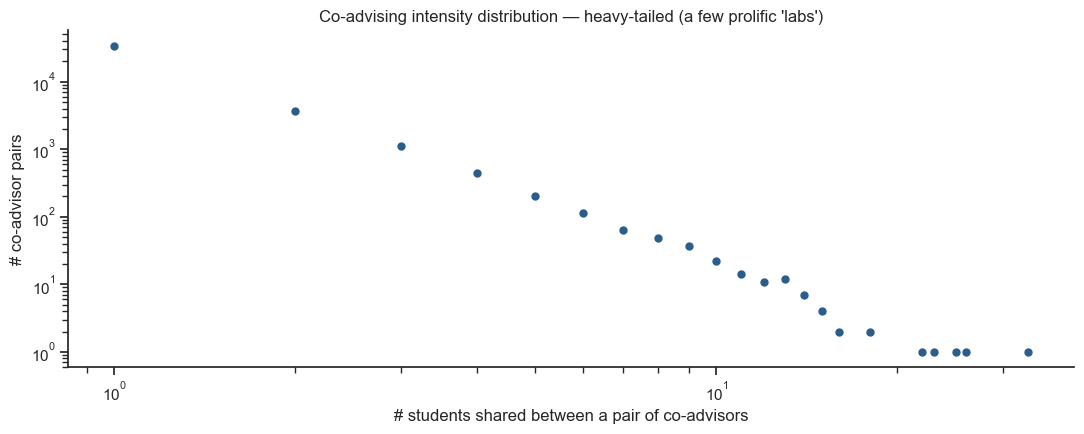

In [90]:
fig, ax = plt.subplots(figsize=(11, 4.5))
counts = co_df["shared"].value_counts().sort_index()
ax.loglog(counts.index, counts.values, "o", markersize=5, color="#2b5d8b")
ax.set_xlabel("# students shared between a pair of co-advisors")
ax.set_ylabel("# co-advisor pairs")
ax.set_title("Co-advising intensity distribution — heavy-tailed (a few prolific 'labs')")
plt.tight_layout()
plt.show()

### 28.2 Are co-advisors academically close?

For each co-advised student, compute the undirected graph distance between their two advisors. Close → shared lab; far → cross-disciplinary collaboration.

co-advisor pairs sampled: 3,000
  reachable through graph: 3,000 (100.0%)
  median distance: 2
  mean:            1.90
  fraction at distance ≤2: 100.0%
  fraction at distance ≤4: 100.0%


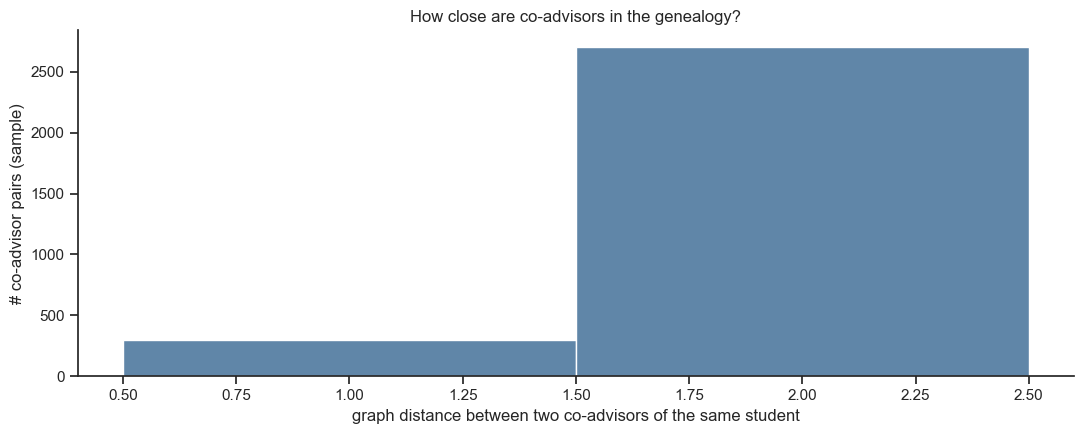

In [91]:
H_undir = G.to_undirected()
# Sample to keep runtime tractable — most co-pairs are similar within a school
sample_pairs = co_df.sample(min(3000, len(co_df)), random_state=0)

distances = []
for _, r in sample_pairs.iterrows():
    try:
        d = nx.shortest_path_length(H_undir, r["adv1"], r["adv2"])
        distances.append(d)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        distances.append(None)
dist_s = pd.Series([d for d in distances if d is not None])

print(f"co-advisor pairs sampled: {len(sample_pairs):,}")
print(f"  reachable through graph: {len(dist_s):,} ({len(dist_s)/len(sample_pairs):.1%})")
print(f"  median distance: {dist_s.median():.0f}")
print(f"  mean:            {dist_s.mean():.2f}")
print(f"  fraction at distance ≤2: {(dist_s <= 2).mean():.1%}")
print(f"  fraction at distance ≤4: {(dist_s <= 4).mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(dist_s.clip(0, 15), bins=range(0, 16), discrete=True, ax=ax, color="#2b5d8b")
ax.set_xlabel("graph distance between two co-advisors of the same student")
ax.set_ylabel("# co-advisor pairs (sample)")
ax.set_title("How close are co-advisors in the genealogy?")
plt.tight_layout()
plt.show()

## 29. Is the genealogy just a random branching process?

Galton–Watson branching: start with one ancestor; each individual independently produces a random number of children drawn from a fixed offspring distribution; iterate. Does that simple model reproduce the lineage-depth distribution observed in MGP?

In [92]:
# Empirical offspring distribution from the cohort 1900-1950 (full careers visible)
cohort = df[df["year"].between(1900, 1950)].index
empirical_off = pd.Series([G.out_degree(n) for n in cohort])

print(f"Cohort 1900-1950: {len(cohort):,} mathematicians")
print(f"  mean offspring μ = {empirical_off.mean():.3f}")
print(f"  P(0 students):    {(empirical_off == 0).mean():.1%}")
print(f"  P(≥1):            {(empirical_off >= 1).mean():.1%}")

# Sample from this empirical distribution
off_values = empirical_off.values
off_probs = np.bincount(off_values) / len(off_values)
off_support = np.arange(len(off_probs))

# Simulate one lineage: track number alive at each generation; stop when extinct
RNG_SIM = np.random.default_rng(42)

def simulate_one(max_gens=20):
    alive = 1
    max_depth = 0
    for g in range(1, max_gens + 1):
        if alive == 0:
            break
        # Sample 'alive' offspring counts
        sampled = RNG_SIM.choice(off_support, size=alive, p=off_probs)
        new_alive = int(sampled.sum())
        if new_alive > 0:
            max_depth = g
        alive = new_alive
        # Guard against runaway
        if alive > 100_000:
            alive = 100_000
    return max_depth

N_SIM = 10_000
sim_depths = np.array([simulate_one() for _ in range(N_SIM)])
print(f"\nSimulated {N_SIM:,} Galton-Watson lineages with empirical offspring distribution:")

Cohort 1900-1950: 6,767 mathematicians
  mean offspring μ = 2.725
  P(0 students):    60.2%
  P(≥1):            39.8%

Simulated 10,000 Galton-Watson lineages with empirical offspring distribution:


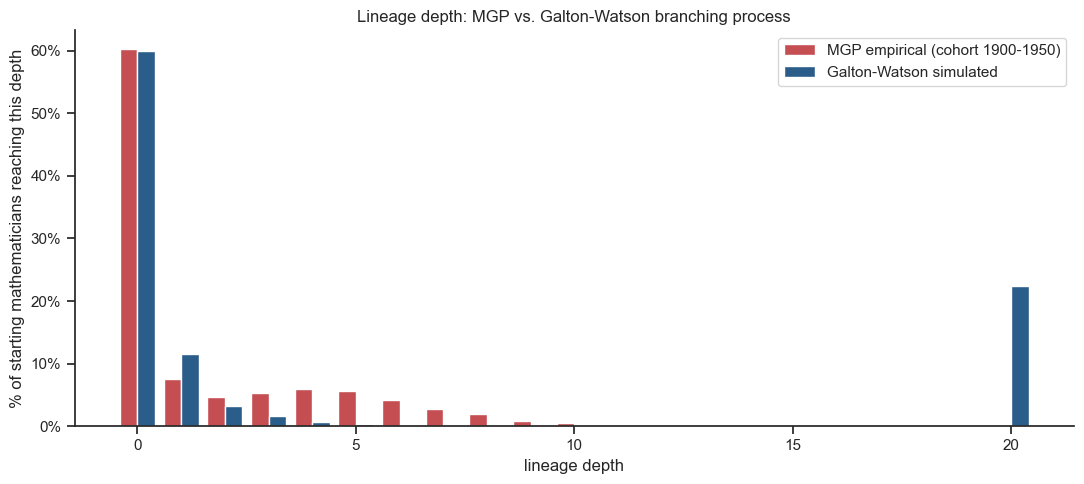


Lineage depth comparison:
 depth      MGP %   GW sim %
     0     60.23%     60.02%
     1      7.60%     11.49%
     2      4.71%      3.26%
     3      5.33%      1.57%
     4      5.98%      0.70%
     5      5.60%      0.27%
     6      4.21%      0.18%
     7      2.75%      0.07%
     8      1.99%      0.02%
     9      0.86%      0.02%
    10      0.52%      0.00%


In [93]:
# Compare simulated depth distribution to empirical (branch_depths from §14.4)
sim = pd.Series(sim_depths).value_counts(normalize=True).sort_index()
emp = pd.Series(branch_depths.loc[cohort]).value_counts(normalize=True).sort_index()

max_depth = int(max(sim.index.max(), emp.index.max()))
sim = sim.reindex(range(max_depth + 1), fill_value=0)
emp = emp.reindex(range(max_depth + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(max_depth + 1)
w = 0.4
ax.bar(x - w/2, emp.values * 100, w, label="MGP empirical (cohort 1900-1950)", color="#c44e52")
ax.bar(x + w/2, sim.values * 100, w, label="Galton-Watson simulated", color="#2b5d8b")
ax.set_xlabel("lineage depth")
ax.set_ylabel("% of starting mathematicians reaching this depth")
ax.set_title("Lineage depth: MGP vs. Galton-Watson branching process")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

# Quantitative comparison
print("\nLineage depth comparison:")
print(f"{'depth':>6} {'MGP %':>10} {'GW sim %':>10}")
for d in range(min(11, max_depth + 1)):
    print(f"{d:>6} {emp.get(d, 0)*100:>9.2f}% {sim.get(d, 0)*100:>9.2f}%")

**Reading:** if the Galton–Watson process reproduces the MGP depth distribution closely, the genealogy is "just" random branching — no extra structure beyond an offspring distribution. If MGP deviates systematically — e.g., longer than predicted lineages — there's *something* (school effects, heritability, subject inheritance) beyond what GW captures.

## 30. School meta-network

Promote the per-mathematician network to a per-school network: nodes = schools, weighted directed edges = # (advisor at A → student at B) pairs. Then apply PageRank, Louvain, k-core to *this* meta-graph.

In [94]:
school_edges_w = Counter()
for u, v in G.edges():
    sa = df.at[u, "school"]
    sb = df.at[v, "school"]
    if isinstance(sa, str) and isinstance(sb, str):
        school_edges_w[(sa, sb)] += 1

# Filter to schools with ≥200 total PhDs to reduce noise
school_size = df["school"].value_counts()
keep_schools = set(school_size[school_size >= 200].index)
school_edges_filt = {(a, b): w for (a, b), w in school_edges_w.items()
                     if a in keep_schools and b in keep_schools}

S = nx.DiGraph()
S.add_nodes_from(keep_schools)
for (a, b), w in school_edges_filt.items():
    S.add_edge(a, b, weight=w)

print(f"school meta-network: {S.number_of_nodes()} nodes, {S.number_of_edges():,} edges")
print(f"  total edge weight (PhDs):  {sum(d['weight'] for _,_,d in S.edges(data=True)):,}")

# PageRank — but on the REVERSED graph so flow goes student → advisor
# (which schools' alumni become advisors at OTHER schools)
school_pr = pd.Series(nx.pagerank(S.reverse(copy=False), alpha=0.85, weight="weight"))
print("\nTop 15 schools by reversed-PageRank (whose alumni become influential advisors):")
for sch, pr in school_pr.nlargest(15).items():
    n_phds = school_size.get(sch, 0)
    print(f"  {pr:.4f}  {sch[:60]:<62}  ({n_phds:,} PhDs)")

school meta-network: 237 nodes, 10,139 edges
  total edge weight (PhDs):  148,644

Top 15 schools by reversed-PageRank (whose alumni become influential advisors):
  0.0513  Harvard University                                              (3,004 PhDs)
  0.0446  Princeton University                                            (2,596 PhDs)
  0.0442  Massachusetts Institute of Technology                           (5,419 PhDs)
  0.0391  University of California, Berkeley                              (5,005 PhDs)
  0.0369  Stanford University                                             (4,082 PhDs)
  0.0364  University of Cambridge                                         (2,099 PhDs)
  0.0318  Lomonosov Moscow State University                               (1,465 PhDs)
  0.0287                                                                  (6,307 PhDs)
  0.0261  The University of Chicago                                       (2,213 PhDs)
  0.0157  Columbia University                         

### 30.1 School-level communities

Louvain on the undirected school meta-graph identifies clusters of schools that exchange PhDs preferentially.

In [95]:
S_undir = S.to_undirected()
school_communities = nx.community.louvain_communities(S_undir, seed=0, weight="weight")
print(f"Louvain communities (school meta-network): {len(school_communities)}")
print(f"  size distribution: max = {max(len(c) for c in school_communities)}, "
      f"median = {sorted(len(c) for c in school_communities)[len(school_communities)//2]}")

# Inspect the top-5 communities
big = sorted(school_communities, key=len, reverse=True)[:5]
for i, comm in enumerate(big):
    members = list(comm)
    # Top-school in community by total PhDs
    sizes = pd.Series({s: school_size.get(s, 0) for s in members}).sort_values(ascending=False)
    countries_in = df[df["school"].isin(members)]["country"].value_counts().head(3)
    print(f"\n  community {i} ({len(comm)} schools, {sizes.sum():,} total PhDs):")
    print(f"    top schools:  {sizes.head(3).index.tolist()}")
    print(f"    countries:    {countries_in.index.tolist()}")

Louvain communities (school meta-network): 17
  size distribution: max = 88, median = 5

  community 0 (88 schools, 73,392 total PhDs):
    top schools:  ['University of California, Berkeley', 'University of Wisconsin-Madison', 'University of Illinois at Urbana-Champaign']
    countries:    ['UnitedStates', 'Brazil', 'SouthKorea']

  community 1 (33 schools, 11,830 total PhDs):
    top schools:  ['ETH Zürich', 'École Polytechnique Fédérale de Lausanne', 'Georg-August-Universität Göttingen']
    countries:    ['Germany', 'Switzerland', 'Austria']

  community 2 (25 schools, 11,178 total PhDs):
    top schools:  ['University of Cambridge', 'University of London', 'University of Warwick']
    countries:    ['UnitedKingdom', 'Australia', 'Brazil']

  community 3 (21 schools, 14,543 total PhDs):
    top schools:  ['', 'Lomonosov Moscow State University', 'Université Pierre-et-Marie-Curie - Paris VI']
    countries:    ['France', 'Russia', 'Denmark']

  community 4 (18 schools, 23,007 total 

### 30.2 School-level k-core

The deepest k-core of the school meta-graph is the densest "elite cluster" — schools that all exchange students intensely with each other.

In [96]:
S_undir_unweighted = S_undir.copy()
# core_number requires no self-loops (intra-school hires are A→A edges, very common).
S_undir_unweighted.remove_edges_from(nx.selfloop_edges(S_undir_unweighted))
# Drop edges below a weight threshold so k-core is meaningful
WEIGHT_MIN = 50
to_drop = [(u, v) for u, v, d in S_undir_unweighted.edges(data=True) if d.get("weight", 0) < WEIGHT_MIN]
S_undir_unweighted.remove_edges_from(to_drop)
S_undir_unweighted.remove_nodes_from(list(nx.isolates(S_undir_unweighted)))

cn = nx.core_number(S_undir_unweighted)
core_series = pd.Series(cn)
print(f"after dropping edges with weight <{WEIGHT_MIN}: {S_undir_unweighted.number_of_nodes()} schools, "
      f"{S_undir_unweighted.number_of_edges():,} edges")
print(f"\nmax k-core: {core_series.max()}")
print(f"# schools in max core: {(core_series == core_series.max()).sum()}")
print(f"\nMembers of the deepest school k-core:")
for sch in core_series[core_series == core_series.max()].sort_index().index:
    print(f"  {sch}  ({school_size.get(sch,0):,} PhDs)")

after dropping edges with weight <50: 107 schools, 267 edges

max k-core: 9
# schools in max core: 16

Members of the deepest school k-core:
  California Institute of Technology  (1,730 PhDs)
  Carnegie Mellon University  (1,638 PhDs)
  Cornell University  (2,222 PhDs)
  Harvard University  (3,004 PhDs)
  Massachusetts Institute of Technology  (5,419 PhDs)
  Princeton University  (2,596 PhDs)
  Purdue University  (2,108 PhDs)
  Stanford University  (4,082 PhDs)
  The University of Chicago  (2,213 PhDs)
  University of California, Berkeley  (5,005 PhDs)
  University of California, Los Angeles  (2,591 PhDs)
  University of Illinois at Urbana-Champaign  (3,066 PhDs)
  University of Michigan  (2,876 PhDs)
  University of Minnesota-Minneapolis  (2,173 PhDs)
  University of Wisconsin-Madison  (3,437 PhDs)
  Yale University  (1,444 PhDs)


## 31. What wasn't done in this pass

A few high-value analyses that need external data or infrastructure beyond this notebook:

- **arXiv co-authorship cross-reference.** Would require downloading the arXiv math metadata and matching authors. Strongly recommended as a follow-up.
- **Wikipedia link-out.** Detecting "Wikipedia-notable" entries gives a proxy for impact; needs the Wikipedia API.
- **Animated time-slice growth.** Building a year-by-year animation (rather than the static snapshots in §19) is best done as a standalone HTML widget.
- **Interactive descendant explorer.** A click-to-walk lineage tree is great for a blog but lives outside this notebook (build with `plotly.tree` or a small web app).
- **Birth-date / age data.** MGP only has PhD year. Adding life-dates from Wikidata would enable proper survival-analysis hazard models on advising careers.

## 32. Caveats

A few things to keep in mind when interpreting any of the numbers above:

- **Coverage falls off near the present.** MGP lags real-world PhD production by 5–10 years. The "decline" past 2015 is ingestion lag.
- **Subject is missing for ~42% of records.** Subject-inheritance and subject-trend results are conditional on coverage and may be biased toward fields whose communities actively curate MGP.
- **`country` is where the PhD was awarded, not nationality.** Migration analysis here is "academic migration" (advisor trained in one country, student trained in another), not personal mobility.
- **`school` is free text.** "Université de Paris" and "University of Paris" may or may not be merged.
- **Cycle removal trimmed a handful of edges.** `build_graph.py` removes a small number of cycle-breaking edges using a year-based heuristic — these are typically data-entry errors but the choice of which edge to drop is sometimes ambiguous.
- **Influence ≠ descendants.** The "patriarchs" rankings are about lineage size, not the mathematical importance of any individual's work. Many prolific advisors are not famous mathematicians; many famous mathematicians never advised PhD students.
- **Gender inference is name-based.** `gender-guesser` works well on Western names and badly on many East Asian, African, and uncommon names. Use the gender numbers as rough trends, not precise demographic measurements.
- **Thesis-title analysis is English-biased.** Many non-English titles aren't tokenized cleanly by the English stop-word list. The "rising / falling words" results lean toward the English-language literature.